<a href="https://colab.research.google.com/github/zeosapka/glass-box-ai-research/blob/main/notebooks/01_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
# ============================================================
# BLOK 1 — ORTAM VE TEMEL KÜTÜPHANELER
# Amaç: PyTorch ve temel Python kütüphanelerini yüklemek,
#       kullanılacak işlemciyi (CPU/GPU) belirlemek.
# ============================================================

import time                         # time: işlem/eğitim süresini ölçmek için
import random                       # random: Python rastgeleliğini kontrol etmek için
import numpy as np                  # NumPy: sayısal dizi ve matematik işlemleri için

import torch                         # PyTorch: yapay sinir ağını kurmak ve çalıştırmak için
import torch.nn as nn                # torch.nn: neural network (sinir ağı) katmanlarını oluşturmak için
import torch.optim as optim          # torch.optim: model ağırlıklarını optimize etmek için

# PyTorch ve GPU durumunu kontrol ediyoruz
print("PyTorch version:", torch.__version__)   # Kullanılan PyTorch sürümünü gösterir
print("CUDA available:", torch.cuda.is_available())  # GPU kullanılabilir mi kontrol eder

# Modelin çalışacağı işlem birimini belirliyoruz
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)                                               # GPU varsa CUDA, yoksa CPU kullanılır

print("Device:", device)                        # Modelin hangi cihazda çalışacağını gösterir

PyTorch version: 2.11.0+cpu
CUDA available: False
Device: cpu


In [85]:
# ============================================================
# BLOK 2 — RANDOM SEED (RASTGELELİK TOHUMU)
# Amaç: Deneyin tekrarlanabilir (reproducible) olmasını sağlamak.
# ============================================================

SEED = 42                              # Deney boyunca kullanacağımız sabit seed

random.seed(SEED)                      # Python random işlemlerinin seed'ini belirler
np.random.seed(SEED)                   # NumPy rastgeleliğinin seed'ini belirler
torch.manual_seed(SEED)                # PyTorch CPU rastgeleliğinin seed'ini belirler

print("Random seed:", SEED)             # Kullanılan seed değerini kontrol eder

Random seed: 42


In [86]:
# ============================================================
# BLOK 3 — MNIST DATASET (VERİ SETİ)
# Amaç: MNIST el yazısı rakam veri setini yüklemek.
#       Model bu verileri kullanarak rakamları sınıflandıracak.
# ============================================================

from torchvision import datasets                 # Hazır görüntü veri setlerini çağırmak için
from torchvision import transforms               # Görüntülere dönüşüm uygulamak için

# Görüntüleri PyTorch Tensor formatına dönüştürüyoruz
transform = transforms.ToTensor()                 # Piksel değerlerini Tensor'a çevirir

# MNIST eğitim veri setini indiriyor/yüklüyor
train_dataset = datasets.MNIST(
    root="./data",                                # Veri setinin kaydedileceği klasör
    train=True,                                   # Eğitim (training) verisini seç
    download=True,                                # Veri yoksa internetten indir
    transform=transform                           # Belirlediğimiz dönüşümü uygula
)

# MNIST test veri setini indiriyor/yüklüyor
test_dataset = datasets.MNIST(
    root="./data",                                # Veri setinin kaydedileceği klasör
    train=False,                                  # Test verisini seç
    download=True,                                # Veri yoksa internetten indir
    transform=transform                           # Aynı dönüşümü uygula
)

print("Training samples:", len(train_dataset))   # Eğitim örneği sayısını gösterir
print("Test samples:", len(test_dataset))        # Test örneği sayısını gösterir

Training samples: 60000
Test samples: 10000


In [87]:
# ============================================================
# BLOK 4 — MNIST ÖRNEĞİNİ İNCELEME
# Amaç: Veri setindeki tek bir örneğin görüntü boyutunu,
#       etiketini ve Tensor yapısını görmek.
# ============================================================

image, label = train_dataset[0]       # Eğitim setindeki ilk görüntü ve etiket

print("Image shape:", image.shape)    # Görüntünün boyutunu gösterir
print("Label:", label)                # Görüntünün gerçek rakam etiketini gösterir
print("Image type:", type(image))     # Verinin Python/PyTorch tipini gösterir

Image shape: torch.Size([1, 28, 28])
Label: 5
Image type: <class 'torch.Tensor'>


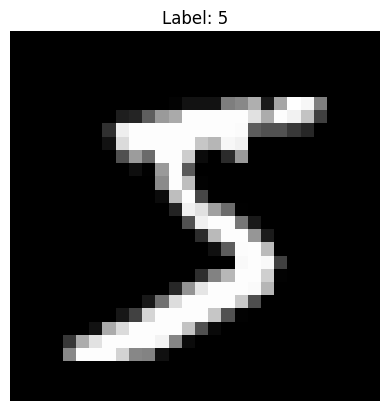

In [88]:
# ============================================================
# BLOK 5 — MNIST GÖRÜNTÜSÜNÜ GÖRSELLEŞTİRME
# Amaç: Tensor olarak yüklediğimiz MNIST görüntüsünü
#       görsel olarak incelemek.
# ============================================================

import matplotlib.pyplot as plt              # Matplotlib: görüntü ve grafik çizmek için

plt.imshow(image.squeeze(), cmap="gray")     # 1×28×28 yapısını 28×28 görüntü olarak gösterir
plt.title(f"Label: {label}")                  # Görüntünün gerçek etiketini başlığa yazar
plt.axis("off")                              # Eksenleri gizler
plt.show()                                   # Görüntüyü ekranda gösterir

In [89]:
# ============================================================
# BLOK 6 — FLATTEN (DÜZLEŞTİRME)
# Amaç: 28×28 piksel görüntüyü 784 elemanlı tek boyutlu
#       bir vektöre dönüştürmek.
# ============================================================

flat_image = image.flatten()                 # 1×28×28 Tensor'u tek boyutlu vektöre çevirir

print("Original shape:", image.shape)        # Görüntünün orijinal boyutunu gösterir
print("Flattened shape:", flat_image.shape)  # Düzleştirilmiş verinin boyutunu gösterir
print("Number of input values:", flat_image.numel())  # Toplam piksel/değer sayısını gösterir

Original shape: torch.Size([1, 28, 28])
Flattened shape: torch.Size([784])
Number of input values: 784


In [90]:
# ============================================================
# BLOK 7 — DATALOADER (VERİ YÜKLEYİCİ)
# Amaç: MNIST verilerini batch (mini grup) halinde modele
#       aktarılabilecek şekilde hazırlamak.
# ============================================================

from torch.utils.data import DataLoader       # PyTorch DataLoader: verileri batch halinde yüklemek için

BATCH_SIZE = 64                                # Her eğitim adımında kullanılacak örnek sayısı

train_loader = DataLoader(
    train_dataset,                             # Kullanacağımız eğitim veri seti
    batch_size=BATCH_SIZE,                      # Her batch'teki görüntü sayısı
    shuffle=True                                # Eğitim verilerini her epoch'ta karıştır
)

test_loader = DataLoader(
    test_dataset,                              # Kullanacağımız test veri seti
    batch_size=BATCH_SIZE,                     # Test batch boyutu
    shuffle=False                              # Test sırasını değiştirme
)

print("Batch size:", BATCH_SIZE)               # Kullanılan batch boyutunu gösterir
print("Number of training batches:", len(train_loader))  # Toplam eğitim batch sayısı
print("Number of test batches:", len(test_loader))       # Toplam test batch sayısı

Batch size: 64
Number of training batches: 938
Number of test batches: 157


In [91]:
# ============================================================
# BLOK 8 — MODEL ARCHITECTURE (MODEL MİMARİSİ)
# Amaç: MNIST sınıflandırması için temel sinir ağı modelini
#       oluşturmak.
#
# Mimari:
# 784 → 128 → 64 → 10
# Activation: ReLU
# ============================================================

class BaselineModel(nn.Module):
    # BaselineModel: PyTorch üzerinde oluşturduğumuz
    # temel yapay sinir ağı (neural network) modeli

    def __init__(self):
        super().__init__()                       # PyTorch modelinin temel yapısını başlatır

        self.flatten = nn.Flatten()              # 1×28×28 görüntüyü 784 elemanlı vektöre çevirir

        self.fc1 = nn.Linear(784, 128)           # İlk Linear katman: 784 giriş → 128 nöron
        self.relu1 = nn.ReLU()                   # ReLU aktivasyon fonksiyonu

        self.fc2 = nn.Linear(128, 64)            # İkinci Linear katman: 128 → 64 nöron
        self.relu2 = nn.ReLU()                   # İkinci ReLU aktivasyon fonksiyonu

        self.fc3 = nn.Linear(64, 10)             # Çıkış katmanı: 64 → 10 sınıf

    def forward(self, x):
        # forward: Verinin model içerisinden hangi sırayla geçeceğini belirler

        x = self.flatten(x)                      # 1×28×28 → 784
        x = self.fc1(x)                          # 784 → 128
        x = self.relu1(x)                        # ReLU uygula

        x = self.fc2(x)                          # 128 → 64
        x = self.relu2(x)                        # ReLU uygula

        x = self.fc3(x)                          # 64 → 10

        return x                                 # Modelin çıktısını döndür

        # Model nesnesini oluşturuyoruz
model = BaselineModel().to(device)               # Modeli oluştur ve CPU/GPU cihazına gönder

print(model)                                     # Model mimarisini ekrana yazdır

BaselineModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [92]:
# ============================================================
# BLOK 9 — LOSS FUNCTION + OPTIMIZER
# Amaç: Modelin hatasını ölçmek ve model parametrelerini
#       bu hataya göre güncellemek.
# ============================================================

criterion = nn.CrossEntropyLoss()        # Cross Entropy: sınıflandırma hatasını ölçen loss function

optimizer = optim.Adam(
    model.parameters(),                  # Modeldeki öğrenilebilir weight ve bias parametreleri
    lr=0.001                              # Learning rate (öğrenme hızı)
)

print("Loss function:", criterion)       # Kullanılan loss function'ı gösterir
print("Optimizer:", optimizer)           # Kullanılan optimizer'ı gösterir
print("Learning rate:", 0.001)            # Öğrenme hızını gösterir

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning rate: 0.001


In [93]:
# ============================================================
# BLOK 10 — TRAINING LOOP (EĞİTİM DÖNGÜSÜ)
# Amaç: Modelin MNIST eğitim verisi üzerinden öğrenmesini
#       sağlamak ve her epoch sonunda loss değerini kaydetmek.
# ============================================================

EPOCHS = 5                                      # Modelin tüm eğitim verisini kaç kez göreceği

train_losses = []                               # Her epoch'un ortalama loss değerlerini saklar

start_time = time.time()                         # Eğitim başlangıç zamanını kaydeder

for epoch in range(EPOCHS):

    model.train()                                # Modeli training (eğitim) moduna geçir

    running_loss = 0.0                           # Epoch boyunca oluşan toplam loss

    for images, labels in train_loader:

        images = images.to(device)              # Görüntüleri seçilen cihaza gönder
        labels = labels.to(device)              # Etiketleri seçilen cihaza gönder

        optimizer.zero_grad()                   # Önceki adımın gradient değerlerini temizle

        outputs = model(images)                 # Modelden tahminleri al

        loss = criterion(outputs, labels)       # Tahmin ile gerçek etiket arasındaki hatayı hesapla

        loss.backward()                         # Backpropagation: gradientleri hesapla

        optimizer.step()                        # Optimizer ile weight ve bias değerlerini güncelle

        running_loss += loss.item()             # Bu batch'in loss değerini toplama ekle

    epoch_loss = running_loss / len(train_loader)  # Epoch'un ortalama loss değerini hesapla

    train_losses.append(epoch_loss)             # Loss değerini listeye kaydet

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Training Loss: {epoch_loss:.4f}"
    )

training_time = time.time() - start_time         # Toplam eğitim süresini hesapla

print(f"Training time: {training_time:.2f} seconds")  # Eğitim süresini göster

Epoch [1/5] Training Loss: 0.3328
Epoch [2/5] Training Loss: 0.1354
Epoch [3/5] Training Loss: 0.0945
Epoch [4/5] Training Loss: 0.0717
Epoch [5/5] Training Loss: 0.0558
Training time: 84.38 seconds


In [94]:
# ============================================================
# BLOK 11 — TEST / BASELINE ACCURACY
# Amaç: Eğitilmiş modelin daha önce görmediği test verileri
#       üzerindeki sınıflandırma başarısını ölçmek.
# ============================================================

model.eval()                                  # Modeli evaluation (değerlendirme) moduna geçir

correct = 0                                   # Doğru tahmin sayısını tutar
total = 0                                     # Toplam test örneği sayısını tutar

with torch.no_grad():                         # Test sırasında gradient hesaplamasını kapatır

    for images, labels in test_loader:

        images = images.to(device)            # Görüntüleri kullanılan cihaza gönder
        labels = labels.to(device)            # Gerçek etiketleri kullanılan cihaza gönder

        outputs = model(images)               # Modelden tahminleri al

        _, predicted = torch.max(outputs, 1)  # En yüksek skora sahip sınıfı tahmin olarak seç

        total += labels.size(0)               # Bu batch'teki örnek sayısını toplama ekle
        correct += (predicted == labels).sum().item()  # Doğru tahminleri say

accuracy = 100 * correct / total              # Test accuracy (test doğruluğu) hesapla

print(f"Correct predictions: {correct}")      # Doğru tahmin sayısını göster
print(f"Total test samples: {total}")         # Toplam test örneğini göster
print(f"Test Accuracy: {accuracy:.2f}%")       # Test doğruluğunu yüzde olarak göster

Correct predictions: 9756
Total test samples: 10000
Test Accuracy: 97.56%


In [95]:
# ============================================================
# BLOK 12 — BASELINE EXPERIMENT SUMMARY
# Amaç: Baseline deneyinin temel parametre ve sonuçlarını
#       tek bir yapı içerisinde kayıt altına almak.
# ============================================================

baseline_results = {
    "dataset": "MNIST",                       # Kullanılan veri seti
    "input_size": 784,                        # Flatten sonrası giriş boyutu
    "hidden_layer_1": 128,                    # İlk hidden layer nöron sayısı
    "hidden_layer_2": 64,                     # İkinci hidden layer nöron sayısı
    "output_size": 10,                        # Çıkış sınıfı sayısı
    "activation": "ReLU",                     # Kullanılan activation function
    "optimizer": "Adam",                      # Kullanılan optimizer
    "learning_rate": 0.001,                   # Learning rate
    "batch_size": BATCH_SIZE,                 # Batch size
    "epochs": EPOCHS,                         # Eğitim epoch sayısı
    "seed": SEED,                             # Random seed
    "device": str(device),                    # Kullanılan işlemci
    "training_time_seconds": training_time,  # Eğitim süresi
    "test_accuracy": accuracy                 # Test accuracy
}

print("BASELINE EXPERIMENT SUMMARY")
print("--------------------------------")

for key, value in baseline_results.items():
    print(f"{key}: {value}")

BASELINE EXPERIMENT SUMMARY
--------------------------------
dataset: MNIST
input_size: 784
hidden_layer_1: 128
hidden_layer_2: 64
output_size: 10
activation: ReLU
optimizer: Adam
learning_rate: 0.001
batch_size: 64
epochs: 5
seed: 42
device: cpu
training_time_seconds: 84.38077116012573
test_accuracy: 97.56


Confusion Matrix:
[[ 967    0    4    2    1    1    0    2    3    0]
 [   0 1128    3    0    0    1    1    1    1    0]
 [   4    0 1003    2    4    0    2   14    3    0]
 [   1    2    8  978    0    2    0   10    5    4]
 [   0    0    5    0  970    0    1    1    2    3]
 [   3    1    0   12    1  866    3    2    3    1]
 [   3    3    4    1   10    7  927    0    3    0]
 [   0    4    9    1    1    0    1 1010    1    1]
 [   0    0    3    7    4    7    0    7  946    0]
 [   4    5    0    7   16    4    0    7    5  961]]


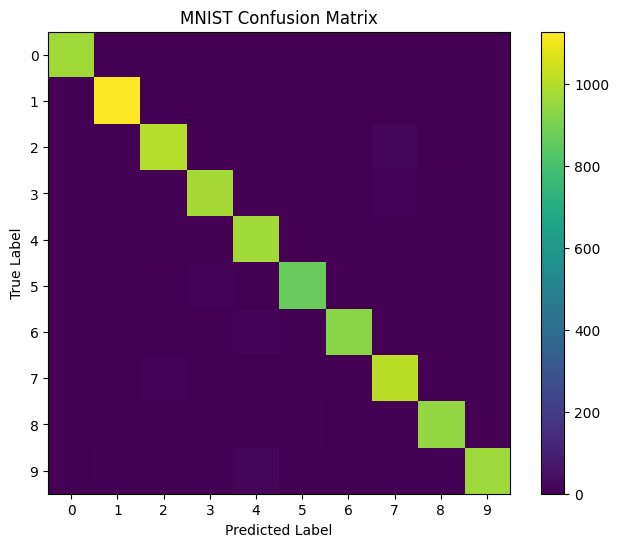

In [96]:
# ============================================================
# BLOK 13 — CONFUSION MATRIX (KARIŞIKLIK MATRİSİ)
# Amaç: Modelin hangi rakamları doğru, hangilerini yanlış
#       sınıflandırdığını sınıf bazında görmek.
# ============================================================

from sklearn.metrics import confusion_matrix  # confusion_matrix: gerçek ve tahmin edilen sınıfları karşılaştırır
import matplotlib.pyplot as plt                # Matplotlib: matrisi görselleştirmek için

model.eval()                                   # Modeli değerlendirme moduna alıyoruz

all_labels = []                                # Gerçek etiketleri burada toplayacağız
all_predictions = []                           # Model tahminlerini burada toplayacağız

with torch.no_grad():                          # Test sırasında gradient hesaplamasını kapatıyoruz
    for images, labels in test_loader:
        images = images.to(device)             # Görüntüleri kullanılan cihaza gönderiyoruz
        labels = labels.to(device)             # Etiketleri kullanılan cihaza gönderiyoruz

        outputs = model(images)                # Modelin tahmin skorlarını hesaplıyoruz
        _, predictions = torch.max(outputs, 1) # En yüksek skorlu sınıfı tahmin olarak seçiyoruz

        all_labels.extend(labels.cpu().numpy())       # Gerçek etiketleri listeye ekliyoruz
        all_predictions.extend(predictions.cpu().numpy()) # Tahminleri listeye ekliyoruz

# Gerçek ve tahmin edilen sınıflardan confusion matrix oluşturuyoruz
cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

# Confusion matrix'i görselleştiriyoruz
plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.title("MNIST Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()

In [97]:
# ============================================================
# BLOK 14 — FORWARD HOOK İLE INTERNAL ACTIVATION YAKALAMA
# Amaç: Modelin içindeki belirli bir layer'ın (katmanın)
#       ürettiği activation (aktivasyon) değerlerini gözlemlemek.
#
# Burada özellikle ikinci hidden layer'ın (gizli katmanın)
# çıkışını takip edeceğiz.
# ============================================================

activations = {}  # activations: yakaladığımız internal activation değerlerini saklayacak sözlük

def hook_fn(module, input, output):
    # Hook function: layer çalıştığı anda üretilen output'u yakalar.
    activations["fc2"] = output.detach().cpu()

# fc2 layer'ına forward hook (ileri geçiş kancası) bağlıyoruz.
# Böylece model her çalıştığında fc2'nin ürettiği activation değerini yakalayacağız.
hook = model.fc2.register_forward_hook(hook_fn)

# Modeli evaluation mode'a (değerlendirme modu) alıyoruz.
model.eval()

# Test verisinden tek bir batch (küme) alıyoruz.
images, labels = next(iter(test_loader))

# Görüntüleri modelin kullandığı cihaza gönderiyoruz.
images = images.to(device)

# Modeli çalıştırıyoruz.
# Model çalışırken hook_fn otomatik olarak devreye girecek.
with torch.no_grad():
    outputs = model(images)

# Hook'u kaldırıyoruz.
# Artık sonraki model çalıştırmalarında activation kaydetmeyecek.
hook.remove()

# Yakalanan activation değerinin boyutunu gösteriyoruz.
print("Activation shape:", activations["fc2"].shape)

# İlk örneğin ilk 10 neuron activation değerini gösteriyoruz.
print("\nİlk örneğin ilk 10 activation değeri:")
print(activations["fc2"][0][:10])

Activation shape: torch.Size([64, 64])

İlk örneğin ilk 10 activation değeri:
tensor([ 3.3235, -2.2484, -2.3961,  3.5262, -2.4293,  4.1987, -0.7781,  3.3512,
         0.6119,  4.2134])


In [98]:
# ============================================================
# BLOK 15 — RELU SONRASI INTERNAL ACTIVATION YAKALAMA
# Amaç: fc2 layer'ından sonra ReLU tarafından üretilen
#       gerçek activation (aktivasyon) değerlerini yakalamak.
#
# ReLU negatif değerleri 0'a çevirdiği için burada modelin
# sonraki layer'a gerçekten aktardığı değerleri inceleyeceğiz.
# ============================================================

activations = {}  # Yakalanan activation değerlerini saklamak için sözlük

def hook_fn(module, input, output):
    # ReLU2'nin çıkışını yakalıyoruz.
    # detach(): gradient (gradyan) bağlantısını koparır.
    # cpu(): veriyi CPU'ya taşır.
    activations["relu2"] = output.detach().cpu()

# relu2 layer'ına forward hook bağlıyoruz.
hook = model.relu2.register_forward_hook(hook_fn)

# Modeli evaluation mode'a alıyoruz.
model.eval()

# Test setinden bir batch alıyoruz.
images, labels = next(iter(test_loader))

# Görüntüleri kullanılan cihaza gönderiyoruz.
images = images.to(device)

# Modeli çalıştırıyoruz.
# Bu sırada hook_fn otomatik olarak çalışacak.
with torch.no_grad():
    outputs = model(images)

# Hook'u kaldırıyoruz.
hook.remove()

# Yakalanan activation matrisinin boyutunu gösteriyoruz.
print("Activation shape:", activations["relu2"].shape)

# İlk görüntünün ilk 10 activation değerini gösteriyoruz.
print("\nİlk örneğin ilk 10 activation değeri:")
print(activations["relu2"][0][:10])

Activation shape: torch.Size([64, 64])

İlk örneğin ilk 10 activation değeri:
tensor([3.3235, 0.0000, 0.0000, 3.5262, 0.0000, 4.1987, 0.0000, 3.3512, 0.6119,
        4.2134])


In [99]:
# ============================================================
# BLOK 16 — TÜM TEST SETİNİN ACTIVATION'LARINI TOPLAMA
# Amaç: Test setindeki 10.000 görüntünün tamamı için
#       ReLU2 sonrası 64 neuron activation değerini toplamak.
#
# Sonuç:
#   activation_matrix → [10000, 64]
#   all_labels        → [10000]
#
# Böylece daha sonra neuron'ları sınıf bazında karşılaştırabileceğiz.
# ============================================================

all_activations = []  # Her batch'in activation değerlerini saklayacak liste
all_labels = []       # Her görüntünün gerçek sınıfını saklayacak liste

model.eval()

# ReLU2 layer'ına forward hook bağlıyoruz.
def hook_fn(module, input, output):
    # ReLU2 çıkışındaki activation değerlerini yakalıyoruz.
    current_activation = output.detach().cpu()

    # Mevcut batch'in activation değerlerini listeye ekliyoruz.
    all_activations.append(current_activation)

hook = model.relu2.register_forward_hook(hook_fn)

# Test setinin tamamını modelden geçiriyoruz.
with torch.no_grad():
    for images, labels in test_loader:

        # Görüntüleri kullanılan cihaza gönderiyoruz.
        images = images.to(device)

        # Modeli çalıştırıyoruz.
        # Hook burada otomatik olarak activation değerlerini yakalar.
        outputs = model(images)

        # Gerçek label'ları CPU'ya alıp saklıyoruz.
        all_labels.append(labels)

# Hook'u kaldırıyoruz.
hook.remove()

# Batch'leri tek bir büyük tensor haline getiriyoruz.
activation_matrix = torch.cat(all_activations, dim=0)

# Label batch'lerini de tek bir tensor haline getiriyoruz.
all_labels = torch.cat(all_labels, dim=0)

# Sonuçların boyutlarını kontrol ediyoruz.
print("Activation matrix shape:", activation_matrix.shape)
print("Labels shape:", all_labels.shape)

# İlk görüntünün ilk 10 activation değerini tekrar gösteriyoruz.
print("\nİlk görüntünün ilk 10 activation değeri:")
print(activation_matrix[0][:10])

Activation matrix shape: torch.Size([10000, 64])
Labels shape: torch.Size([10000])

İlk görüntünün ilk 10 activation değeri:
tensor([3.3235, 0.0000, 0.0000, 3.5262, 0.0000, 4.1987, 0.0000, 3.3512, 0.6119,
        4.2134])


In [100]:
# ============================================================
# BLOK 17 — NEURON ACTIVATION İSTATİSTİKLERİ
# Amaç: 64 neuron'un test setindeki genel activation
#       davranışını ölçmek.
#
# Ölçümler:
#   1. Mean activation → Ortalama aktivasyon
#   2. Max activation  → Maksimum aktivasyon
#   3. Zero ratio      → Aktivasyonun 0 olduğu örnek oranı
# ============================================================

# Her neuron için ortalama activation değerini hesaplıyoruz.
# dim=0: 10.000 görüntü boyunca hesaplama yapar,
# böylece her neuron için tek bir ortalama değer elde ederiz.
mean_activation = activation_matrix.mean(dim=0)

# Her neuron'un test setinde gördüğü maksimum activation değerini buluyoruz.
max_activation = activation_matrix.max(dim=0).values

# Activation değeri 0 olan hücreleri True/False olarak belirliyoruz.
zero_mask = activation_matrix == 0

# Her neuron için sıfır olan activation oranını hesaplıyoruz.
zero_ratio = zero_mask.float().mean(dim=0)

# Sonuçları tablo halinde yazdırıyoruz.
print("Neuron Activation Statistics")
print("=" * 60)

for neuron_idx in range(64):
    print(
        f"Neuron {neuron_idx:2d} | "
        f"Mean: {mean_activation[neuron_idx]:6.3f} | "
        f"Max: {max_activation[neuron_idx]:6.3f} | "
        f"Zero Ratio: {zero_ratio[neuron_idx]:6.2%}"
    )

Neuron Activation Statistics
Neuron  0 | Mean:  1.646 | Max:  7.642 | Zero Ratio: 20.06%
Neuron  1 | Mean:  1.804 | Max: 14.705 | Zero Ratio: 50.26%
Neuron  2 | Mean:  1.507 | Max:  9.364 | Zero Ratio: 40.29%
Neuron  3 | Mean:  2.644 | Max:  8.859 | Zero Ratio: 11.73%
Neuron  4 | Mean:  0.000 | Max:  0.000 | Zero Ratio: 100.00%
Neuron  5 | Mean:  2.317 | Max:  8.780 | Zero Ratio: 10.67%
Neuron  6 | Mean:  0.366 | Max:  4.721 | Zero Ratio: 65.02%
Neuron  7 | Mean:  3.339 | Max: 10.374 | Zero Ratio: 15.48%
Neuron  8 | Mean:  2.464 | Max: 12.871 | Zero Ratio: 27.11%
Neuron  9 | Mean:  1.604 | Max: 11.170 | Zero Ratio: 37.95%
Neuron 10 | Mean:  2.529 | Max: 10.447 | Zero Ratio: 11.73%
Neuron 11 | Mean:  1.559 | Max: 12.522 | Zero Ratio: 44.22%
Neuron 12 | Mean:  2.139 | Max: 13.088 | Zero Ratio: 21.70%
Neuron 13 | Mean:  1.381 | Max:  7.594 | Zero Ratio: 27.84%
Neuron 14 | Mean:  2.579 | Max:  9.342 | Zero Ratio: 13.08%
Neuron 15 | Mean:  1.656 | Max:  8.915 | Zero Ratio: 35.72%
Neuron 16 

In [101]:
# ============================================================
# BLOK 18 — SINIF BAZINDA NEURON ACTIVATION ANALİZİ
# Amaç: Her neuron'un 0-9 arasındaki sınıflarda ortalama
#       activation değerini hesaplamak.
#
# Sonuç:
#   64 neuron × 10 class
#
# Böylece hangi neuron'un hangi sınıflarda daha fazla
# aktive olduğunu gözlemleyebileceğiz.
# ============================================================

# 64 neuron × 10 class boyutunda boş bir tensor oluşturuyoruz.
class_mean_activation = torch.zeros(64, 10)

# Her sınıfı ayrı ayrı inceliyoruz.
for class_idx in range(10):

    # O sınıfa ait görüntülerin indekslerini buluyoruz.
    class_mask = all_labels == class_idx

    # O sınıfa ait activation değerlerini seçiyoruz.
    class_activations = activation_matrix[class_mask]

    # Her neuron için o sınıftaki ortalama activation değerini hesaplıyoruz.
    class_mean_activation[:, class_idx] = class_activations.mean(dim=0)

# Sonuç matrisinin boyutunu kontrol ediyoruz.
print("Class mean activation shape:", class_mean_activation.shape)

# İlk 10 neuron'un 10 sınıftaki ortalama activation değerlerini gösteriyoruz.
print("\nİlk 10 neuron için sınıf bazında ortalama activation:")
print(class_mean_activation[:10])

Class mean activation shape: torch.Size([64, 10])

İlk 10 neuron için sınıf bazında ortalama activation:
tensor([[3.2892, 1.2981, 2.6416, 3.3461, 0.1294, 0.5303, 0.2747, 2.7861, 1.3183,
         0.6434],
        [5.2356, 0.6653, 4.0848, 0.2552, 0.7507, 0.2618, 6.6715, 0.0990, 0.1228,
         0.0932],
        [0.1466, 2.3162, 0.9400, 0.0664, 5.2419, 0.7739, 0.5570, 0.3256, 1.7628,
         2.8133],
        [3.7944, 0.2428, 2.9604, 3.0887, 0.4715, 3.4059, 1.0190, 3.8179, 3.9580,
         3.9821],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [3.3487, 1.5992, 1.5010, 3.6542, 2.6870, 0.9113, 0.5062, 4.4146, 0.4949,
         3.8397],
        [0.8084, 0.7139, 0.0184, 0.0181, 0.9589, 0.2603, 0.0207, 0.5301, 0.0747,
         0.2071],
        [0.3687, 3.2094, 5.3364, 4.7275, 4.7801, 0.4139, 0.4867, 4.2223, 4.4583,
         4.8432],
        [2.1741, 0.1801, 3.2335, 5.3330, 0.1360, 6.2616, 2.5139, 0.2807, 4.6208,
         0.6614],
    

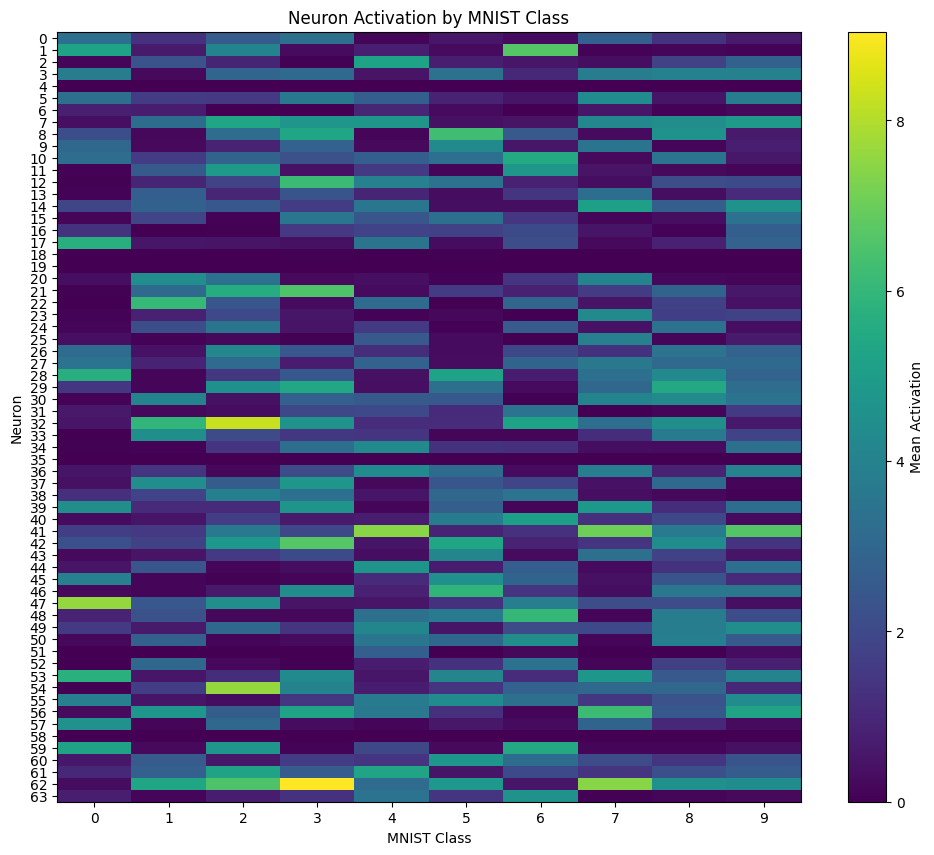

In [102]:
# ============================================================
# BLOK 19 — CLASS × NEURON ACTIVATION HEATMAP
# Amaç: 64 neuron'un 10 farklı sınıftaki ortalama
#       activation değerlerini görsel olarak karşılaştırmak.
#
# Satırlar → Neuron
# Sütunlar → MNIST class (0-9)
# Hücre değeri → Ortalama activation
# ============================================================

import matplotlib.pyplot as plt  # Matplotlib: activation matrisini görselleştirmek için

# Tensor'ı NumPy array'e çeviriyoruz.
heatmap_data = class_mean_activation.numpy()

# Grafik alanını oluşturuyoruz.
plt.figure(figsize=(12, 10))

# Activation matrisini heatmap olarak gösteriyoruz.
plt.imshow(heatmap_data, aspect="auto")

# Renk skalasını gösteriyoruz.
plt.colorbar(label="Mean Activation")

# X eksenine MNIST sınıflarını yerleştiriyoruz.
plt.xticks(range(10), range(10))

# Y eksenine neuron numaralarını yerleştiriyoruz.
plt.yticks(range(64), range(64))

# Grafik başlığını belirliyoruz.
plt.title("Neuron Activation by MNIST Class")

# Eksen isimlerini belirliyoruz.
plt.xlabel("MNIST Class")
plt.ylabel("Neuron")

# Grafiği gösteriyoruz.
plt.show()

In [103]:
# ============================================================
# BLOK 20 — NEURON SELECTIVITY ANALİZİ
# Amaç: Her neuron'un hangi MNIST sınıfında en yüksek
#       activation gösterdiğini ve ne kadar seçici olduğunu
#       sayısal olarak belirlemek.
#
# Selectivity:
#   En yüksek sınıf activation'ı ile
#   ikinci en yüksek sınıf activation'ı arasındaki fark.
#
# Büyük fark → daha belirgin sınıf seçiciliği
# Küçük fark → daha dengeli activation profili
# ============================================================

# Her neuron için en yüksek activation değerinin hangi
# sınıfa ait olduğunu buluyoruz.
top_values, top_classes = torch.max(class_mean_activation, dim=1)

# Her neuron için ikinci en yüksek activation değerini buluyoruz.
sorted_values, sorted_indices = torch.sort(
    class_mean_activation,
    dim=1,
    descending=True
)

second_values = sorted_values[:, 1]

# En yüksek ve ikinci en yüksek değer arasındaki farkı
# selectivity (seçicilik) ölçüsü olarak kullanıyoruz.
selectivity = top_values - second_values

# Sonuçları büyükten küçüğe sıralıyoruz.
sorted_neurons = torch.argsort(selectivity, descending=True)

print("Neuron Selectivity Ranking")
print("=" * 75)

# En seçici ilk 15 neuron'u gösteriyoruz.
for rank, neuron_idx in enumerate(sorted_neurons[:15], start=1):

    print(
        f"{rank:2d}. Neuron {neuron_idx.item():2d} | "
        f"Top Class: {top_classes[neuron_idx].item()} | "
        f"Top Activation: {top_values[neuron_idx]:6.3f} | "
        f"Second: {second_values[neuron_idx]:6.3f} | "
        f"Selectivity: {selectivity[neuron_idx]:6.3f}"
    )

Neuron Selectivity Ranking
 1. Neuron 54 | Top Class: 2 | Top Activation:  7.623 | Second:  4.061 | Selectivity:  3.561
 2. Neuron 47 | Top Class: 0 | Top Activation:  7.609 | Second:  4.446 | Selectivity:  3.163
 3. Neuron 22 | Top Class: 1 | Top Activation:  6.043 | Second:  3.162 | Selectivity:  2.881
 4. Neuron  2 | Top Class: 4 | Top Activation:  5.242 | Second:  2.813 | Selectivity:  2.429
 5. Neuron 51 | Top Class: 4 | Top Activation:  2.703 | Second:  0.312 | Selectivity:  2.392
 6. Neuron 32 | Top Class: 2 | Top Activation:  8.273 | Second:  5.946 | Selectivity:  2.327
 7. Neuron 23 | Top Class: 7 | Top Activation:  4.305 | Second:  1.989 | Selectivity:  2.316
 8. Neuron 48 | Top Class: 6 | Top Activation:  6.012 | Second:  3.781 | Selectivity:  2.231
 9. Neuron 12 | Top Class: 3 | Top Activation:  6.146 | Second:  3.942 | Selectivity:  2.204
10. Neuron 17 | Top Class: 0 | Top Activation:  5.680 | Second:  3.487 | Selectivity:  2.193
11. Neuron 10 | Top Class: 6 | Top Activati

In [104]:
# ============================================================
# BLOK 21 — NEURON 54 ABLATION (NÖRON ÇIKARMA)
# Amaç: Neuron 54'ün activation değerini kontrollü olarak
#       sıfırlayıp model çıktısında meydana gelen değişimi
#       ölçmek.
#
# Neuron 54:
#   En güçlü sınıf → 2
#   Selectivity    → 3.561
#
# Karşılaştırma:
#   Normal model
#        VS
#   Neuron 54 ablated model
# ============================================================

# Ablation uygulanacak neuron'u belirliyoruz.
target_neuron = 54

# Normal modelin accuracy'sini tekrar hesaplamak için
# doğru tahmin sayısını tutuyoruz.
normal_correct = 0

# Ablation uygulanmış modelin doğru tahmin sayısını tutuyoruz.
ablated_correct = 0

# Class 2 için normal ve ablated doğru tahmin sayılarını
# ayrıca takip ediyoruz.
normal_class2_correct = 0
ablated_class2_correct = 0

# Class 2'deki toplam örnek sayısını tutuyoruz.
total_class2 = 0


# ------------------------------------------------------------
# ABLATION HOOK
# ------------------------------------------------------------
def ablation_hook(module, input, output):
    # Output'u clone ediyoruz.
    # Böylece orijinal activation tensor'ını değiştirmiyoruz.
    modified_output = output.clone()

    # Seçtiğimiz neuron'un activation değerini tüm batch
    # için sıfırlıyoruz.
    modified_output[:, target_neuron] = 0

    # Değiştirilmiş activation değerini sonraki layer'a gönderiyoruz.
    return modified_output


# ------------------------------------------------------------
# NORMAL MODEL
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        # Görüntüleri kullanılan cihaza gönderiyoruz.
        images = images.to(device)

        # Label'ları da aynı cihaza gönderiyoruz.
        labels = labels.to(device)

        # Normal model çıktısını hesaplıyoruz.
        outputs = model(images)

        # En yüksek output değerine sahip sınıfı tahmin olarak alıyoruz.
        _, predictions = torch.max(outputs, 1)

        # Genel doğru tahmin sayısını hesaplıyoruz.
        normal_correct += (predictions == labels).sum().item()

        # Class 2 örneklerini seçiyoruz.
        class2_mask = labels == 2

        # Class 2 toplam örnek sayısını güncelliyoruz.
        total_class2 += class2_mask.sum().item()

        # Class 2'de doğru tahmin edilenleri sayıyoruz.
        normal_class2_correct += (
            (predictions[class2_mask] == labels[class2_mask])
        ).sum().item()


# ------------------------------------------------------------
# ABLATED MODEL
# ------------------------------------------------------------

# Ablation hook'unu relu2 layer'ına bağlıyoruz.
hook = model.relu2.register_forward_hook(ablation_hook)

with torch.no_grad():

    for images, labels in test_loader:

        # Görüntüleri kullanılan cihaza gönderiyoruz.
        images = images.to(device)

        # Label'ları kullanılan cihaza gönderiyoruz.
        labels = labels.to(device)

        # Model çalışırken Neuron 54 sıfırlanacak.
        outputs = model(images)

        # Ablation sonrası tahmini alıyoruz.
        _, predictions = torch.max(outputs, 1)

        # Genel doğru tahmin sayısını hesaplıyoruz.
        ablated_correct += (predictions == labels).sum().item()

        # Class 2 örneklerini seçiyoruz.
        class2_mask = labels == 2

        # Class 2'de doğru tahmin edilenleri sayıyoruz.
        ablated_class2_correct += (
            (predictions[class2_mask] == labels[class2_mask])
        ).sum().item()


# Ablation hook'unu kaldırıyoruz.
hook.remove()


# ------------------------------------------------------------
# SONUÇLARI HESAPLA
# ------------------------------------------------------------

normal_accuracy = normal_correct / len(test_loader.dataset)
ablated_accuracy = ablated_correct / len(test_loader.dataset)

normal_class2_accuracy = normal_class2_correct / total_class2
ablated_class2_accuracy = ablated_class2_correct / total_class2

# Accuracy değişimini hesaplıyoruz.
accuracy_change = ablated_accuracy - normal_accuracy

# Class 2 accuracy değişimini hesaplıyoruz.
class2_accuracy_change = (
    ablated_class2_accuracy - normal_class2_accuracy
)


# ------------------------------------------------------------
# SONUÇLARI YAZDIR
# ------------------------------------------------------------

print("Neuron 54 Ablation Results")
print("=" * 60)

print(f"Target neuron: {target_neuron}")

print(f"\nNormal accuracy:  {normal_accuracy:.4%}")
print(f"Ablated accuracy: {ablated_accuracy:.4%}")
print(f"Accuracy change:  {accuracy_change:+.4%}")

print("\nClass 2 Analysis")
print(f"Normal Class 2 accuracy:  {normal_class2_accuracy:.4%}")
print(f"Ablated Class 2 accuracy: {ablated_class2_accuracy:.4%}")
print(f"Class 2 accuracy change:  {class2_accuracy_change:+.4%}")

Neuron 54 Ablation Results
Target neuron: 54

Normal accuracy:  97.5600%
Ablated accuracy: 97.5300%
Accuracy change:  -0.0300%

Class 2 Analysis
Normal Class 2 accuracy:  97.1899%
Ablated Class 2 accuracy: 96.8023%
Class 2 accuracy change:  -0.3876%


In [105]:
# ============================================================
# BLOK 22 — NEURON 47 ABLATION (NÖRON ÇIKARMA)
# Amaç: Neuron 47'nin activation değerini kontrollü olarak
#       sıfırlayıp model çıktısında meydana gelen değişimi
#       ölçmek.
#
# Neuron 47:
#   En güçlü sınıf → 0
#   Selectivity    → 3.163
#
# Karşılaştırma:
#   Normal model
#        VS
#   Neuron 47 ablated model
# ============================================================

# Ablation uygulanacak neuron'u belirliyoruz.
target_neuron = 47

# Normal modelin doğru tahmin sayısını tutuyoruz.
normal_correct = 0

# Ablation uygulanmış modelin doğru tahmin sayısını tutuyoruz.
ablated_correct = 0

# Class 0 için normal ve ablated doğru tahmin sayılarını
# ayrıca takip ediyoruz.
normal_class0_correct = 0
ablated_class0_correct = 0

# Class 0'daki toplam örnek sayısını tutuyoruz.
total_class0 = 0


# ------------------------------------------------------------
# ABLATION HOOK
# ------------------------------------------------------------

def ablation_hook(module, input, output):
    # Output tensor'ının kopyasını oluşturuyoruz.
    # Böylece orijinal activation değerini doğrudan değiştirmiyoruz.
    modified_output = output.clone()

    # Neuron 47'nin activation değerini bütün batch için
    # sıfırlıyoruz.
    modified_output[:, target_neuron] = 0

    # Değiştirilmiş activation değerini sonraki layer'a gönderiyoruz.
    return modified_output


# ------------------------------------------------------------
# NORMAL MODEL
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        # Görüntüleri kullanılan cihaza gönderiyoruz.
        images = images.to(device)

        # Label'ları kullanılan cihaza gönderiyoruz.
        labels = labels.to(device)

        # Normal model çıktısını hesaplıyoruz.
        outputs = model(images)

        # En yüksek output değerine sahip sınıfı tahmin olarak alıyoruz.
        _, predictions = torch.max(outputs, 1)

        # Genel doğru tahmin sayısını güncelliyoruz.
        normal_correct += (predictions == labels).sum().item()

        # Class 0 örneklerini seçiyoruz.
        class0_mask = labels == 0

        # Class 0 toplam örnek sayısını güncelliyoruz.
        total_class0 += class0_mask.sum().item()

        # Class 0'da doğru tahmin edilenleri sayıyoruz.
        normal_class0_correct += (
            (predictions[class0_mask] == labels[class0_mask])
        ).sum().item()


# ------------------------------------------------------------
# ABLATED MODEL
# ------------------------------------------------------------

# Neuron 47'yi sıfırlayan hook'u relu2 layer'ına bağlıyoruz.
hook = model.relu2.register_forward_hook(ablation_hook)

with torch.no_grad():

    for images, labels in test_loader:

        # Görüntüleri kullanılan cihaza gönderiyoruz.
        images = images.to(device)

        # Label'ları kullanılan cihaza gönderiyoruz.
        labels = labels.to(device)

        # Model çalışırken Neuron 47 sıfırlanacak.
        outputs = model(images)

        # Ablation sonrası tahmini alıyoruz.
        _, predictions = torch.max(outputs, 1)

        # Genel doğru tahmin sayısını güncelliyoruz.
        ablated_correct += (predictions == labels).sum().item()

        # Class 0 örneklerini seçiyoruz.
        class0_mask = labels == 0

        # Class 0'da doğru tahmin edilenleri sayıyoruz.
        ablated_class0_correct += (
            (predictions[class0_mask] == labels[class0_mask])
        ).sum().item()


# Ablation hook'unu kaldırıyoruz.
hook.remove()


# ------------------------------------------------------------
# SONUÇLARI HESAPLA
# ------------------------------------------------------------

# Genel accuracy değerlerini hesaplıyoruz.
normal_accuracy = normal_correct / len(test_loader.dataset)
ablated_accuracy = ablated_correct / len(test_loader.dataset)

# Class 0 accuracy değerlerini hesaplıyoruz.
normal_class0_accuracy = normal_class0_correct / total_class0
ablated_class0_accuracy = ablated_class0_correct / total_class0

# Genel accuracy değişimini hesaplıyoruz.
accuracy_change = ablated_accuracy - normal_accuracy

# Class 0 accuracy değişimini hesaplıyoruz.
class0_accuracy_change = (
    ablated_class0_accuracy - normal_class0_accuracy
)


# ------------------------------------------------------------
# SONUÇLARI YAZDIR
# ------------------------------------------------------------

print("Neuron 47 Ablation Results")
print("=" * 60)

print(f"Target neuron: {target_neuron}")

print(f"\nNormal accuracy:  {normal_accuracy:.4%}")
print(f"Ablated accuracy: {ablated_accuracy:.4%}")
print(f"Accuracy change:  {accuracy_change:+.4%}")

print("\nClass 0 Analysis")
print(f"Normal Class 0 accuracy:  {normal_class0_accuracy:.4%}")
print(f"Ablated Class 0 accuracy: {ablated_class0_accuracy:.4%}")
print(f"Class 0 accuracy change:  {class0_accuracy_change:+.4%}")

Neuron 47 Ablation Results
Target neuron: 47

Normal accuracy:  97.5600%
Ablated accuracy: 97.4600%
Accuracy change:  -0.1000%

Class 0 Analysis
Normal Class 0 accuracy:  98.6735%
Ablated Class 0 accuracy: 97.7551%
Class 0 accuracy change:  -0.9184%


In [106]:
# ============================================================
# BLOK 23 — NEURON 62 CONTROL ABLATION
# Amaç: Daha düşük class selectivity'ye sahip bir neuron'un
#       ablation sonrası etkisini kontrol olarak ölçmek.
#
# Neuron 62:
#   Top Class: 3
#   Selectivity: 1.596
#
# Önceki deney:
#   Neuron 47 → Selectivity 3.163 → Class 0 etkisi -0.9184
#
# Bu deney:
#   Neuron 62 → Selectivity 1.596 → Class 3 etkisi ?
# ============================================================

# Ablation uygulanacak neuron'u belirliyoruz.
target_neuron = 62

# Normal modelin doğru tahmin sayısını tutuyoruz.
normal_correct = 0

# Ablation uygulanmış modelin doğru tahmin sayısını tutuyoruz.
ablated_correct = 0

# Class 3 için normal ve ablated doğru tahmin sayılarını
# ayrıca takip ediyoruz.
normal_class3_correct = 0
ablated_class3_correct = 0

# Class 3'teki toplam örnek sayısını tutuyoruz.
total_class3 = 0


# ------------------------------------------------------------
# ABLATION HOOK
# ------------------------------------------------------------

def ablation_hook(module, input, output):
    # Activation tensor'ının kopyasını oluşturuyoruz.
    modified_output = output.clone()

    # Neuron 62'nin activation değerini bütün batch için
    # sıfırlıyoruz.
    modified_output[:, target_neuron] = 0

    # Değiştirilmiş activation'ı sonraki layer'a gönderiyoruz.
    return modified_output


# ------------------------------------------------------------
# NORMAL MODEL
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        # Görüntüleri kullanılan cihaza gönderiyoruz.
        images = images.to(device)

        # Label'ları kullanılan cihaza gönderiyoruz.
        labels = labels.to(device)

        # Normal model çıktısını hesaplıyoruz.
        outputs = model(images)

        # En yüksek output değerine sahip sınıfı tahmin olarak alıyoruz.
        _, predictions = torch.max(outputs, 1)

        # Genel doğru tahmin sayısını güncelliyoruz.
        normal_correct += (predictions == labels).sum().item()

        # Class 3 örneklerini seçiyoruz.
        class3_mask = labels == 3

        # Class 3 toplam örnek sayısını güncelliyoruz.
        total_class3 += class3_mask.sum().item()

        # Class 3'te doğru tahmin edilenleri sayıyoruz.
        normal_class3_correct += (
            (predictions[class3_mask] == labels[class3_mask])
        ).sum().item()


# ------------------------------------------------------------
# ABLATED MODEL
# ------------------------------------------------------------

# Neuron 62'yi sıfırlayan hook'u relu2 layer'ına bağlıyoruz.
hook = model.relu2.register_forward_hook(ablation_hook)

with torch.no_grad():

    for images, labels in test_loader:

        # Görüntüleri kullanılan cihaza gönderiyoruz.
        images = images.to(device)

        # Label'ları kullanılan cihaza gönderiyoruz.
        labels = labels.to(device)

        # Model çalışırken Neuron 62 sıfırlanacak.
        outputs = model(images)

        # Ablation sonrası tahmini alıyoruz.
        _, predictions = torch.max(outputs, 1)

        # Genel doğru tahmin sayısını güncelliyoruz.
        ablated_correct += (predictions == labels).sum().item()

        # Class 3 örneklerini seçiyoruz.
        class3_mask = labels == 3

        # Class 3'te doğru tahmin edilenleri sayıyoruz.
        ablated_class3_correct += (
            (predictions[class3_mask] == labels[class3_mask])
        ).sum().item()


# Ablation hook'unu kaldırıyoruz.
hook.remove()


# ------------------------------------------------------------
# SONUÇLARI HESAPLA
# ------------------------------------------------------------

# Genel accuracy değerlerini hesaplıyoruz.
normal_accuracy = normal_correct / len(test_loader.dataset)
ablated_accuracy = ablated_correct / len(test_loader.dataset)

# Class 3 accuracy değerlerini hesaplıyoruz.
normal_class3_accuracy = normal_class3_correct / total_class3
ablated_class3_accuracy = ablated_class3_correct / total_class3

# Genel accuracy değişimini hesaplıyoruz.
accuracy_change = ablated_accuracy - normal_accuracy

# Class 3 accuracy değişimini hesaplıyoruz.
class3_accuracy_change = (
    ablated_class3_accuracy - normal_class3_accuracy
)


# ------------------------------------------------------------
# SONUÇLARI YAZDIR
# ------------------------------------------------------------

print("Neuron 62 Control Ablation Results")
print("=" * 60)

print(f"Target neuron: {target_neuron}")

print(f"\nNormal accuracy:  {normal_accuracy:.4%}")
print(f"Ablated accuracy: {ablated_accuracy:.4%}")
print(f"Accuracy change:  {accuracy_change:+.4%}")

print("\nClass 3 Analysis")
print(f"Normal Class 3 accuracy:  {normal_class3_accuracy:.4%}")
print(f"Ablated Class 3 accuracy: {ablated_class3_accuracy:.4%}")
print(f"Class 3 accuracy change:  {class3_accuracy_change:+.4%}")

Neuron 62 Control Ablation Results
Target neuron: 62

Normal accuracy:  97.5600%
Ablated accuracy: 97.6400%
Accuracy change:  +0.0800%

Class 3 Analysis
Normal Class 3 accuracy:  96.8317%
Ablated Class 3 accuracy: 96.3366%
Class 3 accuracy change:  -0.4950%


In [107]:
# ============================================================
# BLOK 24 — ACTIVATION INTERVENTION: CONTROLLED SCALING
# Amaç: Seçilen nöronun activation (aktivasyon) değerini
#       kontrollü olarak azaltıp/artırarak output probability
#       (çıktı olasılığı) üzerindeki etkisini ölçmek.
# ============================================================

import torch

# Experiment 3'te güçlü class-specific etki gösteren nöronu seçiyoruz.
target_neuron = 47

# Neuron 47'in en seçici olduğu sınıfı hedefliyoruz.
target_class = 0

# Activation (aktivasyon) değerini hangi oranlarda değiştireceğimizi belirliyoruz.
# 1.0 = normal davranış
# 0.5 = aktivasyonu yarıya indir
# 0.0 = aktivasyonu sıfırla
# 1.5 = aktivasyonu %50 artır
# 2.0 = aktivasyonu iki katına çıkar
scale_levels = [0.0, 0.5, 1.0, 1.5, 2.0]

# Her müdahalenin sonucunu burada saklayacağız.
intervention_results = []


# Her scale (ölçek) değeri için ayrı bir kontrollü deney yapıyoruz.
for scale in scale_levels:

    # Forward hook (ileri geçiş kancası):
    # Model relu2 katmanından geçerken seçilen nöronun
    # activation değerini değiştirmemizi sağlar.
    def intervention_hook(module, inputs, output):

        # Orijinal activation tensor'ünü değiştirmemek için kopyalıyoruz.
        modified_output = output.clone()

        # Sadece target_neuron (47) aktivasyonunu seçilen
        # scale değeri ile çarpıyoruz.
        modified_output[:, target_neuron] *= scale

        # Müdahale edilmiş activation değerini modele geri veriyoruz.
        return modified_output

    # Hook'u relu2 katmanına bağlıyoruz.
    hook = model.relu2.register_forward_hook(intervention_hook)

    # Evaluation mode (değerlendirme modu):
    # Test sırasında eğitim davranışlarının kullanılmamasını sağlar.
    model.eval()

    # Doğru tahmin sayısını tutacağız.
    total_correct = 0

    # Toplam örnek sayısını tutacağız.
    total_samples = 0

    # Tüm test örneklerinde Class 0 probability değerlerini saklayacağız.
    all_target_probs = []

    # Gerçek etiketi 0 olan örneklerdeki Class 0 probability değerlerini
    # ayrıca saklayacağız.
    target_class_probs = []

    # Gradient hesaplamıyoruz çünkü burada model eğitmiyoruz,
    # sadece kontrollü intervention (müdahale) uyguluyoruz.
    with torch.no_grad():

        # Test veri setinin tamamında aynı işlemi gerçekleştiriyoruz.
        for images, labels in test_loader:

            # Görüntüleri ve etiketleri kullanılan device'a gönderiyoruz.
            images = images.to(device)
            labels = labels.to(device)

            # Müdahale edilmiş modelden output (çıktı) alıyoruz.
            outputs = model(images)

            # Logit değerlerini probability (olasılık) değerlerine çeviriyoruz.
            probabilities = torch.softmax(outputs, dim=1)

            # En yüksek olasılığa sahip sınıfı tahmin olarak alıyoruz.
            predictions = torch.argmax(outputs, dim=1)

            # Doğru tahmin sayısını güncelliyoruz.
            total_correct += (predictions == labels).sum().item()

            # Toplam örnek sayısını güncelliyoruz.
            total_samples += labels.size(0)

            # Her örneğin Class 0 probability değerini saklıyoruz.
            all_target_probs.append(
                probabilities[:, target_class].cpu()
            )

            # Gerçek etiketi Class 0 olan örnekleri seçiyoruz.
            target_mask = labels == target_class

            # Bu batch içerisinde Class 0 örneği varsa probability değerlerini saklıyoruz.
            if target_mask.any():
                target_class_probs.append(
                    probabilities[target_mask, target_class].cpu()
                )

    # Deney bittikten sonra hook'u kaldırıyoruz.
    # Böylece bir sonraki scale değeri önceki müdahaleden etkilenmiyor.
    hook.remove()

    # Müdahale sonrası overall accuracy (genel doğruluk).
    accuracy = 100 * total_correct / total_samples

    # Tüm test örneklerinde ortalama Class 0 probability.
    mean_target_probability = torch.cat(all_target_probs).mean().item()

    # Gerçek etiketi Class 0 olan örneklerde ortalama Class 0 probability.
    mean_true_target_probability = torch.cat(
        target_class_probs
    ).mean().item()

    # Sonuçları kaydediyoruz.
    intervention_results.append({
        "scale": scale,
        "accuracy": accuracy,
        "mean_class_0_probability": mean_target_probability,
        "mean_true_class_0_probability": mean_true_target_probability
    })


# ============================================================
# SONUÇLAR
# ============================================================

print("Activation Intervention Results")
print("-" * 70)

# Her scale seviyesinin deney sonucunu ekrana yazdırıyoruz.
for result in intervention_results:

    print(
        f"Scale {result['scale']:.1f} | "
        f"Accuracy: {result['accuracy']:.4f}% | "
        f"Mean Class 0 Prob: "
        f"{result['mean_class_0_probability']:.4f} | "
        f"True Class 0 Prob: "
        f"{result['mean_true_class_0_probability']:.4f}"
    )

Activation Intervention Results
----------------------------------------------------------------------
Scale 0.0 | Accuracy: 97.4600% | Mean Class 0 Prob: 0.0956 | True Class 0 Prob: 0.9640
Scale 0.5 | Accuracy: 97.5400% | Mean Class 0 Prob: 0.0968 | True Class 0 Prob: 0.9735
Scale 1.0 | Accuracy: 97.5600% | Mean Class 0 Prob: 0.0977 | True Class 0 Prob: 0.9793
Scale 1.5 | Accuracy: 97.5600% | Mean Class 0 Prob: 0.0984 | True Class 0 Prob: 0.9829
Scale 2.0 | Accuracy: 97.5400% | Mean Class 0 Prob: 0.0990 | True Class 0 Prob: 0.9853


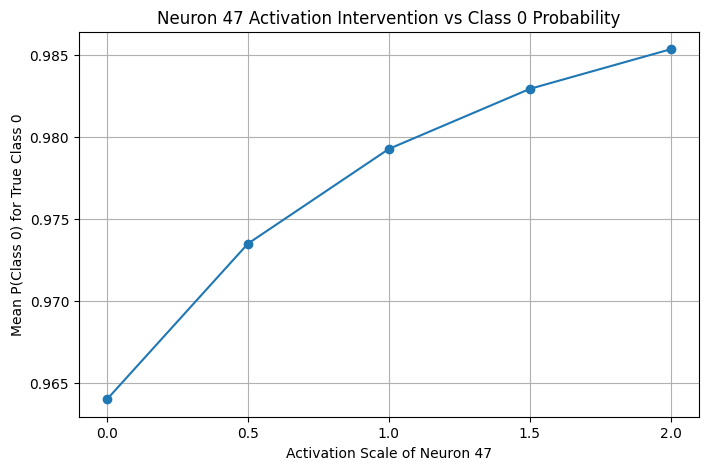

In [108]:
# ============================================================
# BLOK 25 — ACTIVATION INTERVENTION GRAFİĞİ
# Amaç: Activation scale (aktivasyon ölçeği) ile
#       Class 0 output probability (çıktı olasılığı)
#       arasındaki ilişkiyi görselleştirmek.
# ============================================================

import matplotlib.pyplot as plt

# Önceden kaydettiğimiz intervention sonuçlarından
# scale değerlerini çıkarıyoruz.
scales = [
    result["scale"]
    for result in intervention_results
]

# Gerçek Class 0 örneklerindeki ortalama Class 0
# probability değerlerini çıkarıyoruz.
true_class_0_probabilities = [
    result["mean_true_class_0_probability"]
    for result in intervention_results
]

# Grafik alanını oluşturuyoruz.
plt.figure(figsize=(8, 5))

# Intervention level (müdahale seviyesi) ile
# output probability (çıktı olasılığı) arasındaki ilişkiyi çiziyoruz.
plt.plot(
    scales,
    true_class_0_probabilities,
    marker="o"
)

# X eksenini isimlendiriyoruz.
plt.xlabel("Activation Scale of Neuron 47")

# Y eksenini isimlendiriyoruz.
plt.ylabel("Mean P(Class 0) for True Class 0")

# Grafiğin başlığını belirliyoruz.
plt.title(
    "Neuron 47 Activation Intervention vs Class 0 Probability"
)

# Scale değerlerinin tamamını X ekseninde gösteriyoruz.
plt.xticks(scales)

# Grafiği daha okunabilir hale getiriyoruz.
plt.grid(True)

# Grafiği gösteriyoruz.
plt.show()

In [109]:
# ============================================================
# BLOK 26 — CORRELATION VS CAUSALITY KARŞILAŞTIRMASI
# Amaç: Activation selectivity (aktivasyon seçiciliği) ile
#       intervention/ablation effect (müdahale/ablasyon etkisi)
#       arasındaki farkı sistematik olarak görmek.
# ============================================================

import pandas as pd

# Experiment 2'de incelediğimiz nöronları seçiyoruz.
selected_neurons = [54, 47, 62]

# Bu nöronların en yüksek activation gösterdiği class değerlerini
# daha önceki analizden alıyoruz.
top_classes = {
    54: 2,
    47: 0,
    62: 3
}

# Experiment 2'de hesapladığımız selectivity değerlerini
# kullanıyoruz.
selectivity_values = {
    54: 3.561,
    47: 3.163,
    62: 1.596
}

# Experiment 3'te yaptığımız ablation sonuçlarını kullanıyoruz.
# Buradaki değerler target class accuracy değişimini
# percentage point (yüzde puanı) olarak gösteriyor.
ablation_effects = {
    54: -0.3876,
    47: -0.9184,
    62: -0.4950
}

# Sonuçları tablo halinde saklamak için boş liste oluşturuyoruz.
comparison_data = []

# Seçilen her nöron için bilgileri tabloya ekliyoruz.
for neuron in selected_neurons:

    comparison_data.append({
        "Neuron": neuron,
        "Top Class": top_classes[neuron],
        "Activation Selectivity": selectivity_values[neuron],
        "Ablation Effect (pp)": ablation_effects[neuron]
    })

# Listeyi pandas DataFrame'e çeviriyoruz.
comparison_df = pd.DataFrame(comparison_data)

# Nöronları activation selectivity değerine göre
# büyükten küçüğe sıralıyoruz.
comparison_df = comparison_df.sort_values(
    "Activation Selectivity",
    ascending=False
)

# Tabloyu ekrana yazdırıyoruz.
print("Correlation vs Causality Comparison")
print("-" * 75)
print(comparison_df.to_string(index=False))

Correlation vs Causality Comparison
---------------------------------------------------------------------------
 Neuron  Top Class  Activation Selectivity  Ablation Effect (pp)
     54          2                   3.561               -0.3876
     47          0                   3.163               -0.9184
     62          3                   1.596               -0.4950


In [110]:
# ============================================================
# BLOK 27 — REPEATED ACTIVATION INTERVENTION
# Amaç: Neuron 47 üzerinde yaptığımız kontrollü activation
#       intervention (aktivasyon müdahalesi) deneyini,
#       Neuron 54 ve Class 2 için tekrarlamak.
#
# Amaçlanan soru:
# "Farklı bir candidate neuron (aday nöron) üzerinde de
# activation değiştirildiğinde ilgili class probability
# sistematik olarak değişiyor mu?"
# ============================================================

# Tekrar kullanılabilir bir deney fonksiyonu oluşturuyoruz.
def run_activation_intervention(target_neuron, target_class, scale_levels):

    # Her müdahalenin sonuçlarını burada saklayacağız.
    results = []

    # Belirlenen her activation scale (aktivasyon ölçeği)
    # için ayrı bir deney gerçekleştiriyoruz.
    for scale in scale_levels:

        # Forward hook (ileri geçiş kancası):
        # Seçilen nöronun activation değerini modelin
        # ileri geçişi sırasında değiştirmemizi sağlar.
        def intervention_hook(module, inputs, output):

            # Orijinal activation değerini değiştirmemek için
            # tensor'ün kopyasını oluşturuyoruz.
            modified_output = output.clone()

            # Yalnızca seçilen nöronun activation değerini
            # belirlenen scale ile çarpıyoruz.
            modified_output[:, target_neuron] *= scale

            # Müdahale edilmiş activation'ı modele geri veriyoruz.
            return modified_output

        # Hook'u ReLU2 katmanına bağlıyoruz.
        hook = model.relu2.register_forward_hook(
            intervention_hook
        )

        # Modeli evaluation mode (değerlendirme modu)'na alıyoruz.
        model.eval()

        # Genel accuracy için sayaçlar.
        total_correct = 0
        total_samples = 0

        # Tüm test örneklerindeki hedef class probability değerleri.
        all_target_probs = []

        # Gerçek hedef class'a ait örneklerin probability değerleri.
        true_target_probs = []

        # Gradient hesaplamıyoruz çünkü burada eğitim yapmıyoruz.
        with torch.no_grad():

            # Test veri setinin tamamını kullanıyoruz.
            for images, labels in test_loader:

                # Verileri kullanılan device'a gönderiyoruz.
                images = images.to(device)
                labels = labels.to(device)

                # Müdahale edilmiş modelden output alıyoruz.
                outputs = model(images)

                # Output logitlerini probability değerlerine çeviriyoruz.
                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                # En yüksek skora sahip class'ı tahmin olarak alıyoruz.
                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                # Doğru tahmin sayısını güncelliyoruz.
                total_correct += (
                    predictions == labels
                ).sum().item()

                # Toplam örnek sayısını güncelliyoruz.
                total_samples += labels.size(0)

                # Her örneğin hedef class probability değerini saklıyoruz.
                all_target_probs.append(
                    probabilities[:, target_class].cpu()
                )

                # Gerçek etiketi hedef class olan örnekleri seçiyoruz.
                target_mask = labels == target_class

                # Bu batch'te hedef class varsa probability değerlerini
                # ayrıca kaydediyoruz.
                if target_mask.any():

                    true_target_probs.append(
                        probabilities[
                            target_mask,
                            target_class
                        ].cpu()
                    )

        # Bu scale için deney tamamlandığı için hook'u kaldırıyoruz.
        hook.remove()

        # Genel accuracy değerini hesaplıyoruz.
        accuracy = (
            100 * total_correct / total_samples
        )

        # Tüm test örneklerinde hedef class'ın
        # ortalama probability değerini hesaplıyoruz.
        mean_target_probability = torch.cat(
            all_target_probs
        ).mean().item()

        # Gerçek hedef class örneklerinde hedef class'ın
        # ortalama probability değerini hesaplıyoruz.
        mean_true_target_probability = torch.cat(
            true_target_probs
        ).mean().item()

        # Deney sonucunu listeye ekliyoruz.
        results.append({
            "scale": scale,
            "accuracy": accuracy,
            "mean_target_probability": mean_target_probability,
            "mean_true_target_probability": mean_true_target_probability
        })

    # Tüm scale sonuçlarını geri döndürüyoruz.
    return results


# ============================================================
# NEURON 54 → CLASS 2
# ============================================================

# Neuron 54'ü hedefliyoruz.
target_neuron_54 = 54

# Neuron 54'ün en seçici olduğu class 2'yi hedefliyoruz.
target_class_54 = 2

# Neuron 47 deneyinde kullandığımız aynı müdahale seviyelerini
# kullanıyoruz.
scale_levels_54 = [0.0, 0.5, 1.0, 1.5, 2.0]

# Deneyi çalıştırıyoruz.
neuron_54_results = run_activation_intervention(
    target_neuron_54,
    target_class_54,
    scale_levels_54
)


# ============================================================
# SONUÇLARI YAZDIRMA
# ============================================================

print("Neuron 54 → Class 2 Activation Intervention")
print("-" * 75)

# Her scale seviyesinin sonucunu ekrana yazdırıyoruz.
for result in neuron_54_results:

    print(
        f"Scale {result['scale']:.1f} | "
        f"Accuracy: {result['accuracy']:.4f}% | "
        f"Mean Class 2 Prob: "
        f"{result['mean_target_probability']:.4f} | "
        f"True Class 2 Prob: "
        f"{result['mean_true_target_probability']:.4f}"
    )

Neuron 54 → Class 2 Activation Intervention
---------------------------------------------------------------------------
Scale 0.0 | Accuracy: 97.5300% | Mean Class 2 Prob: 0.1026 | True Class 2 Prob: 0.9583
Scale 0.5 | Accuracy: 97.5500% | Mean Class 2 Prob: 0.1034 | True Class 2 Prob: 0.9619
Scale 1.0 | Accuracy: 97.5600% | Mean Class 2 Prob: 0.1041 | True Class 2 Prob: 0.9644
Scale 1.5 | Accuracy: 97.4400% | Mean Class 2 Prob: 0.1048 | True Class 2 Prob: 0.9662
Scale 2.0 | Accuracy: 97.4200% | Mean Class 2 Prob: 0.1056 | True Class 2 Prob: 0.9676


In [111]:
# ============================================================
# BLOK 28 — CIRCUIT DISCOVERY: NEURON 47 OUTPUT CONNECTIONS
# Amaç: Neuron 47'nin ReLU2 katmanından sonraki
#       output layer (çıkış katmanı) üzerindeki bağlantı
#       ağırlıklarını incelemek.
#
# Araştırma sorusu:
# "Neuron 47, hangi output class'larını destekliyor
#  veya bastırıyor?"
# ============================================================

import torch

# fc3, modelimizin son Linear(64 → 10) katmanıdır.
# Bu katman ReLU2'deki 64 nörondan 10 output class'a geçiş yapar.
fc3_weights = model.fc3.weight.detach().cpu()

# Neuron 47'nin bütün output class'larına giden ağırlıklarını alıyoruz.
# fc3 weight matrisi [10, 64] boyutundadır.
# Bu nedenle [:, 47] → 47. nörondan bütün output'lara giden bağlantılar.
neuron_47_weights = fc3_weights[:, 47]

# Sonuçları ekrana yazdırıyoruz.
print("Neuron 47 → Output Class Weights")
print("-" * 50)

# 10 output class'ın tamamını tek tek inceliyoruz.
for class_id, weight in enumerate(neuron_47_weights):

    print(
        f"Class {class_id}: {weight.item():+.6f}"
    )

# En yüksek pozitif ağırlığın hangi class'a ait olduğunu buluyoruz.
strongest_positive_class = torch.argmax(
    neuron_47_weights
).item()

# En güçlü negatif ağırlığın hangi class'a ait olduğunu buluyoruz.
strongest_negative_class = torch.argmin(
    neuron_47_weights
).item()

print()
print(
    f"Strongest positive connection: "
    f"Class {strongest_positive_class}"
)

print(
    f"Strongest negative connection: "
    f"Class {strongest_negative_class}"
)

Neuron 47 → Output Class Weights
--------------------------------------------------
Class 0: +0.231610
Class 1: +0.109971
Class 2: +0.178919
Class 3: -0.267513
Class 4: -0.161674
Class 5: -0.186801
Class 6: +0.099716
Class 7: -0.022909
Class 8: -0.050311
Class 9: -0.183489

Strongest positive connection: Class 0
Strongest negative connection: Class 3


In [112]:
# ============================================================
# BLOK 29 — CIRCUIT DISCOVERY: CLASS 0 OUTPUT CONNECTIONS
# Amaç: Son output layer'daki Class 0 nöronuna bağlanan
#       64 hidden neuron'un ağırlıklarını incelemek.
#
# Araştırma sorusu:
# "Class 0 kararına en güçlü pozitif ve negatif bağlantıları
# hangi hidden neuron'lar sağlıyor?"
# ============================================================

# fc3 weight matrisi [10, 64] boyutundadır.
# 0. satır, Class 0 output'una giden 64 bağlantıyı temsil eder.
class_0_weights = model.fc3.weight.detach().cpu()[0]

# Pozitif ağırlıkları büyükten küçüğe sıralıyoruz.
positive_values, positive_indices = torch.sort(
    class_0_weights,
    descending=True
)

# Negatif ağırlıkları küçükten büyüğe sıralıyoruz.
negative_values, negative_indices = torch.sort(
    class_0_weights,
    descending=False
)


# ============================================================
# EN GÜÇLÜ POZİTİF BAĞLANTILAR
# ============================================================

print("Top 10 Positive Connections → Class 0")
print("-" * 55)

for rank in range(10):

    neuron = positive_indices[rank].item()
    weight = positive_values[rank].item()

    print(
        f"{rank + 1:2d}. Neuron {neuron:2d} "
        f"→ Class 0: {weight:+.6f}"
    )


# ============================================================
# EN GÜÇLÜ NEGATİF BAĞLANTILAR
# ============================================================

print()
print("Top 10 Negative Connections → Class 0")
print("-" * 55)

for rank in range(10):

    neuron = negative_indices[rank].item()
    weight = negative_values[rank].item()

    print(
        f"{rank + 1:2d}. Neuron {neuron:2d} "
        f"→ Class 0: {weight:+.6f}"
    )

Top 10 Positive Connections → Class 0
-------------------------------------------------------
 1. Neuron 17 → Class 0: +0.237246
 2. Neuron 28 → Class 0: +0.233466
 3. Neuron 47 → Class 0: +0.231610
 4. Neuron 53 → Class 0: +0.225550
 5. Neuron  1 → Class 0: +0.200991
 6. Neuron  0 → Class 0: +0.197882
 7. Neuron 57 → Class 0: +0.186438
 8. Neuron 39 → Class 0: +0.185144
 9. Neuron 59 → Class 0: +0.176804
10. Neuron 26 → Class 0: +0.159038

Top 10 Negative Connections → Class 0
-------------------------------------------------------
 1. Neuron 12 → Class 0: -0.429336
 2. Neuron 25 → Class 0: -0.378131
 3. Neuron 54 → Class 0: -0.357921
 4. Neuron 43 → Class 0: -0.354794
 5. Neuron 15 → Class 0: -0.338795
 6. Neuron 21 → Class 0: -0.297090
 7. Neuron 60 → Class 0: -0.295719
 8. Neuron 62 → Class 0: -0.288509
 9. Neuron 61 → Class 0: -0.276793
10. Neuron 52 → Class 0: -0.251690


In [113]:
# ============================================================
# BLOK 30 — NEURON 17 → CLASS 0 ACTIVATION INTERVENTION
# Amaç: Class 0 output'una en güçlü pozitif bağlantıya sahip
#       nöronlardan biri olan Neuron 17'nin activation'ını
#       kontrollü olarak değiştirip Class 0 davranışındaki
#       değişimi ölçmek.
# ============================================================

# Müdahale edeceğimiz nöronu belirliyoruz.
target_neuron_17 = 17

# Neuron 17'nin inceleneceği hedef class = 0.
target_class_17 = 0

# Neuron 47 deneyinde kullandığımız aynı scale seviyelerini
# kullanıyoruz.
scale_levels_17 = [0.0, 0.5, 1.0, 1.5, 2.0]

# Daha önce oluşturduğumuz intervention fonksiyonunu
# Neuron 17 için çalıştırıyoruz.
neuron_17_results = run_activation_intervention(
    target_neuron_17,
    target_class_17,
    scale_levels_17
)


# ============================================================
# SONUÇLARI YAZDIRMA
# ============================================================

print("Neuron 17 → Class 0 Activation Intervention")
print("-" * 75)

# Her activation scale seviyesinin sonucunu yazdırıyoruz.
for result in neuron_17_results:

    print(
        f"Scale {result['scale']:.1f} | "
        f"Accuracy: {result['accuracy']:.4f}% | "
        f"Mean Class 0 Prob: "
        f"{result['mean_target_probability']:.4f} | "
        f"True Class 0 Prob: "
        f"{result['mean_true_target_probability']:.4f}"
    )

Neuron 17 → Class 0 Activation Intervention
---------------------------------------------------------------------------
Scale 0.0 | Accuracy: 97.5000% | Mean Class 0 Prob: 0.0954 | True Class 0 Prob: 0.9619
Scale 0.5 | Accuracy: 97.5300% | Mean Class 0 Prob: 0.0967 | True Class 0 Prob: 0.9726
Scale 1.0 | Accuracy: 97.5600% | Mean Class 0 Prob: 0.0977 | True Class 0 Prob: 0.9793
Scale 1.5 | Accuracy: 97.5500% | Mean Class 0 Prob: 0.0984 | True Class 0 Prob: 0.9835
Scale 2.0 | Accuracy: 97.5300% | Mean Class 0 Prob: 0.0991 | True Class 0 Prob: 0.9863


In [114]:
# ============================================================
# BLOK 31 — N17 + N47 BİRLİKTE ABLATION
# Amaç:
# N17 ve N47 nöronlarını aynı anda sıfırlayarak
# model performansındaki değişimi ölçmek.
#
# Bu deney, iki Class 0 aday nöronunun birlikte
# aynı mekanizma içerisinde katkı sağlayıp sağlamadığını
# incelemek için yapılmaktadır.
# ============================================================


# ------------------------------------------------------------
# 1. BASELINE ACCURACY
# ------------------------------------------------------------

# Modeli değerlendirme moduna alıyoruz.
model.eval()

# Doğru tahmin ve toplam örnek sayılarını başlatıyoruz.
correct = 0
total = 0

# Sadece değerlendirme yaptığımız için gradient hesaplamıyoruz.
with torch.no_grad():

    # Test veri setindeki tüm batch'leri dolaşıyoruz.
    for images, labels in test_loader:

        # Görüntüleri ve gerçek etiketleri kullanılan cihaza gönderiyoruz.
        images = images.to(device)
        labels = labels.to(device)

        # Müdahale uygulanmadan normal model çıktısını alıyoruz.
        outputs = model(images)

        # En yüksek logit değerine sahip sınıfı tahmin ediyoruz.
        predictions = outputs.argmax(dim=1)

        # Doğru tahminleri sayıyoruz.
        correct += (predictions == labels).sum().item()

        # Toplam örnek sayısını güncelliyoruz.
        total += labels.size(0)

# Normal modelin accuracy değerini yüzde olarak hesaplıyoruz.
baseline_accuracy = 100 * correct / total


# ------------------------------------------------------------
# 2. N17 + N47 COMBINED ABLATION
# ------------------------------------------------------------

# Aynı anda ablasyon uygulayacağımız nöronları belirliyoruz.
target_neurons = [17, 47]

# N17 ve N47'nin aktivasyonlarını aynı anda sıfırlıyoruz.
combined_ablation_results = ablation_neurons(
    model=model,
    dataloader=test_loader,
    device=device,
    neuron_indices=target_neurons,
    layer_name="relu2"
)


# ------------------------------------------------------------
# 3. SONUÇLARI KARŞILAŞTIRMA
# ------------------------------------------------------------

print("N17 + N47 Combined Ablation")
print("--------------------------------")

# Ablasyon öncesindeki normal model accuracy'sini yazdırıyoruz.
print(f"Baseline Accuracy: {baseline_accuracy:.4f}%")

# İki nöronun birlikte ablasyonu sonrasındaki accuracy'yi yazdırıyoruz.
print(
    f"Ablated Accuracy:  "
    f"{combined_ablation_results['accuracy']:.4f}%"
)

# Accuracy değişimini yüzde puan olarak hesaplıyoruz.
accuracy_change = (
    combined_ablation_results["accuracy"]
    - baseline_accuracy
)

# Accuracy değişimini gösteriyoruz.
print(
    f"Accuracy Change:   "
    f"{accuracy_change:+.4f} percentage points"
)

N17 + N47 Combined Ablation
--------------------------------
Baseline Accuracy: 97.5600%
Ablated Accuracy:  97.1900%
Accuracy Change:   -0.3700 percentage points


In [115]:
# ============================================================
# BLOK 32 — N17 TEKLİ ABLATION
# Amaç:
# N17 nöronunu tek başına sıfırlayarak model accuracy'sindeki
# değişimi ölçmek ve N47 ile karşılaştırılabilir bir sonuç elde etmek.
# ============================================================

# Sadece N17 nöronunu ablasyon uygulayacağımız nöron olarak seçiyoruz.
target_neurons = [17]

# N17'nin aktivasyonunu sıfırlayarak modeli test ediyoruz.
n17_ablation_results = ablation_neurons(
    model=model,
    dataloader=test_loader,
    device=device,
    neuron_indices=target_neurons,
    layer_name="relu2"
)

# Ablation öncesi ve sonrası sonuçları karşılaştırıyoruz.
print("N17 Single Neuron Ablation")
print("--------------------------------")

# Normal model accuracy'sini gösteriyoruz.
print(f"Baseline Accuracy: {baseline_accuracy:.4f}%")

# N17 sıfırlandıktan sonraki accuracy'yi gösteriyoruz.
print(
    f"Ablated Accuracy:  "
    f"{n17_ablation_results['accuracy']:.4f}%"
)

# Accuracy değişimini yüzde puan olarak hesaplıyoruz.
n17_accuracy_change = (
    n17_ablation_results["accuracy"]
    - baseline_accuracy
)

# Değişimi gösteriyoruz.
print(
    f"Accuracy Change:   "
    f"{n17_accuracy_change:+.4f} percentage points"
)

N17 Single Neuron Ablation
--------------------------------
Baseline Accuracy: 97.5600%
Ablated Accuracy:  97.5000%
Accuracy Change:   -0.0600 percentage points


Activation matrix shape: (10000, 64)
N17 ↔ N47 correlation (all test data): 0.4485
N17 ↔ N47 correlation (Class 0 only): 0.7846


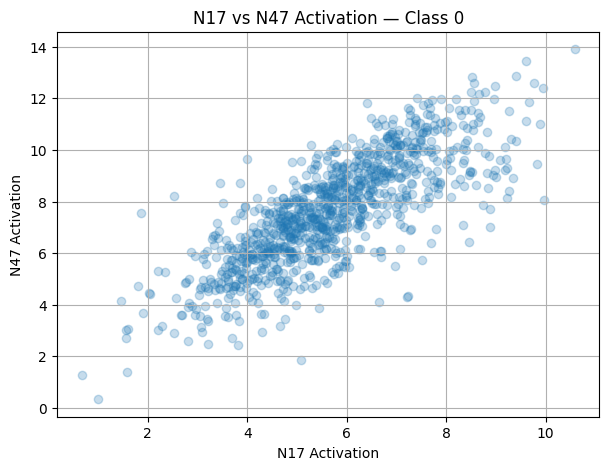

In [116]:
# ============================================================
# BLOCK 33 — N17 ve N47 Activation Correlation
# Amaç:
# N17 ve N47 neuronlarının activation (aktivasyon) değerlerinin
# birlikte değişip değişmediğini incelemek.
#
# Bu deney OBSERVATION (gözlem) aşamasıdır.
# Pearson correlation (Pearson korelasyonu) yüksek çıkarsa
# iki neuronun benzer/ilişkili bir internal representation
# (iç temsil) taşıdığı düşünülebilir.
#
# ÖNEMLİ:
# Korelasyon CAUSALITY (nedensellik) değildir.
# Nedensel katkıyı daha önceki ablation/intervention deneyleri
# ile değerlendiriyoruz.
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. ReLU2 activation değerlerini tekrar topluyoruz.
# Hook, modelin ilgili katmanının çıktısını yakalamamızı sağlar.
# ------------------------------------------------------------

activation_batches = []
label_batches = []

# relu2 katmanına forward hook (ileri geçiş kancası) ekliyoruz
def save_relu2_activation(module, input, output):
    activation_batches.append(output.detach().cpu())

hook_handle = model.relu2.register_forward_hook(save_relu2_activation)

# Modeli test verisi üzerinde çalıştırıyoruz.
# Burada sadece activation değerlerini gözlemliyoruz.
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # Forward pass (ileri geçiş)
        model(images)

        # Sınıf etiketlerini de saklıyoruz.
        label_batches.append(labels.cpu())

# Hook'u kaldırıyoruz.
hook_handle.remove()

# ------------------------------------------------------------
# 2. Activation matrix oluşturuyoruz.
#
# Her satır = bir test görüntüsü
# Her sütun = bir neuron
#
# Shape: [10000, 64]
# ------------------------------------------------------------

activation_matrix_33 = torch.cat(activation_batches, dim=0).numpy()
labels_array_33 = torch.cat(label_batches, dim=0).numpy()

print("Activation matrix shape:", activation_matrix_33.shape)

# ------------------------------------------------------------
# 3. N17 ve N47 activation değerlerini seçiyoruz.
# ------------------------------------------------------------

n17_activation = activation_matrix_33[:, 17]
n47_activation = activation_matrix_33[:, 47]

# ------------------------------------------------------------
# 4. Tüm test seti için Pearson correlation hesaplıyoruz.
# ------------------------------------------------------------

corr_all = np.corrcoef(n17_activation, n47_activation)[0, 1]

# ------------------------------------------------------------
# 5. Sadece Class 0 örnekleri için correlation hesaplıyoruz.
#
# Çünkü hem N17 hem N47'nin Class 0 davranışıyla ilişkisini
# daha önce intervention ile incelemiştik.
# ------------------------------------------------------------

class0_mask = labels_array_33 == 0

corr_class0 = np.corrcoef(
    n17_activation[class0_mask],
    n47_activation[class0_mask]
)[0, 1]

# ------------------------------------------------------------
# 6. Sonuçları yazdırıyoruz.
# ------------------------------------------------------------

print(f"N17 ↔ N47 correlation (all test data): {corr_all:.4f}")
print(f"N17 ↔ N47 correlation (Class 0 only): {corr_class0:.4f}")

# ------------------------------------------------------------
# 7. Class 0 örnekleri için scatter plot çiziyoruz.
#
# Her nokta:
# x = N17 activation
# y = N47 activation
#
# Noktalar yaklaşık düz bir çizgi etrafında toplanıyorsa
# iki activation arasında daha güçlü ilişki vardır.
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    n17_activation[class0_mask],
    n47_activation[class0_mask],
    alpha=0.25
)

plt.xlabel("N17 Activation")
plt.ylabel("N47 Activation")
plt.title("N17 vs N47 Activation — Class 0")

plt.grid(True)
plt.show()

In [117]:
# ============================================================
# BLOCK 34 — Class 0 Combined Ablation
#
# Amaç:
# N17 ve N47 neuronlarının Class 0 üzerindeki etkisini
# ayrı ayrı ve birlikte karşılaştırmak.
#
# Önce:
#   Normal
#   N17 ablation
#   N47 ablation
#
# Sonra:
#   N17 + N47 combined ablation
#
# Böylece iki neuronun birlikte çıkarılmasının etkisini
# ayrı ayrı çıkarılmalarının etkileriyle karşılaştıracağız.
#
# NOT:
# Bu deney interaction (etkileşim) hakkında evidence (kanıt)
# sağlayabilir; tek başına doğrudan "aynı circuit" kanıtı değildir.
# ============================================================

import torch

# ------------------------------------------------------------
# 1. Class-specific accuracy hesaplayan yardımcı fonksiyon.
# ------------------------------------------------------------

def class_accuracy_with_ablation(model, test_loader, device, neurons):
    """
    Belirtilen neuronları sıfırlayarak
    sadece Class 0 accuracy değerini hesaplar.
    """

    correct_class0 = 0
    total_class0 = 0

    # Ablation için hook ekliyoruz.
    def ablation_hook(module, input, output):
        output = output.clone()

        # Seçilen neuronların activation değerlerini sıfırla.
        output[:, neurons] = 0

        return output

    hook_handle = model.relu2.register_forward_hook(ablation_hook)

    model.eval()

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            # Sadece gerçek etiketi Class 0 olan örnekleri seç.
            class0_mask = labels == 0

            correct_class0 += (
                predictions[class0_mask] == labels[class0_mask]
            ).sum().item()

            total_class0 += class0_mask.sum().item()

    # Hook'u kaldır.
    hook_handle.remove()

    return 100 * correct_class0 / total_class0


# ------------------------------------------------------------
# 2. Baseline Class 0 accuracy
# ------------------------------------------------------------

baseline_class0 = class_accuracy_with_ablation(
    model,
    test_loader,
    device,
    []
)

# ------------------------------------------------------------
# 3. N17 tek başına ablation
# ------------------------------------------------------------

n17_class0 = class_accuracy_with_ablation(
    model,
    test_loader,
    device,
    [17]
)

# ------------------------------------------------------------
# 4. N47 tek başına ablation
# ------------------------------------------------------------

n47_class0 = class_accuracy_with_ablation(
    model,
    test_loader,
    device,
    [47]
)

# ------------------------------------------------------------
# 5. N17 + N47 birlikte ablation
# ------------------------------------------------------------

combined_class0 = class_accuracy_with_ablation(
    model,
    test_loader,
    device,
    [17, 47]
)

# ------------------------------------------------------------
# 6. Değişimleri baseline'a göre hesapla.
# ------------------------------------------------------------

n17_change = n17_class0 - baseline_class0
n47_change = n47_class0 - baseline_class0
combined_change = combined_class0 - baseline_class0

# Basit additive expectation (toplamsal beklenti):
# Eğer etkiler tamamen bağımsız ve yaklaşık toplamsal olsaydı,
# iki tekil etkinin toplamına yakın bir sonuç bekleyebilirdik.
expected_additive = n17_change + n47_change

interaction_difference = combined_change - expected_additive

# ------------------------------------------------------------
# 7. Sonuçları yazdır.
# ------------------------------------------------------------

print("===== CLASS 0 ABLATION RESULTS =====")

print(f"Baseline Class 0 accuracy : {baseline_class0:.4f}%")

print(f"N17 ablation              : {n17_class0:.4f}%")
print(f"N17 change                 : {n17_change:+.4f} pp")

print(f"N47 ablation              : {n47_class0:.4f}%")
print(f"N47 change                 : {n47_change:+.4f} pp")

print(f"N17 + N47 ablation       : {combined_class0:.4f}%")
print(f"Combined change            : {combined_change:+.4f} pp")

print()
print(f"Expected additive change  : {expected_additive:+.4f} pp")
print(f"Non-additive difference   : {interaction_difference:+.4f} pp")

===== CLASS 0 ABLATION RESULTS =====
Baseline Class 0 accuracy : 98.6735%
N17 ablation              : 97.8571%
N17 change                 : -0.8163 pp
N47 ablation              : 97.7551%
N47 change                 : -0.9184 pp
N17 + N47 ablation       : 95.9184%
Combined change            : -2.7551 pp

Expected additive change  : -1.7347 pp
Non-additive difference   : -1.0204 pp


In [118]:
# ============================================================
# BLOCK 35 — Activation Patching
#
# Amaç:
# Class 0 örneğindeki N17 ve N47 activation değerlerini
# Class 1 örneğine taşıyarak output (çıktı) üzerindeki etkisini
# ölçmek.
#
# Karşılaştırmalar:
#   1. Normal Class 1 örneği
#   2. Sadece N17 patch
#   3. Sadece N47 patch
#   4. N17 + N47 birlikte patch
#
# Activation Patching (aktivasyon yamalama), bir örneğin
# internal activation (iç aktivasyon) bilgisini başka bir
# örneğe taşıyarak bu bilginin davranış üzerindeki etkisini
# test eder.
#
# NOT:
# Bu sonuç güçlü causal evidence (nedensel kanıt) sağlayabilir,
# fakat tek başına "N17 ve N47 aynı feature'dır" sonucunu kanıtlamaz.
# ============================================================

import torch
import numpy as np

model.eval()

# ------------------------------------------------------------
# 1. Class 0 ve Class 1 için örnek buluyoruz.
#
# Class 0 source:
# Activation bilgisini buradan alacağız.
#
# Class 1 target:
# Activation bilgisini buraya aktaracağız.
# ------------------------------------------------------------

source_image = None
target_image = None

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        # Doğru sınıflandırılmış Class 0 örneği
        class0_indices = torch.where(
            (labels.to(device) == 0) &
            (predictions == 0)
        )[0]

        # Doğru sınıflandırılmış Class 1 örneği
        class1_indices = torch.where(
            (labels.to(device) == 1) &
            (predictions == 1)
        )[0]

        if len(class0_indices) > 0 and len(class1_indices) > 0:
            source_image = images[class0_indices[0]:class0_indices[0] + 1]
            target_image = images[class1_indices[0]:class1_indices[0] + 1]
            break

# ------------------------------------------------------------
# 2. Source Class 0 activation değerini yakalıyoruz.
# ------------------------------------------------------------

source_activation = None

def source_hook(module, input, output):
    global source_activation
    source_activation = output.detach().clone()

hook_source = model.relu2.register_forward_hook(source_hook)

with torch.no_grad():
    model(source_image)

hook_source.remove()

# ------------------------------------------------------------
# 3. Target Class 1'in normal activation değerlerini alıyoruz.
# ------------------------------------------------------------

target_activation = None

def target_hook(module, input, output):
    global target_activation
    target_activation = output.detach().clone()

hook_target = model.relu2.register_forward_hook(target_hook)

with torch.no_grad():
    target_output = model(target_image)

hook_target.remove()

# Normal Class 1 probability dağılımı
target_probability = torch.softmax(target_output, dim=1)

# ------------------------------------------------------------
# 4. Activation patching fonksiyonu.
#
# source activation:
# Class 0 örneğinden geliyor.
#
# target activation:
# Class 1 örneğinin normal activation'ı.
#
# selected_neurons:
# Hangi neuronları Class 0'dan Class 1'e taşıyacağımızı belirler.
# ------------------------------------------------------------

def run_patch(selected_neurons):

    def patch_hook(module, input, output):

        # Output'u değiştirmeden önce clone ediyoruz.
        patched_output = output.clone()

        # Seçilen neuronların Class 0 activation değerlerini
        # Class 1 örneğinin activation değerlerinin yerine koyuyoruz.
        patched_output[:, selected_neurons] = (
            source_activation[:, selected_neurons]
        )

        return patched_output

    hook = model.relu2.register_forward_hook(patch_hook)

    with torch.no_grad():
        patched_output = model(target_image)

    hook.remove()

    probability = torch.softmax(patched_output, dim=1)

    return patched_output, probability


# ------------------------------------------------------------
# 5. Sadece N17 patch
# ------------------------------------------------------------

output_n17, prob_n17 = run_patch([17])

# ------------------------------------------------------------
# 6. Sadece N47 patch
# ------------------------------------------------------------

output_n47, prob_n47 = run_patch([47])

# ------------------------------------------------------------
# 7. N17 + N47 birlikte patch
# ------------------------------------------------------------

output_both, prob_both = run_patch([17, 47])

# ------------------------------------------------------------
# 8. Class 0 probability değerlerini alıyoruz.
#
# Çünkü test ettiğimiz hypothesis:
#
# Class 0 internal information
#          ↓
#       N17 / N47
#          ↓
# Class 0 output behavior
# ------------------------------------------------------------

normal_class0_prob = target_probability[0, 0].item()
n17_class0_prob = prob_n17[0, 0].item()
n47_class0_prob = prob_n47[0, 0].item()
both_class0_prob = prob_both[0, 0].item()

# ------------------------------------------------------------
# 9. Sonuçları yazdırıyoruz.
# ------------------------------------------------------------

print("===== ACTIVATION PATCHING =====")

print("Source class : 0")
print("Target class : 1")
print()

print(f"Normal target Class 0 probability : {normal_class0_prob:.6f}")

print(f"N17 patched Class 0 probability   : {n17_class0_prob:.6f}")
print(
    f"N17 change                        : "
    f"{n17_class0_prob - normal_class0_prob:+.6f}"
)

print(f"N47 patched Class 0 probability   : {n47_class0_prob:.6f}")
print(
    f"N47 change                        : "
    f"{n47_class0_prob - normal_class0_prob:+.6f}"
)

print(
    f"N17 + N47 patched Class 0 probability : "
    f"{both_class0_prob:.6f}"
)

print(
    f"Combined change                    : "
    f"{both_class0_prob - normal_class0_prob:+.6f}"
)

# ------------------------------------------------------------
# 10. Hangi sınıfın seçildiğini de gösteriyoruz.
# ------------------------------------------------------------

print()
print(
    "Normal target prediction :",
    target_output.argmax(dim=1).item()
)

print(
    "N17 patched prediction   :",
    output_n17.argmax(dim=1).item()
)

print(
    "N47 patched prediction   :",
    output_n47.argmax(dim=1).item()
)

print(
    "Combined prediction     :",
    output_both.argmax(dim=1).item()
)

===== ACTIVATION PATCHING =====
Source class : 0
Target class : 1

Normal target Class 0 probability : 0.000002
N17 patched Class 0 probability   : 0.000010
N17 change                        : +0.000008
N47 patched Class 0 probability   : 0.000003
N47 change                        : +0.000001
N17 + N47 patched Class 0 probability : 0.000018
Combined change                    : +0.000016

Normal target prediction : 1
N17 patched prediction   : 1
N47 patched prediction   : 1
Combined prediction     : 1


In [119]:
# ============================================================
# BLOCK 36 — Multi-Sample Activation Patching
#
# Amaç:
# Tek bir örnekte yaptığımız activation patching deneyini
# çok sayıda Class 0 → Class 1 örneği üzerinde tekrarlamak.
#
# Böylece:
#   - N17 etkisi
#   - N47 etkisi
#   - N17 + N47 etkisi
#
# için ortalama Class 0 probability değişimini ölçeceğiz.
#
# Bu deney tek örneğe göre daha güvenilir bir evidence sağlar.
# ============================================================

import torch
import numpy as np

model.eval()

# ------------------------------------------------------------
# 1. Test setinden Class 0 ve Class 1 örneklerini topluyoruz.
# ------------------------------------------------------------

class0_images = []
class1_images = []

with torch.no_grad():
    for images, labels in test_loader:

        # CPU üzerinde tutuyoruz.
        for image, label in zip(images, labels):

            if label.item() == 0 and len(class0_images) < 50:
                class0_images.append(image.unsqueeze(0))

            elif label.item() == 1 and len(class1_images) < 50:
                class1_images.append(image.unsqueeze(0))

        # 50'şer örnek yeterli.
        if len(class0_images) >= 50 and len(class1_images) >= 50:
            break

print("Class 0 source samples:", len(class0_images))
print("Class 1 target samples:", len(class1_images))


# ------------------------------------------------------------
# 2. Activation yakalayan yardımcı fonksiyon.
# ------------------------------------------------------------

def get_relu2_activation(image):

    captured_activation = []

    def hook_fn(module, input, output):
        captured_activation.append(output.detach().clone())

    hook = model.relu2.register_forward_hook(hook_fn)

    with torch.no_grad():
        model(image.to(device))

    hook.remove()

    return captured_activation[0]


# ------------------------------------------------------------
# 3. Patch deneylerini gerçekleştireceğiz.
#
# Her Class 0 source activation'ı,
# bir Class 1 target örneğine aktarılacak.
# ------------------------------------------------------------

n17_changes = []
n47_changes = []
combined_changes = []

for i in range(50):

    # Source = Class 0
    source_image = class0_images[i].to(device)

    # Target = Class 1
    target_image = class1_images[i].to(device)

    # --------------------------------------------------------
    # Source Class 0 activation
    # --------------------------------------------------------

    source_activation = get_relu2_activation(source_image)

    # --------------------------------------------------------
    # Normal target output
    # --------------------------------------------------------

    with torch.no_grad():
        normal_output = model(target_image)

    normal_probability = torch.softmax(
        normal_output,
        dim=1
    )[0, 0].item()

    # --------------------------------------------------------
    # Patch fonksiyonu
    # --------------------------------------------------------

    def run_multi_patch(neurons):

        def patch_hook(module, input, output):

            patched = output.clone()

            patched[:, neurons] = (
                source_activation[:, neurons]
            )

            return patched

        hook = model.relu2.register_forward_hook(patch_hook)

        with torch.no_grad():
            patched_output = model(target_image)

        hook.remove()

        probability = torch.softmax(
            patched_output,
            dim=1
        )[0, 0].item()

        return probability

    # --------------------------------------------------------
    # N17
    # --------------------------------------------------------

    n17_probability = run_multi_patch([17])

    # --------------------------------------------------------
    # N47
    # --------------------------------------------------------

    n47_probability = run_multi_patch([47])

    # --------------------------------------------------------
    # N17 + N47
    # --------------------------------------------------------

    combined_probability = run_multi_patch([17, 47])

    # --------------------------------------------------------
    # Değişimleri kaydet
    # --------------------------------------------------------

    n17_changes.append(
        n17_probability - normal_probability
    )

    n47_changes.append(
        n47_probability - normal_probability
    )

    combined_changes.append(
        combined_probability - normal_probability
    )


# ------------------------------------------------------------
# 4. Ortalama patch etkilerini hesaplıyoruz.
# ------------------------------------------------------------

mean_n17 = np.mean(n17_changes)
mean_n47 = np.mean(n47_changes)
mean_combined = np.mean(combined_changes)

# Standart sapma:
# Etkinin örnekler arasında ne kadar değiştiğini gösterir.
std_n17 = np.std(n17_changes)
std_n47 = np.std(n47_changes)
std_combined = np.std(combined_changes)


# ------------------------------------------------------------
# 5. Sonuçları yazdır.
# ------------------------------------------------------------

print()
print("===== MULTI-SAMPLE ACTIVATION PATCHING =====")

print(
    f"N17 mean probability change      : "
    f"{mean_n17:+.8f}"
)

print(
    f"N17 standard deviation           : "
    f"{std_n17:.8f}"
)

print()

print(
    f"N47 mean probability change      : "
    f"{mean_n47:+.8f}"
)

print(
    f"N47 standard deviation           : "
    f"{std_n47:.8f}"
)

print()

print(
    f"N17 + N47 mean probability change: "
    f"{mean_combined:+.8f}"
)

print(
    f"N17 + N47 standard deviation     : "
    f"{std_combined:.8f}"
)

print()
print("Tested source → target pairs: 50")

Class 0 source samples: 50
Class 1 target samples: 50

===== MULTI-SAMPLE ACTIVATION PATCHING =====
N17 mean probability change      : +0.00000119
N17 standard deviation           : 0.00000396

N47 mean probability change      : +0.00000024
N47 standard deviation           : 0.00000072

N17 + N47 mean probability change: +0.00000247
N17 + N47 standard deviation     : 0.00000731

Tested source → target pairs: 50


In [120]:
# ============================================================
# BLOCK 37 — Distributed Feature Patching
#
# Amaç:
# Class 0 bilgisinin tek bir neuron yerine bir neuron grubu
# tarafından distributed representation (dağıtık temsil)
# şeklinde taşınıp taşınmadığını test etmek.
#
# Önce Class 0 selectivity (seçicilik) değeri en yüksek
# neuronları bulacağız.
#
# Sonra:
#   Class 0 source activation
#          ↓
#   seçilen neuron grubu
#          ↓
#   Class 1 target
#
# şeklinde activation patching yapacağız.
#
# Karşılaştırma:
#   Top 1 neuron
#   Top 3 neurons
#   Top 5 neurons
#
# Böylece neuron sayısı arttıkça Class 0 probability'nin
# sistematik olarak artıp artmadığını göreceğiz.
#
# NOT:
# Bu deney distributed representation için evidence sağlayabilir.
# Tek başına "bu neuronlar aynı feature'dır" kanıtı değildir.
# ============================================================

import torch
import numpy as np

model.eval()

# ------------------------------------------------------------
# 1. Class mean activation değerlerini hesaplıyoruz.
#
# activation_matrix_33:
# [10000, 64]
#
# Her neuron için Class 0 ortalama activation'ını bulacağız.
# ------------------------------------------------------------

class0_mask = labels_array_33 == 0

class0_mean = activation_matrix_33[class0_mask].mean(axis=0)

# Diğer sınıfların ortalama activation'larını hesaplıyoruz.
other_class_means = []

for class_id in range(1, 10):

    class_mask = labels_array_33 == class_id

    other_class_means.append(
        activation_matrix_33[class_mask].mean(axis=0)
    )

other_class_means = np.array(other_class_means)

# ------------------------------------------------------------
# 2. Class 0 selectivity hesaplıyoruz.
#
# Selectivity =
#
# Class 0 mean activation
# -
# diğer sınıflardaki en yüksek mean activation
#
# Değer yüksekse neuron Class 0'a daha seçici demektir.
# ------------------------------------------------------------

highest_other_class = other_class_means.max(axis=0)

class0_selectivity = class0_mean - highest_other_class

# En yüksek selectivity değerlerine sahip neuronları sıralıyoruz.
ranked_neurons = np.argsort(
    class0_selectivity
)[::-1]

# Top 5 neuron
top5_neurons = ranked_neurons[:5].tolist()

print("===== CLASS 0 SELECTIVE NEURONS =====")

for rank, neuron in enumerate(top5_neurons, start=1):

    print(
        f"Rank {rank}: "
        f"N{neuron} | "
        f"Selectivity = {class0_selectivity[neuron]:.4f}"
    )


# ------------------------------------------------------------
# 3. Test setinden 50 Class 0 source ve
#    50 Class 1 target örneği topluyoruz.
# ------------------------------------------------------------

class0_images = []
class1_images = []

with torch.no_grad():

    for images, labels in test_loader:

        for image, label in zip(images, labels):

            if label.item() == 0 and len(class0_images) < 50:
                class0_images.append(
                    image.unsqueeze(0)
                )

            elif label.item() == 1 and len(class1_images) < 50:
                class1_images.append(
                    image.unsqueeze(0)
                )

        if len(class0_images) >= 50 and len(class1_images) >= 50:
            break


# ------------------------------------------------------------
# 4. Activation yakalama fonksiyonu.
# ------------------------------------------------------------

def get_relu2_activation(image):

    captured_activation = []

    def hook_fn(module, input, output):

        captured_activation.append(
            output.detach().clone()
        )

    hook = model.relu2.register_forward_hook(
        hook_fn
    )

    with torch.no_grad():
        model(image.to(device))

    hook.remove()

    return captured_activation[0]


# ------------------------------------------------------------
# 5. Farklı neuron gruplarını test edeceğiz.
#
# Top 1
# Top 3
# Top 5
# ------------------------------------------------------------

neuron_groups = {

    "Top 1": top5_neurons[:1],

    "Top 3": top5_neurons[:3],

    "Top 5": top5_neurons[:5]
}

results = {}


# ------------------------------------------------------------
# 6. Her neuron grubu için 50 patch deneyi.
# ------------------------------------------------------------

for group_name, neurons in neuron_groups.items():

    changes = []

    for i in range(50):

        # --------------------------------------------
        # Source = Class 0
        # --------------------------------------------

        source_image = class0_images[i].to(device)

        # --------------------------------------------
        # Target = Class 1
        # --------------------------------------------

        target_image = class1_images[i].to(device)

        # --------------------------------------------
        # Source activation
        # --------------------------------------------

        source_activation = get_relu2_activation(
            source_image
        )

        # --------------------------------------------
        # Normal target probability
        # --------------------------------------------

        with torch.no_grad():

            normal_output = model(
                target_image
            )

        normal_probability = torch.softmax(
            normal_output,
            dim=1
        )[0, 0].item()

        # --------------------------------------------
        # Patch hook
        # --------------------------------------------

        def patch_hook(module, input, output):

            patched = output.clone()

            patched[:, neurons] = (
                source_activation[:, neurons]
            )

            return patched

        hook = model.relu2.register_forward_hook(
            patch_hook
        )

        # --------------------------------------------
        # Patched target
        # --------------------------------------------

        with torch.no_grad():

            patched_output = model(
                target_image
            )

        hook.remove()

        patched_probability = torch.softmax(
            patched_output,
            dim=1
        )[0, 0].item()

        # --------------------------------------------
        # Probability change
        # --------------------------------------------

        changes.append(
            patched_probability -
            normal_probability
        )

    # Sonuçları kaydet
    results[group_name] = {

        "mean": np.mean(changes),

        "std": np.std(changes)
    }


# ------------------------------------------------------------
# 7. Sonuçları yazdırıyoruz.
# ------------------------------------------------------------

print()
print("===== DISTRIBUTED FEATURE PATCHING =====")

for group_name, result in results.items():

    print(
        f"{group_name}: "
        f"mean change = "
        f"{result['mean']:+.8f} | "
        f"std = "
        f"{result['std']:.8f}"
    )

print()
print("Tested source → target pairs: 50")

===== CLASS 0 SELECTIVE NEURONS =====
Rank 1: N47 | Selectivity = 3.1630
Rank 2: N17 | Selectivity = 2.1927
Rank 3: N57 | Selectivity = 1.5183
Rank 4: N53 | Selectivity = 0.9431
Rank 5: N28 | Selectivity = 0.4163

===== DISTRIBUTED FEATURE PATCHING =====
Top 1: mean change = +0.00000024 | std = 0.00000072
Top 3: mean change = +0.00001863 | std = 0.00006229
Top 5: mean change = +0.00546138 | std = 0.02484783

Tested source → target pairs: 50


In [121]:
# ============================================================
# BLOCK 38 — Class-Specific Control Patching
#
# Amaç:
# Top 5 neuron grubunun etkisinin Class 0'a özgü olup
# olmadığını kontrol etmek.
#
# Source:
#   Class 0
#
# Target:
#   Class 1
#   Class 2
#
# Aynı Top 5 neuron grubunu iki farklı target sınıfına
# patch edeceğiz.
#
# Böylece Class 0 representation'ın etkisinin
# class-specific (sınıfa özgü) olup olmadığını inceleyeceğiz.
# ============================================================

import torch
import numpy as np

model.eval()

# ------------------------------------------------------------
# 1. Daha önce bulduğumuz Top 5 neuronları kullanıyoruz.
# ------------------------------------------------------------

top5_neurons = ranked_neurons[:5].tolist()

print("Top 5 neurons:", top5_neurons)


# ------------------------------------------------------------
# 2. Class 0 source örneklerini topluyoruz.
# ------------------------------------------------------------

class0_images = []
class1_images = []
class2_images = []

with torch.no_grad():

    for images, labels in test_loader:

        for image, label in zip(images, labels):

            label_value = label.item()

            if label_value == 0 and len(class0_images) < 30:

                class0_images.append(
                    image.unsqueeze(0)
                )

            elif label_value == 1 and len(class1_images) < 30:

                class1_images.append(
                    image.unsqueeze(0)
                )

            elif label_value == 2 and len(class2_images) < 30:

                class2_images.append(
                    image.unsqueeze(0)
                )

        if (
            len(class0_images) >= 30
            and len(class1_images) >= 30
            and len(class2_images) >= 30
        ):
            break


print("Class 0 source samples:", len(class0_images))
print("Class 1 target samples:", len(class1_images))
print("Class 2 target samples:", len(class2_images))


# ------------------------------------------------------------
# 3. ReLU2 activation yakalama fonksiyonu.
# ------------------------------------------------------------

def get_activation(image):

    captured = []

    def hook_fn(module, input, output):

        captured.append(
            output.detach().clone()
        )

    hook = model.relu2.register_forward_hook(
        hook_fn
    )

    with torch.no_grad():

        model(image.to(device))

    hook.remove()

    return captured[0]


# ------------------------------------------------------------
# 4. Bir target sınıfı için patch deneyini çalıştırıyoruz.
# ------------------------------------------------------------

def run_control_patching(target_images):

    probability_changes = []

    for i in range(30):

        # --------------------------------------------
        # Source = Class 0
        # --------------------------------------------

        source_image = class0_images[i].to(device)

        # --------------------------------------------
        # Target = verilen sınıf
        # --------------------------------------------

        target_image = target_images[i].to(device)

        # --------------------------------------------
        # Source activation
        # --------------------------------------------

        source_activation = get_activation(
            source_image
        )

        # --------------------------------------------
        # Normal target output
        # --------------------------------------------

        with torch.no_grad():

            normal_output = model(
                target_image
            )

        normal_probability = torch.softmax(
            normal_output,
            dim=1
        )[0, 0].item()

        # --------------------------------------------
        # Patch hook
        # --------------------------------------------

        def patch_hook(module, input, output):

            patched = output.clone()

            patched[:, top5_neurons] = (
                source_activation[:, top5_neurons]
            )

            return patched

        hook = model.relu2.register_forward_hook(
            patch_hook
        )

        # --------------------------------------------
        # Patched output
        # --------------------------------------------

        with torch.no_grad():

            patched_output = model(
                target_image
            )

        hook.remove()

        patched_probability = torch.softmax(
            patched_output,
            dim=1
        )[0, 0].item()

        # --------------------------------------------
        # Class 0 probability change
        # --------------------------------------------

        probability_changes.append(
            patched_probability -
            normal_probability
        )

    return (
        np.mean(probability_changes),
        np.std(probability_changes)
    )


# ------------------------------------------------------------
# 5. Class 1 target kontrolü
# ------------------------------------------------------------

class1_mean, class1_std = run_control_patching(
    class1_images
)


# ------------------------------------------------------------
# 6. Class 2 target kontrolü
# ------------------------------------------------------------

class2_mean, class2_std = run_control_patching(
    class2_images
)


# ------------------------------------------------------------
# 7. Sonuçlar
# ------------------------------------------------------------

print()
print("===== CLASS-SPECIFIC CONTROL PATCHING =====")

print(
    f"Class 1 target → "
    f"Class 0 probability change: "
    f"{class1_mean:+.8f} "
    f"(std={class1_std:.8f})"
)

print(
    f"Class 2 target → "
    f"Class 0 probability change: "
    f"{class2_mean:+.8f} "
    f"(std={class2_std:.8f})"
)

Top 5 neurons: [47, 17, 57, 53, 28]
Class 0 source samples: 30
Class 1 target samples: 30
Class 2 target samples: 30

===== CLASS-SPECIFIC CONTROL PATCHING =====
Class 1 target → Class 0 probability change: +0.00887395 (std=0.03161188)
Class 2 target → Class 0 probability change: +0.00536434 (std=0.02391533)


In [122]:
# ============================================================
# BLOCK 39 — Logit-Level Activation Patching
#
# Amaç:
# Önceki patching deneylerini probability yerine
# Class 0 LOGIT (logit değeri) üzerinden incelemek.
#
# Logit, Softmax'tan önceki ham output değeridir.
#
# Böylece:
#
# Activation
#      ↓
# Output weights
#      ↓
# Class 0 logit
#      ↓
# Softmax probability
#
# zincirinin daha doğrudan bir bölümünü ölçmüş olacağız.
#
# Top 5 neuron:
# [47, 17, 57, 53, 28]
# ============================================================

import torch
import numpy as np

model.eval()

# ------------------------------------------------------------
# 1. Top 5 neuron grubunu belirliyoruz.
# ------------------------------------------------------------

top5_neurons = [47, 17, 57, 53, 28]

print("Testing neurons:", top5_neurons)


# ------------------------------------------------------------
# 2. Class 0, Class 1 ve Class 2 örneklerini topluyoruz.
# ------------------------------------------------------------

class0_images = []
class1_images = []
class2_images = []

with torch.no_grad():

    for images, labels in test_loader:

        for image, label in zip(images, labels):

            label_value = label.item()

            if label_value == 0 and len(class0_images) < 30:

                class0_images.append(
                    image.unsqueeze(0)
                )

            elif label_value == 1 and len(class1_images) < 30:

                class1_images.append(
                    image.unsqueeze(0)
                )

            elif label_value == 2 and len(class2_images) < 30:

                class2_images.append(
                    image.unsqueeze(0)
                )

        if (
            len(class0_images) >= 30
            and len(class1_images) >= 30
            and len(class2_images) >= 30
        ):
            break


# ------------------------------------------------------------
# 3. ReLU2 activation yakalama fonksiyonu.
# ------------------------------------------------------------

def get_activation(image):

    captured = []

    def hook_fn(module, input, output):

        captured.append(
            output.detach().clone()
        )

    hook = model.relu2.register_forward_hook(
        hook_fn
    )

    with torch.no_grad():

        model(image.to(device))

    hook.remove()

    return captured[0]


# ------------------------------------------------------------
# 4. Bir target grubunda logit değişimini ölçüyoruz.
# ------------------------------------------------------------

def measure_logit_change(target_images):

    logit_changes = []

    for i in range(30):

        # --------------------------------------------
        # Class 0 source
        # --------------------------------------------

        source_image = class0_images[i].to(device)

        # --------------------------------------------
        # Target image
        # --------------------------------------------

        target_image = target_images[i].to(device)

        # --------------------------------------------
        # Source activation
        # --------------------------------------------

        source_activation = get_activation(
            source_image
        )

        # --------------------------------------------
        # Normal target output
        # --------------------------------------------

        with torch.no_grad():

            normal_output = model(
                target_image
            )

        normal_class0_logit = (
            normal_output[0, 0].item()
        )

        # --------------------------------------------
        # Activation patch
        # --------------------------------------------

        def patch_hook(module, input, output):

            patched = output.clone()

            patched[:, top5_neurons] = (
                source_activation[:, top5_neurons]
            )

            return patched

        hook = model.relu2.register_forward_hook(
            patch_hook
        )

        # --------------------------------------------
        # Patched output
        # --------------------------------------------

        with torch.no_grad():

            patched_output = model(
                target_image
            )

        hook.remove()

        patched_class0_logit = (
            patched_output[0, 0].item()
        )

        # --------------------------------------------
        # Logit change
        # --------------------------------------------

        logit_changes.append(
            patched_class0_logit -
            normal_class0_logit
        )

    return (
        np.mean(logit_changes),
        np.std(logit_changes)
    )


# ------------------------------------------------------------
# 5. Class 1 target
# ------------------------------------------------------------

class1_mean, class1_std = measure_logit_change(
    class1_images
)


# ------------------------------------------------------------
# 6. Class 2 target
# ------------------------------------------------------------

class2_mean, class2_std = measure_logit_change(
    class2_images
)


# ------------------------------------------------------------
# 7. Sonuçları yazdırıyoruz.
# ------------------------------------------------------------

print()
print("===== LOGIT-LEVEL PATCHING =====")

print(
    f"Class 1 target → "
    f"Class 0 logit change: "
    f"{class1_mean:+.6f} "
    f"(std={class1_std:.6f})"
)

print(
    f"Class 2 target → "
    f"Class 0 logit change: "
    f"{class2_mean:+.6f} "
    f"(std={class2_std:.6f})"
)

Testing neurons: [47, 17, 57, 53, 28]

===== LOGIT-LEVEL PATCHING =====
Class 1 target → Class 0 logit change: +6.024506 (std=1.621096)
Class 2 target → Class 0 logit change: +4.306821 (std=1.859204)


In [123]:
# ============================================================
# BLOCK 40 — Candidate Circuit Output Weights
#
# Amaç:
# Candidate neuron grubunun Class 0 output logit'ine
# hangi ağırlıklarla bağlandığını incelemek.
#
# Candidate neurons:
# N47, N17, N57, N53, N28
#
# Son katman:
# fc3.weight
#
# Class 0 için:
# fc3.weight[0, neuron]
#
# Böylece:
#
# Activation × Output Weight
#
# ilişkisinin mekanik yapısını doğrudan göreceğiz.
# ============================================================

import torch

# ------------------------------------------------------------
# 1. Candidate neuron grubunu tanımlıyoruz.
# ------------------------------------------------------------

candidate_neurons = [47, 17, 57, 53, 28]

# ------------------------------------------------------------
# 2. fc3 output layer ağırlıklarını alıyoruz.
#
# fc3.weight shape:
# [10, 64]
#
# 10 = output classes
# 64 = ReLU2 neurons
# ------------------------------------------------------------

output_weights = model.fc3.weight.detach().cpu()

# ------------------------------------------------------------
# 3. Class 0 için candidate neuron ağırlıklarını çıkarıyoruz.
# ------------------------------------------------------------

class0_weights = output_weights[
    0,
    candidate_neurons
]

print("===== CANDIDATE CIRCUIT → CLASS 0 =====")

for neuron, weight in zip(
    candidate_neurons,
    class0_weights
):

    print(
        f"N{neuron} → Class 0 weight: "
        f"{weight.item():+.6f}"
    )

# ------------------------------------------------------------
# 4. Candidate grubunun toplam mutlak ağırlık katkısını
#    hesaplıyoruz.
#
# Bu değer sadece ağırlık büyüklüğünü gösterir.
# Tek başına causal importance değildir.
# ------------------------------------------------------------

absolute_weight_sum = (
    class0_weights.abs().sum().item()
)

signed_weight_sum = (
    class0_weights.sum().item()
)

print()
print(
    f"Absolute weight sum: "
    f"{absolute_weight_sum:.6f}"
)

print(
    f"Signed weight sum: "
    f"{signed_weight_sum:+.6f}"
)

# ------------------------------------------------------------
# 5. Her neuronun Class 0'a göre katkısının yanında
#    diğer output class'lara olan ağırlıklarını da gösteriyoruz.
#
# Böylece candidate neuronların Class 0'a özgü mü,
# yoksa birden fazla output class'a mı bağlandığını görebiliriz.
# ------------------------------------------------------------

print()
print("===== OUTPUT WEIGHTS OF CANDIDATE NEURONS =====")

for neuron in candidate_neurons:

    weights = output_weights[:, neuron]

    print()
    print(f"N{neuron}:")

    for class_id, weight in enumerate(weights):

        print(
            f"  Class {class_id}: "
            f"{weight.item():+.6f}"
        )

===== CANDIDATE CIRCUIT → CLASS 0 =====
N47 → Class 0 weight: +0.231610
N17 → Class 0 weight: +0.237246
N57 → Class 0 weight: +0.186438
N53 → Class 0 weight: +0.225550
N28 → Class 0 weight: +0.233466

Absolute weight sum: 1.114311
Signed weight sum: +1.114311

===== OUTPUT WEIGHTS OF CANDIDATE NEURONS =====

N47:
  Class 0: +0.231610
  Class 1: +0.109971
  Class 2: +0.178919
  Class 3: -0.267513
  Class 4: -0.161674
  Class 5: -0.186801
  Class 6: +0.099716
  Class 7: -0.022909
  Class 8: -0.050311
  Class 9: -0.183489

N17:
  Class 0: +0.237246
  Class 1: -0.076605
  Class 2: -0.176850
  Class 3: -0.170151
  Class 4: +0.209401
  Class 5: -0.231232
  Class 6: -0.024937
  Class 7: -0.135016
  Class 8: -0.107016
  Class 9: +0.121598

N57:
  Class 0: +0.186438
  Class 1: -0.183195
  Class 2: +0.145547
  Class 3: -0.089998
  Class 4: -0.045267
  Class 5: +0.032333
  Class 6: -0.052765
  Class 7: +0.133673
  Class 8: +0.006379
  Class 9: -0.101429

N53:
  Class 0: +0.225550
  Class 1: -0.17

In [124]:
# ============================================================
# BLOCK 41 — Neuron → Class 0 Logit Contribution
#
# Amaç:
# Candidate neuronların Class 0 logit'ine gerçek katkısını
# activation × output weight üzerinden hesaplamak.
#
# Formül:
#
# contribution_i = activation_i × weight_i
#
# Class 0 logit:
#
# z_0 = Σ(a_i × w_0i) + b_0
#
# Burada sadece candidate neuron grubunun katkısını
# ayrı olarak inceleyeceğiz.
#
# NOT:
# Bu değer doğrudan "causal importance" değildir.
# Mekanik contribution (hesaplama katkısı) gösterir.
# ============================================================

import torch
import numpy as np

model.eval()

# ------------------------------------------------------------
# 1. Candidate neuron grubumuz.
# ------------------------------------------------------------

candidate_neurons = [47, 17, 57, 53, 28]

# ------------------------------------------------------------
# 2. Class 0 output weights.
# ------------------------------------------------------------

class0_weights = (
    model.fc3.weight[0, candidate_neurons]
    .detach()
    .cpu()
    .numpy()
)

print("===== CLASS 0 LOGIT CONTRIBUTION =====")

# ------------------------------------------------------------
# 3. Class 0 test örneklerini topluyoruz.
# ------------------------------------------------------------

class0_images = []

with torch.no_grad():

    for images, labels in test_loader:

        for image, label in zip(images, labels):

            if label.item() == 0:

                class0_images.append(
                    image.unsqueeze(0)
                )

            if len(class0_images) >= 100:
                break

        if len(class0_images) >= 100:
            break


print(
    "Class 0 samples:",
    len(class0_images)
)

# ------------------------------------------------------------
# 4. Activation'ları topluyoruz.
# ------------------------------------------------------------

activation_batches = []

def activation_hook(module, input, output):

    activation_batches.append(
        output.detach().cpu()
    )

hook = model.relu2.register_forward_hook(
    activation_hook
)

with torch.no_grad():

    for image in class0_images:

        model(
            image.to(device)
        )

hook.remove()

# ------------------------------------------------------------
# 5. Activation matrix.
#
# Shape:
# [100, 64]
# ------------------------------------------------------------

class0_activations = torch.cat(
    activation_batches,
    dim=0
).numpy()

# ------------------------------------------------------------
# 6. Candidate neuron activation'larını seçiyoruz.
# ------------------------------------------------------------

candidate_activations = (
    class0_activations[:, candidate_neurons]
)

# ------------------------------------------------------------
# 7. Activation × weight
#
# Her örnek ve her neuron için:
#
# contribution = activation × Class 0 weight
# ------------------------------------------------------------

contributions = (
    candidate_activations *
    class0_weights
)

# ------------------------------------------------------------
# 8. Ortalama contribution hesaplıyoruz.
# ------------------------------------------------------------

mean_contributions = (
    contributions.mean(axis=0)
)

# ------------------------------------------------------------
# 9. Sonuçları yazdırıyoruz.
# ------------------------------------------------------------

for neuron, weight, mean_activation, contribution in zip(
    candidate_neurons,
    class0_weights,
    candidate_activations.mean(axis=0),
    mean_contributions
):

    print(
        f"N{neuron}: "
        f"mean activation = {mean_activation:.4f} | "
        f"weight = {weight:+.6f} | "
        f"mean Class 0 contribution = {contribution:+.6f}"
    )

# ------------------------------------------------------------
# 10. Candidate grubunun toplam contribution'ı.
# ------------------------------------------------------------

total_contribution = (
    mean_contributions.sum()
)

print()
print(
    f"Total candidate contribution "
    f"to Class 0 logit = "
    f"{total_contribution:+.6f}"
)

===== CLASS 0 LOGIT CONTRIBUTION =====
Class 0 samples: 100
N47: mean activation = 7.1442 | weight = +0.231610 | mean Class 0 contribution = +1.654675
N17: mean activation = 5.1893 | weight = +0.237246 | mean Class 0 contribution = +1.231128
N57: mean activation = 4.3655 | weight = +0.186438 | mean Class 0 contribution = +0.813899
N53: mean activation = 5.7294 | weight = +0.225550 | mean Class 0 contribution = +1.292274
N28: mean activation = 5.1635 | weight = +0.233466 | mean Class 0 contribution = +1.205509

Total candidate contribution to Class 0 logit = +6.197485


In [125]:
# ============================================================
# BLOCK 42 — Candidate Group Contribution Across Classes
#
# Amaç:
# Class 0 için seçtiğimiz candidate neuron grubunun
# farklı sınıflardaki Class 0 logit contribution'ını karşılaştırmak.
#
# Formül:
#
# contribution = activation × Class 0 output weight
#
# Karşılaştıracağımız sınıflar:
# Class 0, Class 1, Class 2
#
# Böylece candidate grubun:
# - Class 0'a özgü mü?
# - Yoksa farklı sınıflarda da Class 0 logit'ini destekliyor mu?
# olduğunu gözlemleyeceğiz.
#
# NOT:
# Bu analiz computational contribution (hesaplama katkısı) gösterir.
# Tek başına causal importance (nedensel önem) kanıtlamaz.
# ============================================================

import torch
import numpy as np

model.eval()

# Class 0 için daha önce belirlediğimiz candidate neuron grubu
candidate_neurons = [47, 17, 57, 53, 28]

# Bu neuronların Class 0 output weight değerlerini alıyoruz.
class0_weights = (
    model.fc3.weight[0, candidate_neurons]
    .detach()
    .cpu()
    .numpy()
)

# İnceleyeceğimiz sınıflar
target_classes = [0, 1, 2]

print("===== CANDIDATE GROUP CONTRIBUTION ACROSS CLASSES =====")

for target_class in target_classes:

    # Bu sınıfa ait 100 örnek topluyoruz.
    class_images = []

    with torch.no_grad():
        for images, labels in test_loader:
            for image, label in zip(images, labels):

                if label.item() == target_class:
                    class_images.append(image.unsqueeze(0))

                if len(class_images) >= 100:
                    break

            if len(class_images) >= 100:
                break

    # ReLU2 aktivasyonlarını toplamak için hook oluşturuyoruz.
    activation_batches = []

    def activation_hook(module, input, output):
        activation_batches.append(output.detach().cpu())

    hook = model.relu2.register_forward_hook(activation_hook)

    # Örnekleri modelden geçiriyoruz.
    with torch.no_grad():
        for image in class_images:
            model(image.to(device))

    # Hook'u kaldırıyoruz.
    hook.remove()

    # Aktivasyonları tek matrise çeviriyoruz.
    activations = torch.cat(
        activation_batches,
        dim=0
    ).numpy()

    # Sadece candidate neuronların aktivasyonlarını alıyoruz.
    candidate_activations = activations[:, candidate_neurons]

    # Class 0 logit contribution:
    # activation × Class 0 output weight
    contributions = (
        candidate_activations *
        class0_weights
    )

    # Her neuronun ortalama contribution'ı
    mean_contributions = contributions.mean(axis=0)

    # Candidate grubun toplam ortalama contribution'ı
    total_contribution = mean_contributions.sum()

    print()
    print(f"--- True Class {target_class} ---")

    for neuron, contribution in zip(
        candidate_neurons,
        mean_contributions
    ):
        print(
            f"N{neuron}: "
            f"mean Class 0 contribution = "
            f"{contribution:+.6f}"
        )

    print(
        f"TOTAL candidate contribution "
        f"to Class 0 logit = "
        f"{total_contribution:+.6f}"
    )

===== CANDIDATE GROUP CONTRIBUTION ACROSS CLASSES =====

--- True Class 0 ---
N47: mean Class 0 contribution = +1.654675
N17: mean Class 0 contribution = +1.231128
N57: mean Class 0 contribution = +0.813899
N53: mean Class 0 contribution = +1.292274
N28: mean Class 0 contribution = +1.205509
TOTAL candidate contribution to Class 0 logit = +6.197485

--- True Class 1 ---
N47: mean Class 0 contribution = +0.457392
N17: mean Class 0 contribution = +0.105148
N57: mean Class 0 contribution = +0.009703
N53: mean Class 0 contribution = +0.144702
N28: mean Class 0 contribution = +0.019834
TOTAL candidate contribution to Class 0 logit = +0.736779

--- True Class 2 ---
N47: mean Class 0 contribution = +1.072207
N17: mean Class 0 contribution = +0.093729
N57: mean Class 0 contribution = +0.581162
N53: mean Class 0 contribution = +0.291695
N28: mean Class 0 contribution = +0.393925
TOTAL candidate contribution to Class 0 logit = +2.432718


In [126]:
# ============================================================
# BLOCK 43 — Candidate Group Contribution to All Output Classes
#
# Amaç:
# Class 0 için seçtiğimiz candidate neuron grubunun
# 10 output class'ının logit'lerine nasıl katkı yaptığını
# karşılaştırmak.
#
# Formül:
#
# contribution = activation × output weight
#
# Böylece candidate grubun:
# - Class 0'ı destekleyip desteklemediğini
# - Diğer class'ları da destekleyip desteklemediğini
# - Bazı class'ları bastırıp bastırmadığını
# inceleyeceğiz.
#
# NOT:
# Bu computational contribution (hesaplama katkısıdır).
# Tek başına causal importance (nedensel önem) kanıtı değildir.
# ============================================================

import torch
import numpy as np

model.eval()

# Daha önce belirlediğimiz Class 0 candidate neuron grubu
candidate_neurons = [47, 17, 57, 53, 28]

# Output layer'daki tüm class'lara ait ağırlıkları alıyoruz.
# Shape:
# [10 classes, 5 candidate neurons]
output_weights = (
    model.fc3.weight[:, candidate_neurons]
    .detach()
    .cpu()
    .numpy()
)

# Karşılaştıracağımız gerçek sınıflar
target_classes = [0, 1, 2]

print("===== CANDIDATE GROUP → ALL OUTPUT CLASSES =====")

for target_class in target_classes:

    # --------------------------------------------------------
    # Bu sınıfa ait 100 test örneği topluyoruz.
    # --------------------------------------------------------

    class_images = []

    with torch.no_grad():
        for images, labels in test_loader:

            for image, label in zip(images, labels):

                if label.item() == target_class:
                    class_images.append(image.unsqueeze(0))

                if len(class_images) >= 100:
                    break

            if len(class_images) >= 100:
                break

    # --------------------------------------------------------
    # Candidate neuronların aktivasyonlarını topluyoruz.
    # --------------------------------------------------------

    activation_batches = []

    def activation_hook(module, input, output):
        activation_batches.append(output.detach().cpu())

    hook = model.relu2.register_forward_hook(activation_hook)

    with torch.no_grad():
        for image in class_images:
            model(image.to(device))

    hook.remove()

    # [100, 64]
    activations = torch.cat(
        activation_batches,
        dim=0
    ).numpy()

    # Sadece candidate neuronlar
    # [100, 5]
    candidate_activations = (
        activations[:, candidate_neurons]
    )

    # --------------------------------------------------------
    # Her candidate neuronun her output class'a contribution'ı
    #
    # [100,5] × [10,5]
    # Her örnek için 5 neuronun 10 class'a katkısını hesaplıyoruz.
    # --------------------------------------------------------

    class_contributions = np.zeros((10, 5))

    for class_id in range(10):

        contributions = (
            candidate_activations *
            output_weights[class_id]
        )

        class_contributions[class_id] = (
            contributions.mean(axis=0)
        )

    # --------------------------------------------------------
    # Candidate grubunun her output class'a toplam contribution'ı
    # --------------------------------------------------------

    total_contributions = (
        class_contributions.sum(axis=1)
    )

    print()
    print(f"--- True Class {target_class} ---")

    for class_id in range(10):

        print(
            f"Output Class {class_id}: "
            f"{total_contributions[class_id]:+.6f}"
        )

    # En güçlü desteklenen ve bastırılan class'ları gösteriyoruz.
    strongest_class = np.argmax(total_contributions)
    weakest_class = np.argmin(total_contributions)

    print()
    print(
        f"Strongest positive contribution: "
        f"Class {strongest_class} "
        f"({total_contributions[strongest_class]:+.6f})"
    )

    print(
        f"Strongest negative contribution: "
        f"Class {weakest_class} "
        f"({total_contributions[weakest_class]:+.6f})"
    )

===== CANDIDATE GROUP → ALL OUTPUT CLASSES =====

--- True Class 0 ---
Output Class 0: +6.197485
Output Class 1: -2.253895
Output Class 2: +0.218861
Output Class 3: -3.120183
Output Class 4: -3.548902
Output Class 5: -1.585979
Output Class 6: +0.040571
Output Class 7: +0.004093
Output Class 8: -0.406147
Output Class 9: -0.499234

Strongest positive contribution: Class 0 (+6.197485)
Strongest negative contribution: Class 4 (-3.548902)

--- True Class 1 ---
Output Class 0: +0.736779
Output Class 1: +0.047394
Output Class 2: +0.186111
Output Class 3: -0.569736
Output Class 4: -0.423243
Output Class 5: -0.438194
Output Class 6: +0.187347
Output Class 7: -0.031152
Output Class 8: -0.157257
Output Class 9: -0.241223

Strongest positive contribution: Class 0 (+0.736779)
Strongest negative contribution: Class 3 (-0.569736)

--- True Class 2 ---
Output Class 0: +2.432718
Output Class 1: -0.592691
Output Class 2: +1.046666
Output Class 3: -1.604063
Output Class 4: -1.731053
Output Class 5: -0.61

In [127]:
# ============================================================
# BLOCK 44 — Candidate Circuit Ablation
#
# Amaç:
# N47, N17, N57, N53 ve N28 candidate grubunu birlikte
# ablate (sıfırlayarak devre dışı bırakmak).
#
# Sonra özellikle Class 0 davranışındaki değişimi ölçmek.
#
# Karşılaştırma:
#
# Normal model
#      ↓
# Class 0 accuracy
#
# Candidate circuit ablated
#      ↓
# Class 0 accuracy
#
# NOT:
# Bu deney candidate grubunun Class 0 davranışına
# katkısını test eder.
# Tek başına "circuit kesin doğrulandı" anlamına gelmez.
# ============================================================

import torch
import numpy as np

model.eval()

# Candidate neuron grubumuz
candidate_neurons = [47, 17, 57, 53, 28]


# ------------------------------------------------------------
# Class 0 accuracy hesaplayan yardımcı fonksiyon
# ------------------------------------------------------------

def get_class_accuracy(model, data_loader, target_class):

    correct = 0
    total = 0

    model.eval()

    with torch.no_grad():

        for images, labels in data_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            mask = labels == target_class

            correct += (
                (predictions[mask] == target_class)
                .sum()
                .item()
            )

            total += mask.sum().item()

    return 100 * correct / total


# ------------------------------------------------------------
# Candidate neuronları ablate eden forward hook
# ------------------------------------------------------------

def candidate_ablation_hook(module, input, output):

    # Activation tensorunu kopyalıyoruz.
    modified_output = output.clone()

    # Candidate neuronların aktivasyonunu sıfırlıyoruz.
    modified_output[:, candidate_neurons] = 0.0

    return modified_output


# ------------------------------------------------------------
# 1. Normal model
# ------------------------------------------------------------

baseline_class0_accuracy = get_class_accuracy(
    model,
    test_loader,
    target_class=0
)

print("===== CANDIDATE CIRCUIT ABLATION =====")

print(
    f"Baseline Class 0 accuracy: "
    f"{baseline_class0_accuracy:.4f}%"
)


# ------------------------------------------------------------
# 2. Candidate grubunu ablate ediyoruz
# ------------------------------------------------------------

hook = model.relu2.register_forward_hook(
    candidate_ablation_hook
)

ablated_class0_accuracy = get_class_accuracy(
    model,
    test_loader,
    target_class=0
)

hook.remove()


# ------------------------------------------------------------
# 3. Değişimi hesaplıyoruz
# ------------------------------------------------------------

accuracy_change = (
    ablated_class0_accuracy
    - baseline_class0_accuracy
)


print(
    f"Ablated Class 0 accuracy: "
    f"{ablated_class0_accuracy:.4f}%"
)

print(
    f"Class 0 accuracy change: "
    f"{accuracy_change:+.4f} percentage points"
)

===== CANDIDATE CIRCUIT ABLATION =====
Baseline Class 0 accuracy: 98.6735%
Ablated Class 0 accuracy: 86.6327%
Class 0 accuracy change: -12.0408 percentage points


In [128]:
# ============================================================
# BLOCK 45 — Candidate Circuit Ablation: Class 1 ve Class 2
# ============================================================
# Amaç:
# Block 44'te güçlü etki gösteren aday devrenin
# (N47, N17, N57, N53, N28) sadece Class 0 davranışını mı
# etkilediğini, yoksa modelin diğer sınıflarını da genel olarak
# etkileyip etkilemediğini test etmek.
#
# Ablation (ablasyon):
# Seçilen nöronların activation (aktivasyon) değerlerini 0 yapıyoruz.
#
# Böylece:
# Normal model → Ablation → Class-specific accuracy değişimi
# karşılaştırılacak.

candidate_neurons = [47, 17, 57, 53, 28]

# ------------------------------------------------------------
# Candidate circuit'i ablate eden hook
# ------------------------------------------------------------
def circuit_ablation_hook(module, inputs, output):
    # output, ReLU2 katmanından gelen activation matrisidir.
    # Boyut: [batch_size, 64]
    output = output.clone()

    # Aday devreyi oluşturan nöronların activation değerlerini
    # 0 yapıyoruz.
    output[:, candidate_neurons] = 0.0

    return output


# ------------------------------------------------------------
# Belirli bir class için accuracy hesaplayan fonksiyon
# ------------------------------------------------------------
def class_accuracy_with_circuit_ablation(target_class):

    correct_normal = 0
    total = 0

    correct_ablated = 0

    # Normal model çıktısını hesaplıyoruz.
    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Sadece hedef class'a ait örnekleri seçiyoruz.
            mask = labels == target_class

            if mask.sum() == 0:
                continue

            images_class = images[mask]
            labels_class = labels[mask]

            # -------------------------
            # Normal model
            # -------------------------
            logits_normal = model(images_class)

            predictions_normal = torch.argmax(
                logits_normal,
                dim=1
            )

            correct_normal += (
                predictions_normal == labels_class
            ).sum().item()

            total += labels_class.size(0)

    # Normal accuracy
    normal_accuracy = 100 * correct_normal / total

    # --------------------------------------------------------
    # Candidate circuit ablation hook'unu ekliyoruz.
    # --------------------------------------------------------
    handle = model.relu2.register_forward_hook(
        circuit_ablation_hook
    )

    try:

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Yalnızca hedef class
                mask = labels == target_class

                if mask.sum() == 0:
                    continue

                images_class = images[mask]
                labels_class = labels[mask]

                # Aday devre ablation uygulanmış model
                logits_ablated = model(images_class)

                predictions_ablated = torch.argmax(
                    logits_ablated,
                    dim=1
                )

                correct_ablated += (
                    predictions_ablated == labels_class
                ).sum().item()

    finally:
        # Hook'u mutlaka kaldırıyoruz.
        # Böylece sonraki deneyler etkilenmez.
        handle.remove()

    # Ablation sonrası accuracy
    ablated_accuracy = 100 * correct_ablated / total

    change = ablated_accuracy - normal_accuracy

    return normal_accuracy, ablated_accuracy, change


# ------------------------------------------------------------
# Class 1 ve Class 2 testleri
# ------------------------------------------------------------

for target_class in [1, 2]:

    normal_acc, ablated_acc, change = (
        class_accuracy_with_circuit_ablation(target_class)
    )

    print(f"\nClass {target_class}")
    print(f"Normal accuracy : {normal_acc:.4f}%")
    print(f"Ablated accuracy: {ablated_acc:.4f}%")
    print(f"Change          : {change:+.4f} pp")


Class 1
Normal accuracy : 99.3833%
Ablated accuracy: 99.4714%
Change          : +0.0881 pp

Class 2
Normal accuracy : 97.1899%
Ablated accuracy: 97.1899%
Change          : +0.0000 pp


In [129]:
# ============================================================
# BLOCK 46 — Leave-One-Out Ablation
# ============================================================
# Amaç:
# Candidate circuit = [N47, N17, N57, N53, N28]
#
# Bu deneyde her seferinde yalnızca 1 nöronu devreden çıkaracağız.
# Diğer 4 nöron çalışmaya devam edecek.
#
# Böylece şu soruyu test ediyoruz:
# "Bu 5 nörondan hangisi Class 0 davranışı için daha kritik?"
#
# Leave-One-Out Ablation (tek tek çıkararak ablasyon):
# Bir gruptan yalnızca bir elemanı çıkarıp sistemin davranışını
# karşılaştırma yöntemidir.

candidate_neurons = [47, 17, 57, 53, 28]


# ------------------------------------------------------------
# Class 0 accuracy hesaplayan fonksiyon
# ------------------------------------------------------------
def class0_accuracy_with_selected_ablation(ablation_neurons):

    correct = 0
    total = 0

    # Ablation hook'u:
    # Seçilen nöronların activation değerlerini 0 yapıyoruz.
    def ablation_hook(module, inputs, output):

        output = output.clone()

        # Seçilen nöronları devre dışı bırak.
        output[:, ablation_neurons] = 0.0

        return output

    # Hook'u ReLU2 katmanına bağlıyoruz.
    handle = model.relu2.register_forward_hook(ablation_hook)

    try:

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Yalnızca Class 0 örneklerini seçiyoruz.
                mask = labels == 0

                if mask.sum() == 0:
                    continue

                images_class = images[mask]
                labels_class = labels[mask]

                # Ablation uygulanmış model çıktısı.
                logits = model(images_class)

                # En yüksek logit hangi class ise modelin tahmini odur.
                predictions = torch.argmax(logits, dim=1)

                correct += (
                    predictions == labels_class
                ).sum().item()

                total += labels_class.size(0)

    finally:

        # Hook'u kaldırıyoruz.
        # Böylece sonraki deneyler temiz model üzerinden çalışır.
        handle.remove()

    return 100 * correct / total


# ------------------------------------------------------------
# Önce normal Class 0 accuracy
# ------------------------------------------------------------
baseline_class0_accuracy = class0_accuracy_with_selected_ablation([])

print("Baseline Class 0 accuracy:")
print(f"{baseline_class0_accuracy:.4f}%")

print("\nLeave-One-Out Ablation Results")
print("-" * 55)


# ------------------------------------------------------------
# Her nöronu tek tek çıkarıyoruz.
# ------------------------------------------------------------
for neuron in candidate_neurons:

    # Diğer 4 nöron devrede kalıyor.
    remaining_neurons = [
        n for n in candidate_neurons
        if n != neuron
    ]

    ablated_accuracy = class0_accuracy_with_selected_ablation(
        remaining_neurons
    )

    change = ablated_accuracy - baseline_class0_accuracy

    print(
        f"\nÇıkarılan neuron: N{neuron}"
    )
    print(
        f"Kalan devre: {remaining_neurons}"
    )
    print(
        f"Class 0 accuracy: {ablated_accuracy:.4f}%"
    )
    print(
        f"Değişim: {change:+.4f} pp"
    )

Baseline Class 0 accuracy:
98.6735%

Leave-One-Out Ablation Results
-------------------------------------------------------

Çıkarılan neuron: N47
Kalan devre: [17, 57, 53, 28]
Class 0 accuracy: 92.7551%
Değişim: -5.9184 pp

Çıkarılan neuron: N17
Kalan devre: [47, 57, 53, 28]
Class 0 accuracy: 92.7551%
Değişim: -5.9184 pp

Çıkarılan neuron: N57
Kalan devre: [47, 17, 53, 28]
Class 0 accuracy: 89.5918%
Değişim: -9.0816 pp

Çıkarılan neuron: N53
Kalan devre: [47, 17, 57, 28]
Class 0 accuracy: 92.1429%
Değişim: -6.5306 pp

Çıkarılan neuron: N28
Kalan devre: [47, 17, 57, 53]
Class 0 accuracy: 92.0408%
Değişim: -6.6327 pp


In [130]:
# ============================================================
# BLOCK 47 — Candidate Neuron Single Ablation
# ============================================================
# Amaç:
# Aday devredeki 5 nöronu TEK TEK ablate ederek
# her birinin Class 0 accuracy üzerindeki doğrudan etkisini
# karşılaştırmak.
#
# Bu deney Block 46'dan farklıdır:
# Block 46 → 1 nöronu çıkarırken diğer 4 aday da kapalıydı.
# Block 47 → yalnızca 1 nöron kapalı olacak.
#
# Böylece her nöronun tek başına katkısını ölçüyoruz.

candidate_neurons = [47, 17, 57, 53, 28]


# ------------------------------------------------------------
# Tek bir nöronu ablate ederek Class 0 accuracy hesaplama
# ------------------------------------------------------------
def single_neuron_ablation_class0(neuron):

    correct = 0
    total = 0

    # Ablation hook (ablasyon kancası)
    def ablation_hook(module, inputs, output):

        # Activation tensorünü kopyalıyoruz.
        output = output.clone()

        # Yalnızca seçilen nöronu kapatıyoruz.
        output[:, neuron] = 0.0

        return output

    # Hook'u ReLU2 katmanına bağlıyoruz.
    handle = model.relu2.register_forward_hook(
        ablation_hook
    )

    try:

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Yalnızca Class 0 örneklerini seçiyoruz.
                mask = labels == 0

                if mask.sum() == 0:
                    continue

                images_class = images[mask]
                labels_class = labels[mask]

                # Tek nöron ablation uygulanmış çıktı.
                logits = model(images_class)

                # En yüksek logit modelin tahminidir.
                predictions = torch.argmax(
                    logits,
                    dim=1
                )

                correct += (
                    predictions == labels_class
                ).sum().item()

                total += labels_class.size(0)

    finally:

        # Deney bittikten sonra hook'u kaldırıyoruz.
        handle.remove()

    return 100 * correct / total


# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------
baseline_class0 = 98.6735

print("Baseline Class 0 accuracy:")
print(f"{baseline_class0:.4f}%")

print("\nSingle-Neuron Ablation Results")
print("-" * 50)


# ------------------------------------------------------------
# Her nöronu tek tek test et
# ------------------------------------------------------------
for neuron in candidate_neurons:

    ablated_accuracy = single_neuron_ablation_class0(
        neuron
    )

    change = ablated_accuracy - baseline_class0

    print(f"\nNeuron N{neuron}")
    print(f"Ablated accuracy: {ablated_accuracy:.4f}%")
    print(f"Change          : {change:+.4f} pp")

Baseline Class 0 accuracy:
98.6735%

Single-Neuron Ablation Results
--------------------------------------------------

Neuron N47
Ablated accuracy: 97.7551%
Change          : -0.9184 pp

Neuron N17
Ablated accuracy: 97.8571%
Change          : -0.8164 pp

Neuron N57
Ablated accuracy: 98.4694%
Change          : -0.2041 pp

Neuron N53
Ablated accuracy: 98.1633%
Change          : -0.5102 pp

Neuron N28
Ablated accuracy: 98.0612%
Change          : -0.6123 pp


In [131]:
# ============================================================
# BLOCK 48 — Single vs Circuit Context Comparison
# ============================================================
# Amaç:
# Block 47 → Nöronun tek başına ablasyon etkisi
# Block 46 → Diğer adaylar kapalıyken nöronun devre içindeki etkisi
#
# Bu iki sonucu karşılaştırarak nöronların:
# - individual contribution (bireysel katkısını)
# - circuit-context contribution (devre bağlamındaki katkısını)
# inceleyeceğiz.

import pandas as pd

# ------------------------------------------------------------
# Block 47 sonuçları
# ------------------------------------------------------------
single_effects = {
    47: -0.9184,
    17: -0.8164,
    57: -0.2041,
    53: -0.5102,
    28: -0.6123
}

# ------------------------------------------------------------
# Block 46 sonuçları
# ------------------------------------------------------------
leave_one_out_effects = {
    47: -5.9184,
    17: -5.9184,
    57: -9.0816,
    53: -6.5306,
    28: -6.6327
}

# ------------------------------------------------------------
# Karşılaştırma tablosunu oluşturuyoruz.
# ------------------------------------------------------------
comparison = pd.DataFrame({
    "Neuron": list(single_effects.keys()),
    "Single Ablation (pp)": list(single_effects.values()),
    "Leave-One-Out (pp)": [
        leave_one_out_effects[n]
        for n in single_effects.keys()
    ]
})

# ------------------------------------------------------------
# Context Difference:
# Nöronun devre bağlamındaki etkisinin,
# tek başına etkisinden ne kadar farklı olduğunu gösterir.
# ------------------------------------------------------------
comparison["Context Difference (pp)"] = (
    comparison["Leave-One-Out (pp)"]
    - comparison["Single Ablation (pp)"]
)

# Mutlak değerleri de karşılaştırıyoruz.
comparison["Single |effect|"] = (
    comparison["Single Ablation (pp)"].abs()
)

comparison["Leave-One-Out |effect|"] = (
    comparison["Leave-One-Out (pp)"].abs()
)

# ------------------------------------------------------------
# Sonuçları göster.
# ------------------------------------------------------------
comparison

,Neuron,Single Ablation (pp),Leave-One-Out (pp),Context Difference (pp),Single |effect|,Leave-One-Out |effect|
0,47,-0.9184,-5.9184,-5.0000,0.9184,5.9184
1,17,-0.8164,-5.9184,-5.1020,0.8164,5.9184
2,57,-0.2041,-9.0816,-8.8775,0.2041,9.0816
3,53,-0.5102,-6.5306,-6.0204,0.5102,6.5306
4,28,-0.6123,-6.6327,-6.0204,0.6123,6.6327


In [132]:
# ============================================================
# BLOCK 49 — Progressive Circuit Ablation
# ============================================================
# Amaç:
# Candidate circuit'i aşamalı olarak büyütmek ve
# Class 0 accuracy'nin nasıl değiştiğini görmek.
#
# Circuit:
# N47
# N47 + N17
# N47 + N17 + N57
# N47 + N17 + N57 + N53
# N47 + N17 + N57 + N53 + N28
#
# Bu deney distributed contribution (dağıtık katkı) yapısını
# incelememize yardımcı olacak.

candidate_neurons = [47, 17, 57, 53, 28]

baseline_class0 = 98.6735


# ------------------------------------------------------------
# Belirli bir nöron grubunu ablate eden fonksiyon
# ------------------------------------------------------------
def circuit_group_ablation_class0(neurons):

    correct = 0
    total = 0

    def ablation_hook(module, inputs, output):

        # Activation tensorünü kopyalıyoruz.
        output = output.clone()

        # Seçilen nöron grubunu kapatıyoruz.
        output[:, neurons] = 0.0

        return output

    # Ablation hook'unu ReLU2'ye bağlıyoruz.
    handle = model.relu2.register_forward_hook(
        ablation_hook
    )

    try:

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Sadece Class 0 örnekleri.
                mask = labels == 0

                if mask.sum() == 0:
                    continue

                images_class = images[mask]
                labels_class = labels[mask]

                # Ablation uygulanmış model.
                logits = model(images_class)

                predictions = torch.argmax(
                    logits,
                    dim=1
                )

                correct += (
                    predictions == labels_class
                ).sum().item()

                total += labels_class.size(0)

    finally:

        # Hook'u kaldırıyoruz.
        handle.remove()

    return 100 * correct / total


# ------------------------------------------------------------
# Progressive ablation sonuçlarını topluyoruz.
# ------------------------------------------------------------
results = []

for i in range(1, len(candidate_neurons) + 1):

    # İlk i nöronu seçiyoruz.
    group = candidate_neurons[:i]

    accuracy = circuit_group_ablation_class0(group)

    change = accuracy - baseline_class0

    results.append({
        "Ablated Neurons": str(group),
        "Number of Neurons": i,
        "Class 0 Accuracy (%)": accuracy,
        "Change (pp)": change
    })


# ------------------------------------------------------------
# Sonuç tablosu
# ------------------------------------------------------------
progressive_results = pd.DataFrame(results)

progressive_results

,Ablated Neurons,Number of Neurons,Class 0 Accuracy (%),Change (pp)
0,[47],1,97.755102,-0.918398
1,"[47, 17]",2,95.918367,-2.755133
2,"[47, 17, 57]",3,94.795918,-3.877582
3,"[47, 17, 57, 53]",4,92.040816,-6.632684
4,"[47, 17, 57, 53, 28]",5,86.632653,-12.040847


In [133]:
# ============================================================
# BLOCK 50 — Circuit Discovery Summary
# ============================================================
# Amaç:
# Circuit Discovery (devre keşfi) boyunca elde ettiğimiz
# temel deney sonuçlarını tek bir tabloda toplamak.
#
# Bu tablo yeni bir deney yapmaz.
# Önceki deneylerin sonuçlarını karşılaştırır ve
# aday devrenin mekanistik kanıt zincirini özetler.

import pandas as pd

# ------------------------------------------------------------
# Aday devre
# ------------------------------------------------------------
candidate_circuit = [47, 17, 57, 53, 28]

# ------------------------------------------------------------
# Deney sonuçları
# ------------------------------------------------------------
summary_data = [

    {
        "Experiment": "Selectivity",
        "Target": "Class 0",
        "Result": "N47, N17, N57, N53, N28 selected",
        "Interpretation": "Candidate feature group"
    },

    {
        "Experiment": "Single-Neuron Ablation",
        "Target": "Class 0",
        "Result": "Largest effect: N47 = -0.9184 pp",
        "Interpretation": "Individual contribution"
    },

    {
        "Experiment": "Circuit Ablation",
        "Target": "Class 0",
        "Result": "-12.0408 pp",
        "Interpretation": "Strong distributed circuit effect"
    },

    {
        "Experiment": "Class-Specific Control",
        "Target": "Class 1",
        "Result": "+0.0881 pp",
        "Interpretation": "Minimal effect"
    },

    {
        "Experiment": "Class-Specific Control",
        "Target": "Class 2",
        "Result": "0.0000 pp",
        "Interpretation": "No measurable effect"
    },

    {
        "Experiment": "Leave-One-Out",
        "Target": "Class 0",
        "Result": "Largest effect: N57 = -9.0816 pp",
        "Interpretation": "Context-dependent contribution"
    },

    {
        "Experiment": "Progressive Ablation",
        "Target": "Class 0",
        "Result": "1 neuron: -0.9184 → 5 neurons: -12.0408 pp",
        "Interpretation": "Distributed / non-additive effect"
    },

    {
        "Experiment": "Activation Patching",
        "Target": "Class 0 logit",
        "Result": "Class 1 target: +6.0245 logit",
        "Interpretation": "Circuit activation can transfer signal"
    },

    {
        "Experiment": "Activation Patching",
        "Target": "Class 0 logit",
        "Result": "Class 2 target: +4.3068 logit",
        "Interpretation": "Context-dependent transfer"
    }
]

# ------------------------------------------------------------
# DataFrame oluşturuyoruz.
# ------------------------------------------------------------
circuit_summary = pd.DataFrame(summary_data)

# ------------------------------------------------------------
# Sonuçları göster.
# ------------------------------------------------------------
circuit_summary

,Experiment,Target,Result,Interpretation
0,Selectivity,Class 0,"N47, N17, N57, N53, N28 selected",Candidate feature group
1,Single-Neuron Ablation,Class 0,Largest effect: N47 = -0.9184 pp,Individual contribution
2,Circuit Ablation,Class 0,-12.0408 pp,Strong distributed circuit effect
3,Class-Specific Control,Class 1,+0.0881 pp,Minimal effect
4,Class-Specific Control,Class 2,0.0000 pp,No measurable effect
5,Leave-One-Out,Class 0,Largest effect: N57 = -9.0816 pp,Context-dependent contribution
6,Progressive Ablation,Class 0,1 neuron: -0.9184 → 5 neurons: -12.0408 pp,Distributed / non-additive effect
7,Activation Patching,Class 0 logit,Class 1 target: +6.0245 logit,Circuit activation can transfer signal
8,Activation Patching,Class 0 logit,Class 2 target: +4.3068 logit,Context-dependent transfer


In [134]:
# ============================================================
# BLOK 51 — Glass Box Aday Devre Haritası
# ============================================================
# Amaç:
# Circuit Discovery (Devre Keşfi) deneyleri sonucunda belirlenen
# aday nöron grubunu modelin iç hesaplama yapısı üzerinde
# göstermektir.
#
# Aday devre:
# N47, N17, N57, N53, N28
#
# ÖNEMLİ:
# Bu harita kesin olarak "devre keşfedildi" iddiası değildir.
# Deneysel sonuçlarla desteklenen bir aday mekanizmayı gösterir.


from IPython.display import display, Markdown


# ------------------------------------------------------------
# Aday devrede bulunan nöronlar
# ------------------------------------------------------------
aday_noronlar = [47, 17, 57, 53, 28]

hedef_sinif = 0


# ------------------------------------------------------------
# Glass Box haritası
# ------------------------------------------------------------
glass_box_haritasi = """
# Glass Box Aday Devre Haritası

GİRDİ
  |
  v
FC1
784 -> 128
  |
  v
ReLU1
  |
  v
FC2
128 -> 64
  |
  v
ReLU2
64 nöron
  |
  +---- N47 ----+
  |             |
  +---- N17 ----+
  |             |
  +---- N57 ----+----> FC3 ----> SINIF 0 LOGİTİ
  |             |
  +---- N53 ----+
  |             |
  +---- N28 ----+
  |
  v
ÇIKTI
10 sınıf logiti


ADAY DEVRE:

ReLU2
   |
   +--> N47
   +--> N17
   +--> N57
   +--> N53
   +--> N28
            |
            v
           FC3
            |
            v
       SINIF 0 LOGİTİ


DENEYSEL KANITLAR:

1. Devre Ablasyonu:
   Sınıf 0 doğruluğundaki değişim = -12.0408 yüzde puanı

2. Sınıfa Özgü Kontrol:
   Sınıf 1 = +0.0881 yüzde puanı
   Sınıf 2 =  0.0000 yüzde puanı

3. Tekli Çıkarma (Leave-One-Out):
   N57, devre bağlamında en güçlü değişimi göstermiştir.
   Değişim = -9.0816 yüzde puanı

4. Kademeli Devre Ablasyonu:
   1 nöron  -> -0.9184 yüzde puanı
   2 nöron  -> -2.7551 yüzde puanı
   3 nöron  -> -3.8776 yüzde puanı
   4 nöron  -> -6.6327 yüzde puanı
   5 nöron  -> -12.0408 yüzde puanı

5. Aktivasyon Yamama (Activation Patching):
   Sınıf 1 hedef örneklerinde
   Sınıf 0 logit değişimi = +6.0245

   Sınıf 2 hedef örneklerinde
   Sınıf 0 logit değişimi = +4.3068


MEKANİZMA YORUMU:

Bu beş nörondan oluşan grup, Sınıf 0 davranışına
güçlü katkı sağlayan aday bir dağıtık mekanizma olarak
değerlendirilebilir.

Sonuçlar şu özelliklerle uyumludur:

- Dağıtık temsil
- Bağlama bağlı katkı
- Toplamsal olmayan devre davranışı


BİLİMSEL SINIR:

Elde edilen sonuçlar, aday mekanizma için nedensel kanıt
ve destek sağlamaktadır.

Ancak bu sonuçlar, Sınıf 0 için modeldeki tüm devrenin
kesin olarak keşfedildiğini kanıtlamaz.
"""


# ------------------------------------------------------------
# Haritayı Colab'da göster
# ------------------------------------------------------------
display(Markdown(glass_box_haritasi))


# Glass Box Aday Devre Haritası

GİRDİ
  |
  v
FC1
784 -> 128
  |
  v
ReLU1
  |
  v
FC2
128 -> 64
  |
  v
ReLU2
64 nöron
  |
  +---- N47 ----+
  |             |
  +---- N17 ----+
  |             |
  +---- N57 ----+----> FC3 ----> SINIF 0 LOGİTİ
  |             |
  +---- N53 ----+
  |             |
  +---- N28 ----+
  |
  v
ÇIKTI
10 sınıf logiti


ADAY DEVRE:

ReLU2
   |
   +--> N47
   +--> N17
   +--> N57
   +--> N53
   +--> N28
            |
            v
           FC3
            |
            v
       SINIF 0 LOGİTİ


DENEYSEL KANITLAR:

1. Devre Ablasyonu:
   Sınıf 0 doğruluğundaki değişim = -12.0408 yüzde puanı

2. Sınıfa Özgü Kontrol:
   Sınıf 1 = +0.0881 yüzde puanı
   Sınıf 2 =  0.0000 yüzde puanı

3. Tekli Çıkarma (Leave-One-Out):
   N57, devre bağlamında en güçlü değişimi göstermiştir.
   Değişim = -9.0816 yüzde puanı

4. Kademeli Devre Ablasyonu:
   1 nöron  -> -0.9184 yüzde puanı
   2 nöron  -> -2.7551 yüzde puanı
   3 nöron  -> -3.8776 yüzde puanı
   4 nöron  -> -6.6327 yüzde puanı
   5 nöron  -> -12.0408 yüzde puanı

5. Aktivasyon Yamama (Activation Patching):
   Sınıf 1 hedef örneklerinde
   Sınıf 0 logit değişimi = +6.0245

   Sınıf 2 hedef örneklerinde
   Sınıf 0 logit değişimi = +4.3068


MEKANİZMA YORUMU:

Bu beş nörondan oluşan grup, Sınıf 0 davranışına
güçlü katkı sağlayan aday bir dağıtık mekanizma olarak
değerlendirilebilir.

Sonuçlar şu özelliklerle uyumludur:

- Dağıtık temsil
- Bağlama bağlı katkı
- Toplamsal olmayan devre davranışı


BİLİMSEL SINIR:

Elde edilen sonuçlar, aday mekanizma için nedensel kanıt
ve destek sağlamaktadır.

Ancak bu sonuçlar, Sınıf 0 için modeldeki tüm devrenin
kesin olarak keşfedildiğini kanıtlamaz.


In [135]:
# ============================================================
# BLOCK 52 — Mechanistic Validation: Random Control
# ============================================================
# Amaç:
# Aday circuit'in Class 0 davranışındaki etkisinin gerçekten
# anlamlı olup olmadığını bir kontrol grubu ile karşılaştırmak.
#
# Aday circuit:
# N47, N17, N57, N53, N28
#
# Kontrol grubu:
# Aday circuit dışında rastgele seçilen 5 nöron
#
# Ölçüt:
# Class 0 accuracy değişimi


import random


# ------------------------------------------------------------
# Aday circuit
# ------------------------------------------------------------
candidate_neurons = [47, 17, 57, 53, 28]


# ------------------------------------------------------------
# Aday circuit dışında kalan nöronlardan kontrol grubu oluştur
# ------------------------------------------------------------
all_neurons = list(range(64))

available_control_neurons = [
    neuron
    for neuron in all_neurons
    if neuron not in candidate_neurons
]

# Deneyin tekrar üretilebilir olması için seed belirliyoruz.
random.seed(42)

control_neurons = random.sample(
    available_control_neurons,
    len(candidate_neurons)
)


# ------------------------------------------------------------
# Ablation sonrası Class 0 accuracy hesaplayan fonksiyon
# ------------------------------------------------------------
def evaluate_class0_ablation(neurons_to_ablate):

    correct = 0
    total = 0

    model.eval()

    # ReLU2 aktivasyonlarını değiştirmek için forward hook kullanıyoruz.
    def ablation_hook(module, inputs, output):

        modified_output = output.clone()

        # Seçilen nöronların aktivasyonlarını sıfırlıyoruz.
        modified_output[:, neurons_to_ablate] = 0

        return modified_output


    # ReLU2 üzerine hook ekle
    hook = model.relu2.register_forward_hook(ablation_hook)


    try:

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                predictions = outputs.argmax(dim=1)

                # Sadece gerçek Class 0 örneklerini seçiyoruz.
                class_0_mask = labels == 0

                correct += (
                    predictions[class_0_mask] == labels[class_0_mask]
                ).sum().item()

                total += class_0_mask.sum().item()

    finally:

        # Deney bittikten sonra hook'u kaldırıyoruz.
        hook.remove()


    return 100 * correct / total


# ------------------------------------------------------------
# Baseline Class 0 accuracy
# ------------------------------------------------------------
baseline_class0_accuracy = evaluate_class0_ablation([])


# ------------------------------------------------------------
# Aday circuit ablation
# ------------------------------------------------------------
candidate_accuracy = evaluate_class0_ablation(
    candidate_neurons
)

candidate_change = (
    candidate_accuracy
    - baseline_class0_accuracy
)


# ------------------------------------------------------------
# Random control ablation
# ------------------------------------------------------------
control_accuracy = evaluate_class0_ablation(
    control_neurons
)

control_change = (
    control_accuracy
    - baseline_class0_accuracy
)


# ------------------------------------------------------------
# Sonuçları yazdır
# ------------------------------------------------------------
print("=== Mechanistic Validation: Random Control ===")
print()

print("Aday circuit:", candidate_neurons)
print("Kontrol grubu:", control_neurons)
print()

print(
    f"Baseline Class 0 accuracy : "
    f"{baseline_class0_accuracy:.4f}%"
)

print()

print(
    f"Aday circuit ablation     : "
    f"{candidate_accuracy:.4f}% "
    f"({candidate_change:+.4f} yüzde puanı)"
)

print(
    f"Random control ablation   : "
    f"{control_accuracy:.4f}% "
    f"({control_change:+.4f} yüzde puanı)"
)

print()

print(
    f"Aday circuit - kontrol farkı: "
    f"{candidate_change - control_change:+.4f} yüzde puanı"
)

=== Mechanistic Validation: Random Control ===

Aday circuit: [47, 17, 57, 53, 28]
Kontrol grubu: [42, 7, 1, 50, 18]

Baseline Class 0 accuracy : 98.6735%

Aday circuit ablation     : 86.6327% (-12.0408 yüzde puanı)
Random control ablation   : 98.6735% (+0.0000 yüzde puanı)

Aday circuit - kontrol farkı: -12.0408 yüzde puanı


In [136]:
# ============================================================
# BLOCK 53 — Mechanistic Validation: Multiple Random Controls
# ============================================================
# Amaç:
# Tek bir random control grubuna bağlı kalmadan,
# farklı random nöron gruplarının Class 0 üzerindeki
# ablation etkisini karşılaştırmak.
#
# Aday circuit:
# [47, 17, 57, 53, 28]
#
# Her control grubunda 5 farklı nöron bulunur.
# Böylece aday circuit'in etkisinin random seçimden
# kaynaklanıp kaynaklanmadığı daha güçlü şekilde test edilir.


import random


# ------------------------------------------------------------
# Aday circuit
# ------------------------------------------------------------
candidate_neurons = [47, 17, 57, 53, 28]


# ------------------------------------------------------------
# Tüm nöronlar
# ------------------------------------------------------------
all_neurons = list(range(64))


# Aday circuit dışındaki nöronlar
available_control_neurons = [
    neuron
    for neuron in all_neurons
    if neuron not in candidate_neurons
]


# ------------------------------------------------------------
# Class 0 accuracy hesaplayan ablation fonksiyonu
# ------------------------------------------------------------
def evaluate_class0_ablation(neurons_to_ablate):

    correct = 0
    total = 0

    model.eval()

    # ReLU2 aktivasyonlarına müdahale etmek için hook kullanıyoruz.
    def ablation_hook(module, inputs, output):

        modified_output = output.clone()

        # Seçilen nöronların aktivasyonlarını sıfırlıyoruz.
        modified_output[:, neurons_to_ablate] = 0

        return modified_output


    hook = model.relu2.register_forward_hook(ablation_hook)


    try:

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                predictions = outputs.argmax(dim=1)

                # Yalnızca gerçek Class 0 örneklerini değerlendiriyoruz.
                class_0_mask = labels == 0

                correct += (
                    predictions[class_0_mask] == labels[class_0_mask]
                ).sum().item()

                total += class_0_mask.sum().item()

    finally:

        # Hook'u deney bittikten sonra kaldırıyoruz.
        hook.remove()


    return 100 * correct / total


# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------
baseline_class0_accuracy = evaluate_class0_ablation([])


# ------------------------------------------------------------
# Aday circuit sonucu
# ------------------------------------------------------------
candidate_accuracy = evaluate_class0_ablation(
    candidate_neurons
)

candidate_change = (
    candidate_accuracy
    - baseline_class0_accuracy
)


# ------------------------------------------------------------
# Multiple random control grupları
# ------------------------------------------------------------
num_control_groups = 10

control_results = []

random.seed(42)


for group_id in range(1, num_control_groups + 1):

    # Her grup için aday circuit dışında
    # rastgele 5 nöron seçiyoruz.
    control_neurons = random.sample(
        available_control_neurons,
        len(candidate_neurons)
    )

    control_accuracy = evaluate_class0_ablation(
        control_neurons
    )

    control_change = (
        control_accuracy
        - baseline_class0_accuracy
    )

    control_results.append({
        "Grup": group_id,
        "Nöronlar": control_neurons,
        "Accuracy": control_accuracy,
        "Değişim": control_change
    })


# ------------------------------------------------------------
# Sonuçları yazdır
# ------------------------------------------------------------
print("=== Mechanistic Validation: Multiple Random Controls ===")
print()

print(
    f"Baseline Class 0 accuracy: "
    f"{baseline_class0_accuracy:.4f}%"
)

print()

print(
    f"Aday circuit: {candidate_neurons}"
)

print(
    f"Aday circuit accuracy: "
    f"{candidate_accuracy:.4f}%"
)

print(
    f"Aday circuit değişimi: "
    f"{candidate_change:+.4f} yüzde puanı"
)

print()
print("=== Random Control Grupları ===")
print()


for result in control_results:

    print(
        f"Control {result['Grup']:02d} | "
        f"Nöronlar: {result['Nöronlar']} | "
        f"Accuracy: {result['Accuracy']:.4f}% | "
        f"Değişim: {result['Değişim']:+.4f} pp"
    )


# ------------------------------------------------------------
# Random control istatistikleri
# ------------------------------------------------------------
control_changes = [
    result["Değişim"]
    for result in control_results
]

control_mean = sum(control_changes) / len(control_changes)

control_min = min(control_changes)

control_max = max(control_changes)


print()
print("=== Random Control Özeti ===")
print()

print(
    f"Ortalama değişim : "
    f"{control_mean:+.4f} pp"
)

print(
    f"Minimum değişim  : "
    f"{control_min:+.4f} pp"
)

print(
    f"Maksimum değişim : "
    f"{control_max:+.4f} pp"
)

print()

print(
    f"Aday circuit - random control ortalaması: "
    f"{candidate_change - control_mean:+.4f} pp"
)

=== Mechanistic Validation: Multiple Random Controls ===

Baseline Class 0 accuracy: 98.6735%

Aday circuit: [47, 17, 57, 53, 28]
Aday circuit accuracy: 86.6327%
Aday circuit değişimi: -12.0408 yüzde puanı

=== Random Control Grupları ===

Control 01 | Nöronlar: [42, 7, 1, 50, 18] | Accuracy: 98.6735% | Değişim: +0.0000 pp
Control 02 | Nöronlar: [15, 14, 8, 50, 6] | Accuracy: 98.6735% | Değişim: +0.0000 pp
Control 03 | Nöronlar: [45, 50, 62, 36, 5] | Accuracy: 98.8776% | Değişim: +0.2041 pp
Control 04 | Nöronlar: [39, 29, 2, 1, 5] | Accuracy: 97.7551% | Değişim: -0.9184 pp
Control 05 | Nöronlar: [13, 14, 34, 40, 1] | Accuracy: 98.5714% | Değişim: -0.1020 pp
Control 06 | Nöronlar: [37, 12, 48, 43, 46] | Accuracy: 98.8776% | Değişim: +0.2041 pp
Control 07 | Nöronlar: [36, 27, 14, 30, 39] | Accuracy: 98.5714% | Değişim: -0.1020 pp
Control 08 | Nöronlar: [18, 55, 60, 0, 51] | Accuracy: 98.3673% | Değişim: -0.3061 pp
Control 09 | Nöronlar: [55, 10, 46, 29, 22] | Accuracy: 98.4694% | Değişim

In [137]:
# ============================================================
# BLOCK 54 — Class-Wise Mechanistic Validation
# ============================================================
# Amaç:
# Aday circuit'in etkisini yalnızca Class 0 üzerinde değil,
# tüm sınıflar üzerinde ayrı ayrı incelemek.
#
# Böylece aday circuit'in:
# - Class 0'a özgü mü?
# - Birden fazla sınıfa mı etki ediyor?
# - Genel olarak model için kritik mi?
# olduğunu değerlendirebiliriz.
#
# Aday circuit:
# [47, 17, 57, 53, 28]


candidate_neurons = [47, 17, 57, 53, 28]


# ------------------------------------------------------------
# Bir model koşusunda sınıf bazlı accuracy hesaplama
# ------------------------------------------------------------
def evaluate_classwise_ablation(neurons_to_ablate):

    # Her sınıf için doğru ve toplam örnek sayısını tutuyoruz.
    correct_per_class = [0] * 10
    total_per_class = [0] * 10

    model.eval()


    # ReLU2 aktivasyonlarına ablation uygulayan hook.
    def ablation_hook(module, inputs, output):

        modified_output = output.clone()

        # Seçilen nöronların aktivasyonlarını sıfırlıyoruz.
        modified_output[:, neurons_to_ablate] = 0

        return modified_output


    # Hook'u ReLU2 katmanına bağlıyoruz.
    hook = model.relu2.register_forward_hook(ablation_hook)


    try:

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                predictions = outputs.argmax(dim=1)


                # Her sınıf için doğru tahminleri ayrı ayrı sayıyoruz.
                for class_id in range(10):

                    class_mask = labels == class_id

                    correct_per_class[class_id] += (
                        predictions[class_mask] == labels[class_mask]
                    ).sum().item()

                    total_per_class[class_id] += (
                        class_mask.sum().item()
                    )

    finally:

        # Deney bittikten sonra hook'u kaldırıyoruz.
        hook.remove()


    # Accuracy değerlerini hesaplıyoruz.
    class_accuracies = []

    for class_id in range(10):

        accuracy = (
            100 * correct_per_class[class_id]
            / total_per_class[class_id]
        )

        class_accuracies.append(accuracy)


    return class_accuracies


# ------------------------------------------------------------
# Baseline — herhangi bir ablation uygulanmadan
# ------------------------------------------------------------
baseline_classwise = evaluate_classwise_ablation([])


# ------------------------------------------------------------
# Aday circuit ablation
# ------------------------------------------------------------
candidate_classwise = evaluate_classwise_ablation(
    candidate_neurons
)


# ------------------------------------------------------------
# Sınıf bazında değişimleri hesapla
# ------------------------------------------------------------
classwise_changes = []

for class_id in range(10):

    change = (
        candidate_classwise[class_id]
        - baseline_classwise[class_id]
    )

    classwise_changes.append(change)


# ------------------------------------------------------------
# Sonuçları yazdır
# ------------------------------------------------------------
print("=== Class-Wise Mechanistic Validation ===")
print()

print("Aday circuit:", candidate_neurons)
print()

print(
    f"{'Class':<8}"
    f"{'Baseline':>14}"
    f"{'Ablation':>14}"
    f"{'Değişim':>18}"
)

print("-" * 54)


for class_id in range(10):

    print(
        f"{class_id:<8}"
        f"{baseline_classwise[class_id]:>13.4f}%"
        f"{candidate_classwise[class_id]:>13.4f}%"
        f"{classwise_changes[class_id]:>+17.4f} pp"
    )


# ------------------------------------------------------------
# En büyük değişimi belirle
# ------------------------------------------------------------
most_affected_class = min(
    range(10),
    key=lambda x: classwise_changes[x]
)


print()
print(
    f"En büyük negatif değişim: "
    f"Class {most_affected_class}"
)

print(
    f"Değişim: "
    f"{classwise_changes[most_affected_class]:+.4f} pp"
)

=== Class-Wise Mechanistic Validation ===

Aday circuit: [47, 17, 57, 53, 28]

Class         Baseline      Ablation           Değişim
------------------------------------------------------
0             98.6735%      86.6327%         -12.0408 pp
1             99.3833%      99.4714%          +0.0881 pp
2             97.1899%      97.1899%          +0.0000 pp
3             96.8317%      97.8218%          +0.9901 pp
4             98.7780%      99.1853%          +0.4073 pp
5             97.0852%      96.6368%          -0.4484 pp
6             96.7641%      96.5553%          -0.2088 pp
7             98.2490%      98.0545%          -0.1946 pp
8             97.1253%      96.8172%          -0.3080 pp
9             95.2428%      93.7562%          -1.4866 pp

En büyük negatif değişim: Class 0
Değişim: -12.0408 pp


In [138]:
# ============================================================
# BLOCK 55 — Candidate Circuit Activation Intervention
# Amaç:
# Candidate circuit'in activation değerini kontrollü biçimde
# ölçekleyerek Class 0 output üzerindeki etkisini ölçmek.
# ============================================================

# Candidate circuit'te daha önce belirlediğimiz 5 nöron
candidate_neurons = [47, 17, 57, 53, 28]

# Activation'ı değiştirmek için kullanacağımız scale değerleri
# 1.0 = normal activation
# 0.0 = tamamen kapatma
# 2.0 = activation'ı iki katına çıkarma
scales = [0.0, 0.5, 1.0, 1.5, 2.0]

print("Candidate circuit:", candidate_neurons)
print("Intervention scales:", scales)

Candidate circuit: [47, 17, 57, 53, 28]
Intervention scales: [0.0, 0.5, 1.0, 1.5, 2.0]


In [139]:
# ============================================================
# BLOCK 56 — Circuit-Level Activation Intervention
# Amaç:
# Candidate circuit'in activation'ını birlikte ölçekleyerek
# Class 0 output üzerindeki etkisini ölçmek.
# ============================================================

import torch

# Modeli evaluation moduna alıyoruz.
# Böylece dropout/batch normalization gibi training davranışları devre dışı kalır.
model.eval()

# Candidate circuit'in activation'larını değiştirmek için
# ReLU2 katmanına forward hook ekliyoruz.
def circuit_intervention_hook(module, inputs, output):
    # Hook tarafından gelen activation tensorünü kopyalıyoruz.
    modified_output = output.clone()

    # Candidate circuit'teki nöronların activation'larını
    # seçilen intervention scale ile çarpıyoruz.
    modified_output[:, candidate_neurons] *= current_scale

    return modified_output


results_circuit_intervention = []

# Her scale değerini ayrı ayrı test ediyoruz.
for current_scale in scales:

    # Hook'u ReLU2 katmanına bağlıyoruz.
    hook = model.relu2.register_forward_hook(circuit_intervention_hook)

    correct = 0
    total = 0

    class0_probabilities = []
    true_class0_probabilities = []

    # Test datasetinin tamamını değerlendiriyoruz.
    with torch.no_grad():

        for images, labels in test_loader:

            # Input tensorlerini seçilen device'a gönderiyoruz.
            images = images.to(device)
            labels = labels.to(device)

            # Intervention uygulanmış model output'u.
            logits = model(images)

            # Logit değerlerini probability değerlerine çeviriyoruz.
            probabilities = torch.softmax(logits, dim=1)

            # Tahmin edilen class.
            predictions = torch.argmax(logits, dim=1)

            # Overall accuracy için doğru tahminleri topluyoruz.
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Her örneğin Class 0 probability'sini kaydediyoruz.
            class0_probabilities.extend(
                probabilities[:, 0].cpu().tolist()
            )

            # Gerçek label'ı Class 0 olan örnekleri seçiyoruz.
            class0_mask = labels == 0

            if class0_mask.any():

                # Gerçek Class 0 örneklerinde Class 0 probability'sini
                # ayrıca kaydediyoruz.
                true_class0_probabilities.extend(
                    probabilities[class0_mask, 0].cpu().tolist()
                )

    # Hook'u kaldırıyoruz.
    # Bir sonraki scale'de önceki intervention'ın tekrar uygulanmasını önlüyoruz.
    hook.remove()

    # Accuracy hesaplıyoruz.
    accuracy = 100 * correct / total

    # Ortalama Class 0 probability.
    mean_class0_probability = sum(class0_probabilities) / len(
        class0_probabilities
    )

    # Gerçek Class 0 örneklerinin ortalama Class 0 probability'si.
    mean_true_class0_probability = sum(true_class0_probabilities) / len(
        true_class0_probabilities
    )

    # Sonuçları kaydediyoruz.
    results_circuit_intervention.append({
        "scale": current_scale,
        "accuracy": accuracy,
        "mean_class0_probability": mean_class0_probability,
        "true_class0_probability": mean_true_class0_probability
    })


# Sonuçları ekrana yazdırıyoruz.
for result in results_circuit_intervention:

    print(
        f"Scale {result['scale']:.1f} | "
        f"Accuracy: {result['accuracy']:.4f}% | "
        f"Mean Class 0 probability: "
        f"{result['mean_class0_probability']:.6f} | "
        f"True Class 0 probability: "
        f"{result['true_class0_probability']:.6f}"
    )

Scale 0.0 | Accuracy: 96.2700% | Mean Class 0 probability: 0.075105 | True Class 0 probability: 0.764420
Scale 0.5 | Accuracy: 97.3300% | Mean Class 0 probability: 0.092623 | True Class 0 probability: 0.938316
Scale 1.0 | Accuracy: 97.5600% | Mean Class 0 probability: 0.097675 | True Class 0 probability: 0.979257
Scale 1.5 | Accuracy: 97.5400% | Mean Class 0 probability: 0.100468 | True Class 0 probability: 0.990193
Scale 2.0 | Accuracy: 97.3300% | Mean Class 0 probability: 0.103643 | True Class 0 probability: 0.993814


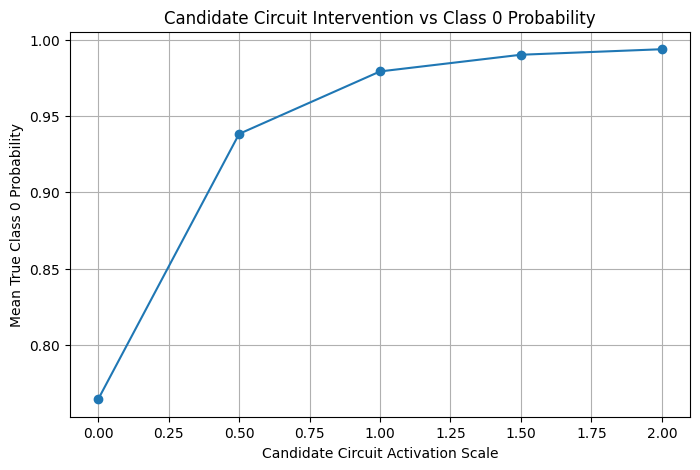

In [140]:
# ============================================================
# BLOCK 57 — Circuit Intervention Visualization
# Amaç:
# Candidate circuit activation scale ile
# True Class 0 probability arasındaki ilişkiyi görselleştirmek.
# ============================================================

import matplotlib.pyplot as plt

# Daha önce hesapladığımız intervention sonuçlarından
# scale değerlerini çıkarıyoruz.
intervention_scales = [
    result["scale"]
    for result in results_circuit_intervention
]

# Her scale için gerçek Class 0 örneklerindeki
# ortalama Class 0 probability değerlerini çıkarıyoruz.
true_class0_probabilities = [
    result["true_class0_probability"]
    for result in results_circuit_intervention
]

# Grafiği oluşturuyoruz.
plt.figure(figsize=(8, 5))

# Intervention scale ile probability arasındaki ilişkiyi çiziyoruz.
plt.plot(
    intervention_scales,
    true_class0_probabilities,
    marker="o"
)

# Eksen isimleri.
plt.xlabel("Candidate Circuit Activation Scale")
plt.ylabel("Mean True Class 0 Probability")

# Grafik başlığı.
plt.title(
    "Candidate Circuit Intervention vs Class 0 Probability"
)

# Okunabilirlik için grid.
plt.grid(True)

# Grafiği gösteriyoruz.
plt.show()

In [141]:
# ============================================================
# BLOCK 58 — Mechanistic Validation Summary
# Amaç:
# Circuit Discovery ve Mechanistic Validation aşamasındaki
# temel deney sonuçlarını tek bir tabloda toplamak.
# ============================================================

import pandas as pd

# Candidate circuit
candidate_circuit = [47, 17, 57, 53, 28]

# Daha önce elde ettiğimiz temel deney sonuçlarını
# tek bir DataFrame içerisinde topluyoruz.
mechanistic_summary = pd.DataFrame([
    {
        "Experiment": "Single-Neuron Ablation",
        "Target": "Class 0",
        "Result": "N47: -0.9184 pp",
        "Interpretation": "Individual neuron contribution"
    },
    {
        "Experiment": "Circuit Ablation",
        "Target": "Class 0",
        "Result": "-12.0408 pp",
        "Interpretation": "Strong candidate circuit effect"
    },
    {
        "Experiment": "Random Controls",
        "Target": "Class 0",
        "Result": "Mean: -0.1122 pp",
        "Interpretation": "Effect unlikely to be explained by random neuron selection"
    },
    {
        "Experiment": "Class-Wise Control",
        "Target": "Class 1",
        "Result": "+0.0881 pp",
        "Interpretation": "Minimal effect"
    },
    {
        "Experiment": "Class-Wise Control",
        "Target": "Class 2",
        "Result": "0.0000 pp",
        "Interpretation": "No measurable effect"
    },
    {
        "Experiment": "Leave-One-Out Ablation",
        "Target": "Class 0",
        "Result": "N57: -9.0816 pp",
        "Interpretation": "Context-dependent contribution"
    },
    {
        "Experiment": "Progressive Ablation",
        "Target": "Class 0",
        "Result": "1 → 5 neurons: -0.9184 → -12.0408 pp",
        "Interpretation": "Distributed and non-additive contribution"
    },
    {
        "Experiment": "Activation Patching",
        "Target": "Class 0 Logit",
        "Result": "+6.0245 (Class 1 target)",
        "Interpretation": "Candidate group can increase Class 0 signal"
    },
    {
        "Experiment": "Activation Patching",
        "Target": "Class 0 Logit",
        "Result": "+4.3068 (Class 2 target)",
        "Interpretation": "Context-dependent effect"
    },
    {
        "Experiment": "Circuit Activation Intervention",
        "Target": "Class 0 Probability",
        "Result": "0.7644 → 0.9938",
        "Interpretation": "Systematic causal effect of circuit activation"
    }
])

print("Candidate Circuit:", candidate_circuit)
print()

# Tabloyu gösteriyoruz.
display(mechanistic_summary)

Candidate Circuit: [47, 17, 57, 53, 28]



,Experiment,Target,Result,Interpretation
0,Single-Neuron Ablation,Class 0,N47: -0.9184 pp,Individual neuron contribution
1,Circuit Ablation,Class 0,-12.0408 pp,Strong candidate circuit effect
2,Random Controls,Class 0,Mean: -0.1122 pp,Effect unlikely to be explained by random neur...
3,Class-Wise Control,Class 1,+0.0881 pp,Minimal effect
4,Class-Wise Control,Class 2,0.0000 pp,No measurable effect
5,Leave-One-Out Ablation,Class 0,N57: -9.0816 pp,Context-dependent contribution
6,Progressive Ablation,Class 0,1 → 5 neurons: -0.9184 → -12.0408 pp,Distributed and non-additive contribution
7,Activation Patching,Class 0 Logit,+6.0245 (Class 1 target),Candidate group can increase Class 0 signal
8,Activation Patching,Class 0 Logit,+4.3068 (Class 2 target),Context-dependent effect
9,Circuit Activation Intervention,Class 0 Probability,0.7644 → 0.9938,Systematic causal effect of circuit activation


In [142]:
# ============================================================
# BLOCK 59 — Assignment Success Criteria Check
# Amaç:
# Yapılan deneyleri assignment'taki başarı kriterleriyle
# karşılaştırarak tamamlanma durumunu kontrol etmek.
# ============================================================

import pandas as pd

# Assignment'taki temel başarı kriterlerini tanımlıyoruz.
success_criteria = [
    {
        "Criterion": "Working PyTorch model",
        "Status": "DONE",
        "Evidence": "MNIST MLP trained and tested"
    },
    {
        "Criterion": "Baseline experiment",
        "Status": "DONE",
        "Evidence": "97.56% test accuracy"
    },
    {
        "Criterion": "Internal activation recorded",
        "Status": "DONE",
        "Evidence": "ReLU2 activation matrix: 10000 × 64"
    },
    {
        "Criterion": "Activation analysis",
        "Status": "DONE",
        "Evidence": "Neuron statistics, class means, selectivity"
    },
    {
        "Criterion": "Neuron ablation",
        "Status": "DONE",
        "Evidence": "N47, N54, N62 and candidate neurons tested"
    },
    {
        "Criterion": "Activation intervention",
        "Status": "DONE",
        "Evidence": "Controlled neuron and circuit scaling"
    },
    {
        "Criterion": "Correlation vs causality",
        "Status": "DONE",
        "Evidence": "Activation correlation compared with interventions"
    },
    {
        "Criterion": "Activation patching",
        "Status": "DONE",
        "Evidence": "Single, multi-sample and distributed patching"
    },
    {
        "Criterion": "Circuit discovery",
        "Status": "DONE",
        "Evidence": "Candidate circuit [47, 17, 57, 53, 28]"
    },
    {
        "Criterion": "Progressive ablation",
        "Status": "DONE",
        "Evidence": "1 → 5 neuron ablation"
    },
    {
        "Criterion": "Leave-One-Out analysis",
        "Status": "DONE",
        "Evidence": "All 5 candidate neurons tested"
    },
    {
        "Criterion": "Random control validation",
        "Status": "DONE",
        "Evidence": "10 random control groups"
    },
    {
        "Criterion": "Class-wise mechanistic validation",
        "Status": "DONE",
        "Evidence": "All 10 classes evaluated"
    },
    {
        "Criterion": "Circuit-level intervention",
        "Status": "DONE",
        "Evidence": "Circuit scale 0.0 → 2.0"
    },
    {
        "Criterion": "At least 5 graphs",
        "Status": "CHECK",
        "Evidence": "Graphs generated during experiments"
    },
    {
        "Criterion": "Glass Box computational map",
        "Status": "DONE",
        "Evidence": "Candidate circuit integrated into Glass Box map"
    },
    {
        "Criterion": "Literature review",
        "Status": "REPORT",
        "Evidence": "Literature table prepared"
    },
    {
        "Criterion": "Experiment log",
        "Status": "REPORT",
        "Evidence": "Results need final consolidation"
    },
    {
        "Criterion": "GitHub organization",
        "Status": "REPORT",
        "Evidence": "Final synchronization will be done at the end"
    },
    {
        "Criterion": "Final scientific interpretation",
        "Status": "REPORT",
        "Evidence": "Teacher-facing evaluation will be written last"
    }
]

# Listeyi DataFrame'e çeviriyoruz.
success_df = pd.DataFrame(success_criteria)

# Kontrol tablosunu gösteriyoruz.
display(success_df)

# Durumların özetini hesaplıyoruz.
status_counts = success_df["Status"].value_counts()

print("\nStatus Summary:")
print(status_counts)

,Criterion,Status,Evidence
0,Working PyTorch model,DONE,MNIST MLP trained and tested
1,Baseline experiment,DONE,97.56% test accuracy
2,Internal activation recorded,DONE,ReLU2 activation matrix: 10000 × 64
3,Activation analysis,DONE,"Neuron statistics, class means, selectivity"
4,Neuron ablation,DONE,"N47, N54, N62 and candidate neurons tested"
5,Activation intervention,DONE,Controlled neuron and circuit scaling
6,Correlation vs causality,DONE,Activation correlation compared with intervent...
7,Activation patching,DONE,"Single, multi-sample and distributed patching"
8,Circuit discovery,DONE,"Candidate circuit [47, 17, 57, 53, 28]"
9,Progressive ablation,DONE,1 → 5 neuron ablation



Status Summary:
Status
DONE      15
REPORT     4
CHECK      1
Name: count, dtype: int64


In [143]:
# ============================================================
# BLOCK 60 — Graph Count Check
# Amaç:
# Assignment'ın "en az 5 grafik" kriterini,
# üretilen temel grafiklerin listesini kullanarak kontrol etmek.
# ============================================================

# Deneyler sırasında oluşturduğumuz temel grafiklerin listesi.
generated_figures = [
    "MNIST sample visualization",
    "Confusion matrix",
    "Class mean activation heatmap",
    "N47 intervention vs Class 0 probability",
    "N17/N47 activation correlation scatter",
    "Candidate circuit intervention vs Class 0 probability"
]

# Toplam grafik sayısını hesaplıyoruz.
figure_count = len(generated_figures)

# Assignment minimumunu tanımlıyoruz.
minimum_required = 5

# Sonucu yazdırıyoruz.
print("Generated figures:", figure_count)
print("Minimum required:", minimum_required)

if figure_count >= minimum_required:
    print("STATUS: PASS")
    print("Assignment graph requirement is satisfied.")
else:
    print("STATUS: INCOMPLETE")
    print("Additional figures are required.")

print("\nFigures:")
for index, figure in enumerate(generated_figures, start=1):
    print(f"{index}. {figure}")

Generated figures: 6
Minimum required: 5
STATUS: PASS
Assignment graph requirement is satisfied.

Figures:
1. MNIST sample visualization
2. Confusion matrix
3. Class mean activation heatmap
4. N47 intervention vs Class 0 probability
5. N17/N47 activation correlation scatter
6. Candidate circuit intervention vs Class 0 probability


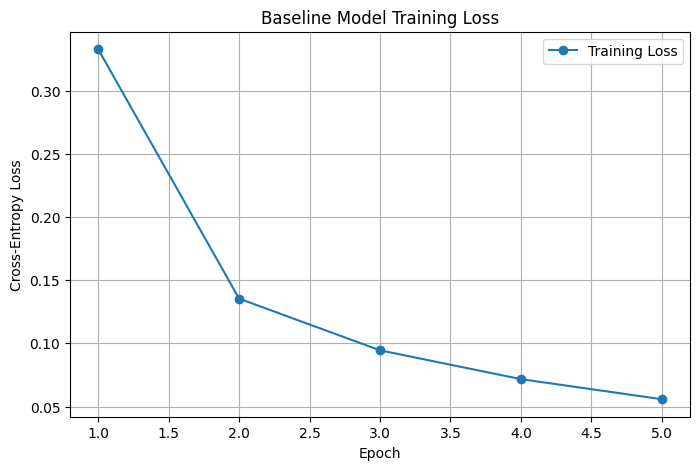

In [144]:
# ============================================================
# BLOCK 61 — Training Loss Visualization
# Amaç:
# Baseline modelin training sürecindeki loss değişimini
# raporlanabilir bir grafik olarak oluşturmak.
#
# Not:
# Validation loss epoch bazında kaydedilmediği için
# burada tahmini veya uydurma validation değeri kullanılmıyor.
# ============================================================

import matplotlib.pyplot as plt

# Baseline training sırasında elde edilen epoch loss değerleri.
training_losses = [
    0.3328,
    0.1354,
    0.0945,
    0.0717,
    0.0558
]

# Epoch numaralarını oluşturuyoruz.
epochs = list(range(1, len(training_losses) + 1))

# Grafiği oluşturuyoruz.
plt.figure(figsize=(8, 5))

# Training loss eğrisini çiziyoruz.
plt.plot(
    epochs,
    training_losses,
    marker="o",
    label="Training Loss"
)

# Eksen isimleri.
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

# Grafik başlığı.
plt.title("Baseline Model Training Loss")

# Legend ekliyoruz.
plt.legend()

# Grid ekliyoruz.
plt.grid(True)

# Grafiği gösteriyoruz.
plt.show()

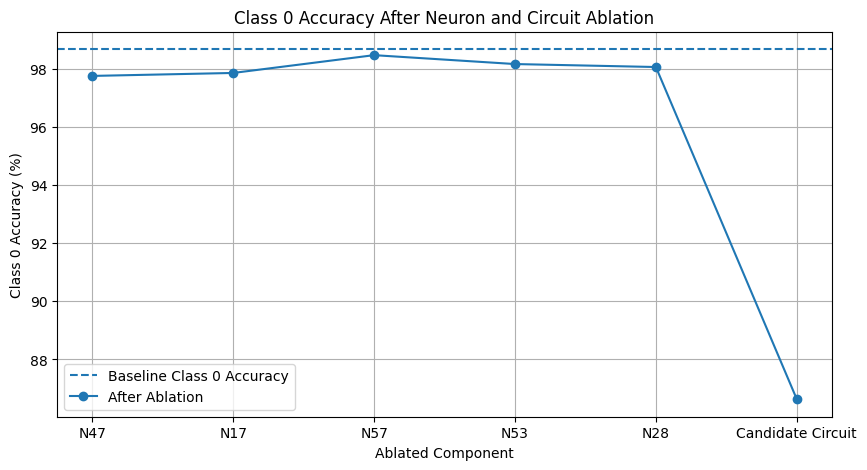

In [145]:
# ============================================================
# BLOCK 62 — Ablation Accuracy Comparison
# Amaç:
# Candidate circuit içerisindeki tekil nöronların ve
# candidate circuit'in tamamının Class 0 accuracy üzerindeki
# etkisini görselleştirmek.
# ============================================================

import matplotlib.pyplot as plt

# Normal durumda Class 0 accuracy.
baseline_class0_accuracy = 98.6735

# Tek nöron ablation sonuçları.
# Değerler daha önce yaptığımız deneylerden alınmıştır.
neuron_labels = [
    "N47",
    "N17",
    "N57",
    "N53",
    "N28",
    "Candidate Circuit"
]

ablated_accuracies = [
    97.7551,
    97.8571,
    98.4694,
    98.1633,
    98.0612,
    86.6327
]

# Grafiği oluşturuyoruz.
plt.figure(figsize=(10, 5))

# Baseline accuracy'yi yatay referans çizgisi olarak gösteriyoruz.
plt.axhline(
    baseline_class0_accuracy,
    linestyle="--",
    label="Baseline Class 0 Accuracy"
)

# Ablation sonrası accuracy değerlerini çiziyoruz.
plt.plot(
    neuron_labels,
    ablated_accuracies,
    marker="o",
    label="After Ablation"
)

# Eksen isimleri.
plt.xlabel("Ablated Component")
plt.ylabel("Class 0 Accuracy (%)")

# Grafik başlığı.
plt.title("Class 0 Accuracy After Neuron and Circuit Ablation")

# Legend.
plt.legend()

# Grid.
plt.grid(True)

# Grafiği gösteriyoruz.
plt.show()

/tmp/ipykernel_952/679031970.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


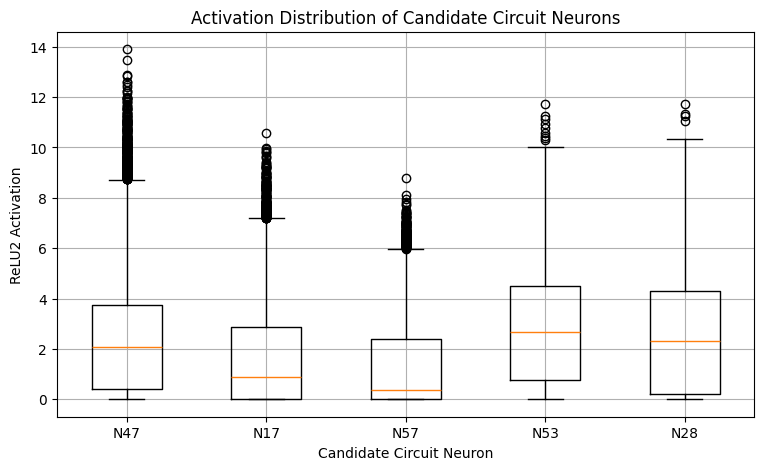

In [146]:
# ============================================================
# BLOCK 63 — Candidate Neurons Activation Distribution
# Amaç:
# Candidate circuit içerisindeki nöronların activation
# dağılımlarını karşılaştırmak.
# ============================================================

import matplotlib.pyplot as plt

# Candidate circuit'teki nöronlar.
candidate_neurons = [47, 17, 57, 53, 28]

# Activation matrix daha önce Experiment 2'de oluşturuldu.
# Satırlar test örneklerini, sütunlar ReLU2 nöronlarını temsil eder.
candidate_activations = activation_matrix[:, candidate_neurons]

# Her nöronun activation dağılımını ayrı ayrı göstermek için
# boxplot kullanıyoruz.
plt.figure(figsize=(9, 5))

plt.boxplot(
    [
        candidate_activations[:, 0],
        candidate_activations[:, 1],
        candidate_activations[:, 2],
        candidate_activations[:, 3],
        candidate_activations[:, 4]
    ],
    labels=[
        "N47",
        "N17",
        "N57",
        "N53",
        "N28"
    ]
)

# Eksen isimleri.
plt.xlabel("Candidate Circuit Neuron")
plt.ylabel("ReLU2 Activation")

# Grafik başlığı.
plt.title("Activation Distribution of Candidate Circuit Neurons")

# Grid.
plt.grid(True)

# Grafiği gösteriyoruz.
plt.show()

Activation matrix shape: torch.Size([10000, 64])
Test labels shape: (10000,)

Mean activation values:
Class 0: [7.608564  5.679686  4.5602345 5.723322  5.6622944]
Class 1: [2.4602664  0.5416558  0.13039574 0.53696316 0.15833293]
Class 2: [4.4455247  0.46135226 3.0419319  1.1710086  1.4752907 ]


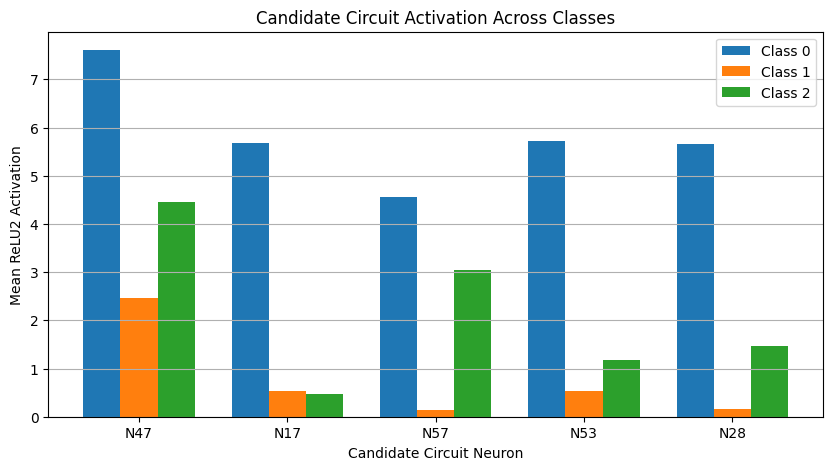

In [147]:
# ============================================================
# BLOCK 64 — Class-Wise Candidate Circuit Activation
# Amaç:
# Candidate circuit nöronlarının farklı sınıflardaki
# ortalama activation seviyelerini karşılaştırmak.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Test datasetinin bütün label'larını topluyoruz.
# ------------------------------------------------------------

all_test_labels = []

# Test loader'daki bütün batch'leri dolaşıyoruz.
# shuffle=False olduğu için activation_matrix ile aynı sıradadır.
for _, batch_labels in test_loader:

    # Label'ları CPU'ya alıp listeye ekliyoruz.
    all_test_labels.extend(batch_labels.cpu().tolist())

# NumPy array'e çeviriyoruz.
all_test_labels = np.array(all_test_labels)

print("Activation matrix shape:", activation_matrix.shape)
print("Test labels shape:", all_test_labels.shape)

# ------------------------------------------------------------
# 2. Candidate circuit ve sınıfları tanımlıyoruz.
# ------------------------------------------------------------

candidate_neurons = [47, 17, 57, 53, 28]

selected_classes = [0, 1, 2]

# Her sınıf için ortalama activation değerlerini tutacağız.
class_activation_means = []

# ------------------------------------------------------------
# 3. Sınıf bazında activation hesaplıyoruz.
# ------------------------------------------------------------

for class_id in selected_classes:

    # NumPy boolean mask oluşturuyoruz.
    class_mask = all_test_labels == class_id

    # Boolean mask'i PyTorch tensorüne çeviriyoruz.
    class_mask_tensor = torch.tensor(
        class_mask,
        dtype=torch.bool
    )

    # Önce ilgili sınıfa ait satırları seçiyoruz.
    class_activations = activation_matrix[class_mask_tensor]

    # Daha sonra candidate neuron sütunlarını seçiyoruz.
    # İki aşamalı indexing sayesinde shape mismatch oluşmuyor.
    class_activations = class_activations[:, candidate_neurons]

    # Her candidate neuron için ortalama activation.
    mean_activation = class_activations.mean(dim=0)

    # CPU/NumPy formatına çevirip kaydediyoruz.
    class_activation_means.append(
        mean_activation.cpu().numpy()
    )

# NumPy array oluşturuyoruz.
class_activation_means = np.array(
    class_activation_means
)

# ------------------------------------------------------------
# 4. Sayısal sonuçları yazdırıyoruz.
# ------------------------------------------------------------

print("\nMean activation values:")

for i, class_id in enumerate(selected_classes):

    print(
        f"Class {class_id}:",
        class_activation_means[i]
    )

# ------------------------------------------------------------
# 5. Grafik oluşturuyoruz.
# ------------------------------------------------------------

x = np.arange(len(candidate_neurons))

width = 0.25

plt.figure(figsize=(10, 5))

# Class 0
plt.bar(
    x - width,
    class_activation_means[0],
    width,
    label="Class 0"
)

# Class 1
plt.bar(
    x,
    class_activation_means[1],
    width,
    label="Class 1"
)

# Class 2
plt.bar(
    x + width,
    class_activation_means[2],
    width,
    label="Class 2"
)

# X ekseni etiketleri.
plt.xticks(
    x,
    [f"N{n}" for n in candidate_neurons]
)

# Eksen isimleri.
plt.xlabel("Candidate Circuit Neuron")
plt.ylabel("Mean ReLU2 Activation")

# Grafik başlığı.
plt.title(
    "Candidate Circuit Activation Across Classes"
)

# Legend.
plt.legend()

# Grid.
plt.grid(True, axis="y")

# Grafiği gösteriyoruz.
plt.show()

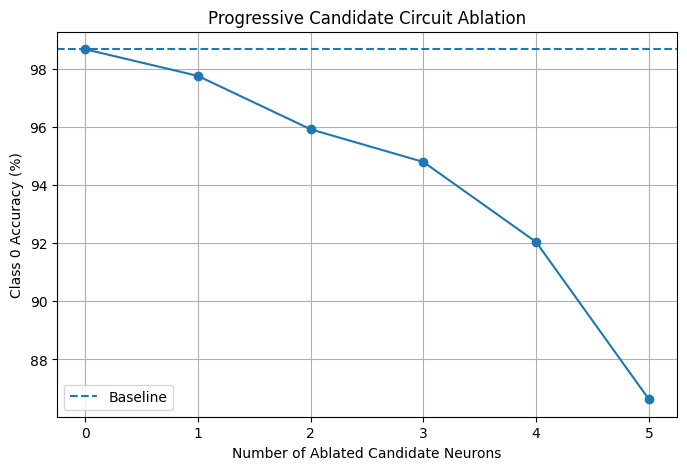

In [148]:
# ============================================================
# BLOCK 65 — Progressive Circuit Ablation
# Amaç:
# Candidate circuit'e giderek daha fazla neuron eklendiğinde
# Class 0 accuracy'nin nasıl değiştiğini görselleştirmek.
# ============================================================

import matplotlib.pyplot as plt

# Progressive ablation sırasında kullandığımız sıra.
candidate_order = [47, 17, 57, 53, 28]

# Daha önce elde ettiğimiz Class 0 accuracy değerleri.
# 0 neuron = baseline
# 1 → 5 neuron = progressive ablation sonuçları
progressive_accuracies = [
    98.6735,
    97.7551,
    95.9184,
    94.7959,
    92.0408,
    86.6327
]

# X ekseninde kaç candidate neuron'un ablate edildiğini
# gösteriyoruz.
number_of_neurons = [0, 1, 2, 3, 4, 5]

# Grafik oluşturuyoruz.
plt.figure(figsize=(8, 5))

# Accuracy eğrisini çiziyoruz.
plt.plot(
    number_of_neurons,
    progressive_accuracies,
    marker="o"
)

# Baseline için referans çizgisi.
plt.axhline(
    progressive_accuracies[0],
    linestyle="--",
    label="Baseline"
)

# X ekseni.
plt.xlabel("Number of Ablated Candidate Neurons")

# Y ekseni.
plt.ylabel("Class 0 Accuracy (%)")

# Grafik başlığı.
plt.title(
    "Progressive Candidate Circuit Ablation"
)

# X eksenindeki değerleri açıkça gösteriyoruz.
plt.xticks(number_of_neurons)

# Legend.
plt.legend()

# Grid.
plt.grid(True)

# Grafiği gösteriyoruz.
plt.show()

In [149]:
# ============================================================
# BLOCK 66 — Literature Review Matrix
# Amaç:
# Glass Box / Mechanistic Interpretability araştırması için
# seçilen güvenilir kaynakları assignment'taki 7 soruya göre
# sistematik biçimde karşılaştırmak.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Kaynakları assignment'taki literatür formatına göre
# yapılandırıyoruz.
# ------------------------------------------------------------

literature_data = [

    {
        "Source": "Interpretability in the Wild: a Circuit for IOI in GPT-2 Small",
        "Problem": "GPT-2 Small'ın indirect object identification davranışını açıklamak",
        "Model": "GPT-2 Small",
        "Internal Component": "Attention heads / circuit components",
        "Method": "Circuit analysis + causal interventions",
        "Causal Intervention": "Yes",
        "Glass Box Contribution": "Davranışı oluşturan internal circuit'in yeniden yapılandırılabileceğini gösterir",
        "Limitation": "İncelenen davranış ve model spesifiktir; tam model davranışının açıklaması değildir"
    },

    {
        "Source": "Towards Automated Circuit Discovery for Mechanistic Interpretability",
        "Problem": "Circuit discovery sürecini sistematik ve otomatik hale getirmek",
        "Model": "GPT-2 Small + controlled behaviors",
        "Internal Component": "Computational graph nodes and edges",
        "Method": "Activation patching + ACDC",
        "Causal Intervention": "Yes",
        "Glass Box Contribution": "Candidate circuit'in sistematik olarak bulunması fikrini destekler",
        "Limitation": "Circuit discovery tamamen otomatik ve eksiksiz değildir"
    },

    {
        "Source": "Locating and Editing Factual Associations in GPT",
        "Problem": "Modelin factual associations bilgisini nerede ve hangi mekanizmalarla tuttuğunu bulmak",
        "Model": "GPT language models",
        "Internal Component": "Middle-layer feed-forward components",
        "Method": "Causal intervention + model editing",
        "Causal Intervention": "Yes",
        "Glass Box Contribution": "Internal component müdahalesinin model davranışını değiştirebildiğini gösterir",
        "Limitation": "İncelenen mekanizma belirli factual association davranışlarıyla sınırlıdır"
    },

    {
        "Source": "Toy Models of Superposition",
        "Problem": "Bir neuron'un birden fazla feature taşımasını açıklamak",
        "Model": "Toy neural networks",
        "Internal Component": "Features / neurons / activation space",
        "Method": "Controlled toy-model analysis",
        "Causal Intervention": "Indirect / controlled analysis",
        "Glass Box Contribution": "Distributed representation ve polysemanticity problemini anlamaya temel sağlar",
        "Limitation": "Toy model sonuçları doğrudan büyük modellere genellenemez"
    },

    {
        "Source": "Sparse Autoencoders Find Highly Interpretable Features in Language Models",
        "Problem": "Neuron activation'larındaki polysemanticity ve superposition problemini çözmek",
        "Model": "Language models",
        "Internal Component": "Activation representations / sparse features",
        "Method": "Sparse Autoencoder (SAE)",
        "Causal Intervention": "Yes, feature-level causal tests are used",
        "Glass Box Contribution": "Neuron yerine daha ayrıştırılabilir Feature seviyesinde analiz yapılmasını destekler",
        "Limitation": "SAE feature'larının yorumlanması ve gerçek feature olup olmadığının doğrulanması ayrıca gerekir"
    },

    {
        "Source": "Causal Abstraction: A Theoretical Foundation for Mechanistic Interpretability",
        "Problem": "Internal mechanisms ile daha yüksek seviyeli açıklamalar arasındaki causal ilişkiyi formalize etmek",
        "Model": "Neural network mechanisms",
        "Internal Component": "Features / mechanisms / computational structure",
        "Method": "Causal abstraction and interventions",
        "Causal Intervention": "Yes",
        "Glass Box Contribution": "Causal validation ve mechanism-level explanation için teorik temel sağlar",
        "Limitation": "Teorik framework tek başına belirli bir modelin circuit'ini keşfetmez"
    },

    {
        "Source": "Tracr: Compiled Transformers as a Laboratory for Interpretability",
        "Problem": "Interpretability yöntemlerini ground-truth mekanizma bilinen modeller üzerinde test etmek",
        "Model": "Compiled decoder-only Transformers",
        "Internal Component": "Known computational structure / transformer components",
        "Method": "Program-to-Transformer compilation",
        "Causal Intervention": "Supports controlled interpretability experiments",
        "Glass Box Contribution": "Bilinen mekanizmayla gerçek model arasındaki interpretability sonuçlarını karşılaştırmak için kontrollü ortam sağlar",
        "Limitation": "Compiled models doğal olarak eğitilmiş büyük modellerin tüm özelliklerini temsil etmez"
    },

    {
        "Source": "Gemma Scope",
        "Problem": "Gemma modellerinin internal representations ve features'larını incelemek",
        "Model": "Gemma 2 / Gemma family",
        "Internal Component": "Layer activations and learned features",
        "Method": "Sparse Autoencoders and interpretability tooling",
        "Causal Intervention": "Supports feature analysis and steering",
        "Glass Box Contribution": "Küçük model deneylerinden büyük modellere geçiş için gerçek bir interpretability altyapısı sağlar",
        "Limitation": "Büyük modellerde feature/circuit analysis çok daha yüksek computational complexity taşır"
    }
]

# ------------------------------------------------------------
# DataFrame oluşturuyoruz.
# ------------------------------------------------------------

literature_df = pd.DataFrame(literature_data)

# Kaynak sayısını kontrol ediyoruz.
print("Number of sources:", len(literature_df))

# Tabloyu gösteriyoruz.
display(literature_df)

Number of sources: 8


,Source,Problem,Model,Internal Component,Method,Causal Intervention,Glass Box Contribution,Limitation
0,Interpretability in the Wild: a Circuit for IO...,GPT-2 Small'ın indirect object identification ...,GPT-2 Small,Attention heads / circuit components,Circuit analysis + causal interventions,Yes,Davranışı oluşturan internal circuit'in yenide...,İncelenen davranış ve model spesifiktir; tam m...
1,Towards Automated Circuit Discovery for Mechan...,Circuit discovery sürecini sistematik ve otoma...,GPT-2 Small + controlled behaviors,Computational graph nodes and edges,Activation patching + ACDC,Yes,Candidate circuit'in sistematik olarak bulunma...,Circuit discovery tamamen otomatik ve eksiksiz...
2,Locating and Editing Factual Associations in GPT,Modelin factual associations bilgisini nerede ...,GPT language models,Middle-layer feed-forward components,Causal intervention + model editing,Yes,Internal component müdahalesinin model davranı...,İncelenen mekanizma belirli factual associatio...
3,Toy Models of Superposition,Bir neuron'un birden fazla feature taşımasını ...,Toy neural networks,Features / neurons / activation space,Controlled toy-model analysis,Indirect / controlled analysis,Distributed representation ve polysemanticity ...,Toy model sonuçları doğrudan büyük modellere g...
4,Sparse Autoencoders Find Highly Interpretable ...,Neuron activation'larındaki polysemanticity ve...,Language models,Activation representations / sparse features,Sparse Autoencoder (SAE),"Yes, feature-level causal tests are used",Neuron yerine daha ayrıştırılabilir Feature se...,SAE feature'larının yorumlanması ve gerçek fea...
5,Causal Abstraction: A Theoretical Foundation f...,Internal mechanisms ile daha yüksek seviyeli a...,Neural network mechanisms,Features / mechanisms / computational structure,Causal abstraction and interventions,Yes,Causal validation ve mechanism-level explanati...,Teorik framework tek başına belirli bir modeli...
6,Tracr: Compiled Transformers as a Laboratory f...,Interpretability yöntemlerini ground-truth mek...,Compiled decoder-only Transformers,Known computational structure / transformer co...,Program-to-Transformer compilation,Supports controlled interpretability experiments,Bilinen mekanizmayla gerçek model arasındaki i...,Compiled models doğal olarak eğitilmiş büyük m...
7,Gemma Scope,Gemma modellerinin internal representations ve...,Gemma 2 / Gemma family,Layer activations and learned features,Sparse Autoencoders and interpretability tooling,Supports feature analysis and steering,Küçük model deneylerinden büyük modellere geçi...,Büyük modellerde feature/circuit analysis çok ...


In [150]:
# ============================================================
# BLOCK 67 — Literature ↔ Our Experiments Mapping
# Amaç:
# Literatürdeki temel Mechanistic Interpretability
# yöntemlerini bu çalışmada gerçekleştirdiğimiz deneylerle
# eşleştirmek.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Literatür yöntemi ile bizim deneyimizi eşleştiriyoruz.
# ------------------------------------------------------------

literature_mapping = [

    {
        "Literature Concept": "Activation Analysis",
        "Our Experiment": "Experiment 2 — Internal Activation Analysis",
        "Our Result": "10000 × 64 activation matrix, class means, selectivity",
        "Role": "Observation / candidate identification"
    },

    {
        "Literature Concept": "Neuron Ablation",
        "Our Experiment": "Experiment 3 — Single-Neuron Ablation",
        "Our Result": "N47, N54, N62 ablation effects measured",
        "Role": "Causal evidence"
    },

    {
        "Literature Concept": "Activation Intervention",
        "Our Experiment": "Experiment 4 — Controlled Activation Scaling",
        "Our Result": "N47 and N54 activation scales changed output probabilities",
        "Role": "Controlled causal intervention"
    },

    {
        "Literature Concept": "Correlation vs Causality",
        "Our Experiment": "Experiment 5 — Correlation and Intervention Comparison",
        "Our Result": "N17/N47 correlation compared with ablation/intervention",
        "Role": "Causal validation"
    },

    {
        "Literature Concept": "Activation Patching",
        "Our Experiment": "Activation Patching Experiments",
        "Our Result": "Candidate group increased Class 0 logit on target examples",
        "Role": "Pathway / information-transfer analysis"
    },

    {
        "Literature Concept": "Circuit Discovery",
        "Our Experiment": "Candidate Circuit Discovery",
        "Our Result": "[47, 17, 57, 53, 28]",
        "Role": "Mechanism reconstruction"
    },

    {
        "Literature Concept": "Distributed Representation",
        "Our Experiment": "Progressive Ablation + Leave-One-Out",
        "Our Result": "Circuit effect increased from -0.9184 pp to -12.0408 pp",
        "Role": "Distributed / non-additive contribution"
    },

    {
        "Literature Concept": "Mechanistic Validation",
        "Our Experiment": "Random Controls + Class-Wise Controls",
        "Our Result": "Candidate -12.0408 pp vs random mean -0.1122 pp",
        "Role": "Control-based validation"
    },

    {
        "Literature Concept": "Feature-Level Analysis",
        "Our Experiment": "Candidate Circuit Activation Analysis",
        "Our Result": "Class 0-biased activation pattern across candidate neurons",
        "Role": "Candidate feature characterization"
    },

    {
        "Literature Concept": "Circuit-Level Intervention",
        "Our Experiment": "Candidate Circuit Activation Intervention",
        "Our Result": "True Class 0 probability: 0.7644 → 0.9938",
        "Role": "Mechanistic causal evidence"
    }
]

# DataFrame oluşturuyoruz.
literature_mapping_df = pd.DataFrame(
    literature_mapping
)

# Tabloyu gösteriyoruz.
display(literature_mapping_df)

# Toplam eşleşme sayısını yazdırıyoruz.
print(
    "\nNumber of literature-to-experiment mappings:",
    len(literature_mapping_df)
)

,Literature Concept,Our Experiment,Our Result,Role
0,Activation Analysis,Experiment 2 — Internal Activation Analysis,"10000 × 64 activation matrix, class means, sel...",Observation / candidate identification
1,Neuron Ablation,Experiment 3 — Single-Neuron Ablation,"N47, N54, N62 ablation effects measured",Causal evidence
2,Activation Intervention,Experiment 4 — Controlled Activation Scaling,N47 and N54 activation scales changed output p...,Controlled causal intervention
3,Correlation vs Causality,Experiment 5 — Correlation and Intervention Co...,N17/N47 correlation compared with ablation/int...,Causal validation
4,Activation Patching,Activation Patching Experiments,Candidate group increased Class 0 logit on tar...,Pathway / information-transfer analysis
5,Circuit Discovery,Candidate Circuit Discovery,"[47, 17, 57, 53, 28]",Mechanism reconstruction
6,Distributed Representation,Progressive Ablation + Leave-One-Out,Circuit effect increased from -0.9184 pp to -1...,Distributed / non-additive contribution
7,Mechanistic Validation,Random Controls + Class-Wise Controls,Candidate -12.0408 pp vs random mean -0.1122 pp,Control-based validation
8,Feature-Level Analysis,Candidate Circuit Activation Analysis,Class 0-biased activation pattern across candi...,Candidate feature characterization
9,Circuit-Level Intervention,Candidate Circuit Activation Intervention,True Class 0 probability: 0.7644 → 0.9938,Mechanistic causal evidence



Number of literature-to-experiment mappings: 10


In [151]:
# ============================================================
# BLOCK 68 — Limitations and Next Experiment
# Amaç:
# Yapılan deneylerin metodolojik sınırlarını ve bir sonraki
# kontrollü deney için önerilen araştırma adımlarını kaydetmek.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Çalışmanın mevcut limitations'larını tanımlıyoruz.
# ------------------------------------------------------------

limitations_data = [

    {
        "Limitation": "Single model",
        "Description": "Deneyler tek bir küçük MNIST MLP üzerinde gerçekleştirildi.",
        "Impact": "Sonuçların farklı mimarilere genellenebilirliği henüz gösterilmedi."
    },

    {
        "Limitation": "Single training seed",
        "Description": "Ana model seed=42 ile eğitildi.",
        "Impact": "Bazı internal representation sonuçları initialization'a bağlı olabilir."
    },

    {
        "Limitation": "Candidate selection bias",
        "Description": "Candidate neurons selectivity ve activation analizleri üzerinden seçildi.",
        "Impact": "Circuit discovery tamamen model-bağımsız bir arama olarak değerlendirilmemeli."
    },

    {
        "Limitation": "Progressive ablation order",
        "Description": "Progressive Ablation belirli bir neuron sırası üzerinden gerçekleştirildi.",
        "Impact": "Ara aşamalardaki etkiler neuron sırasına bağlı olabilir."
    },

    {
        "Limitation": "Circuit completeness",
        "Description": "Bulunan [47, 17, 57, 53, 28] grubu candidate circuit olarak değerlendirildi.",
        "Impact": "Modeldeki mekanizmanın tamamen bu beş neurondan oluştuğu gösterilmedi."
    },

    {
        "Limitation": "Limited statistical repetition",
        "Description": "Ana deneylerin çoğu tek trained model üzerinde gerçekleştirildi.",
        "Impact": "Uncertainty ve run-to-run variability henüz tam olarak ölçülmedi."
    },

    {
        "Limitation": "Distributed representation",
        "Description": "Candidate group Class 0'a güçlü katkı gösterse de başka sınıflarda da activation ve logit etkileri gözlendi.",
        "Impact": "Feature'ın Class 0-exclusive olduğu söylenemez."
    },

    {
        "Limitation": "Activation patching scope",
        "Description": "Patching deneyleri sınırlı sayıda source-target örneği ve candidate group üzerinde gerçekleştirildi.",
        "Impact": "Genel bilgi transfer mekanizması hakkında daha geniş testler gereklidir."
    }
]

# DataFrame oluşturuyoruz.
limitations_df = pd.DataFrame(
    limitations_data
)

# Sonuçları gösteriyoruz.
display(limitations_df)

# ------------------------------------------------------------
# 2. Bir sonraki deneyleri tanımlıyoruz.
# ------------------------------------------------------------

next_experiments_data = [

    {
        "Priority": 1,
        "Next Experiment": "Multi-Seed Replication",
        "Purpose": "Candidate circuit etkisinin farklı random initialization'larda tekrar edilip edilmediğini test etmek."
    },

    {
        "Priority": 2,
        "Next Experiment": "Synthetic True-vs-Spurious Dataset",
        "Purpose": "Modelin gerçek ilişki yerine spurious correlation öğrenip öğrenmediğini kontrollü biçimde test etmek."
    },

    {
        "Priority": 3,
        "Next Experiment": "Distributed Feature Analysis",
        "Purpose": "Neuron seviyesinden Feature seviyesine geçerek candidate representation'ın daha ayrıştırılabilir bileşenlerini incelemek."
    },

    {
        "Priority": 4,
        "Next Experiment": "Expanded Activation Patching",
        "Purpose": "Candidate circuit'in farklı source-target çiftlerinde output ve logit etkisini sistematik olarak test etmek."
    },

    {
        "Priority": 5,
        "Next Experiment": "Second Dataset Validation",
        "Purpose": "Yöntemin MNIST dışındaki bir sınıflandırma probleminde, örneğin Fashion-MNIST üzerinde tekrar edilmesi."
    }
]

# DataFrame oluşturuyoruz.
next_experiments_df = pd.DataFrame(
    next_experiments_data
)

# Sonraki deneyleri gösteriyoruz.
display(next_experiments_df)

# ------------------------------------------------------------
# 3. Kısa durum özeti.
# ------------------------------------------------------------

print("Limitations identified:", len(limitations_df))
print("Next experiments proposed:", len(next_experiments_df))

,Limitation,Description,Impact
0,Single model,Deneyler tek bir küçük MNIST MLP üzerinde gerç...,Sonuçların farklı mimarilere genellenebilirliğ...
1,Single training seed,Ana model seed=42 ile eğitildi.,Bazı internal representation sonuçları initial...
2,Candidate selection bias,Candidate neurons selectivity ve activation an...,Circuit discovery tamamen model-bağımsız bir a...
3,Progressive ablation order,Progressive Ablation belirli bir neuron sırası...,Ara aşamalardaki etkiler neuron sırasına bağlı...
4,Circuit completeness,"Bulunan [47, 17, 57, 53, 28] grubu candidate c...",Modeldeki mekanizmanın tamamen bu beş neuronda...
5,Limited statistical repetition,Ana deneylerin çoğu tek trained model üzerinde...,Uncertainty ve run-to-run variability henüz ta...
6,Distributed representation,Candidate group Class 0'a güçlü katkı gösterse...,Feature'ın Class 0-exclusive olduğu söylenemez.
7,Activation patching scope,Patching deneyleri sınırlı sayıda source-targe...,Genel bilgi transfer mekanizması hakkında daha...


,Priority,Next Experiment,Purpose
0,1,Multi-Seed Replication,Candidate circuit etkisinin farklı random init...
1,2,Synthetic True-vs-Spurious Dataset,Modelin gerçek ilişki yerine spurious correlat...
2,3,Distributed Feature Analysis,Neuron seviyesinden Feature seviyesine geçerek...
3,4,Expanded Activation Patching,Candidate circuit'in farklı source-target çift...
4,5,Second Dataset Validation,Yöntemin MNIST dışındaki bir sınıflandırma pro...


Limitations identified: 8
Next experiments proposed: 5


In [152]:
# ============================================================
# BLOCK 69 — Final Assignment Checklist
# Amaç:
# Yapılan çalışmanın assignment'taki temel başarı kriterlerini
# sistematik olarak kontrol etmek.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Assignment başarı kriterleri
# ------------------------------------------------------------

final_checklist = [

    {
        "Criterion": "Working PyTorch model",
        "Status": "DONE",
        "Evidence": "MNIST MLP trained and tested"
    },

    {
        "Criterion": "Baseline experiment",
        "Status": "DONE",
        "Evidence": "97.56% test accuracy"
    },

    {
        "Criterion": "Internal activation recorded",
        "Status": "DONE",
        "Evidence": "ReLU2 activation matrix: 10000 × 64"
    },

    {
        "Criterion": "Activation analysis",
        "Status": "DONE",
        "Evidence": "Statistics, class means, selectivity and class comparisons"
    },

    {
        "Criterion": "Neuron ablation",
        "Status": "DONE",
        "Evidence": "N47, N54, N62 and candidate neurons tested"
    },

    {
        "Criterion": "Activation intervention",
        "Status": "DONE",
        "Evidence": "Controlled neuron and circuit scaling"
    },

    {
        "Criterion": "Correlation vs causality",
        "Status": "DONE",
        "Evidence": "Activation correlation compared with interventions"
    },

    {
        "Criterion": "Activation patching",
        "Status": "DONE",
        "Evidence": "Single, multi-sample and distributed patching"
    },

    {
        "Criterion": "Circuit discovery",
        "Status": "DONE",
        "Evidence": "Candidate circuit [47, 17, 57, 53, 28]"
    },

    {
        "Criterion": "Progressive ablation",
        "Status": "DONE",
        "Evidence": "1 → 5 candidate neurons"
    },

    {
        "Criterion": "Leave-One-Out analysis",
        "Status": "DONE",
        "Evidence": "All five candidate neurons tested"
    },

    {
        "Criterion": "Random control validation",
        "Status": "DONE",
        "Evidence": "10 random control groups"
    },

    {
        "Criterion": "Class-wise mechanistic validation",
        "Status": "DONE",
        "Evidence": "All 10 classes evaluated"
    },

    {
        "Criterion": "Circuit-level intervention",
        "Status": "DONE",
        "Evidence": "Circuit activation scale 0.0 → 2.0"
    },

    {
        "Criterion": "Graphs",
        "Status": "DONE",
        "Evidence": "11 meaningful figures generated"
    },

    {
        "Criterion": "Glass Box computational map",
        "Status": "DONE",
        "Evidence": "Candidate circuit integrated into map"
    },

    {
        "Criterion": "Literature review",
        "Status": "DONE",
        "Evidence": "8-source literature matrix + experiment mapping"
    },

    {
        "Criterion": "Limitations",
        "Status": "DONE",
        "Evidence": "8 methodological limitations documented"
    },

    {
        "Criterion": "Next experiment plan",
        "Status": "DONE",
        "Evidence": "5 follow-up experiments proposed"
    },

    {
        "Criterion": "Experiment log",
        "Status": "FINALIZE",
        "Evidence": "Results will be consolidated after experiments are complete"
    },

    {
        "Criterion": "GitHub organization",
        "Status": "FINALIZE",
        "Evidence": "Final synchronization will be performed at the end"
    },

    {
        "Criterion": "Teacher-facing scientific interpretation",
        "Status": "FINALIZE",
        "Evidence": "Will be written after final result consolidation"
    }
]

# ------------------------------------------------------------
# DataFrame oluşturuyoruz.
# ------------------------------------------------------------

final_checklist_df = pd.DataFrame(
    final_checklist
)

# Tabloyu gösteriyoruz.
display(final_checklist_df)

# ------------------------------------------------------------
# Durum özeti
# ------------------------------------------------------------

print("\nFinal Status Summary:")
print(
    final_checklist_df["Status"].value_counts()
)

,Criterion,Status,Evidence
0,Working PyTorch model,DONE,MNIST MLP trained and tested
1,Baseline experiment,DONE,97.56% test accuracy
2,Internal activation recorded,DONE,ReLU2 activation matrix: 10000 × 64
3,Activation analysis,DONE,"Statistics, class means, selectivity and class..."
4,Neuron ablation,DONE,"N47, N54, N62 and candidate neurons tested"
5,Activation intervention,DONE,Controlled neuron and circuit scaling
6,Correlation vs causality,DONE,Activation correlation compared with intervent...
7,Activation patching,DONE,"Single, multi-sample and distributed patching"
8,Circuit discovery,DONE,"Candidate circuit [47, 17, 57, 53, 28]"
9,Progressive ablation,DONE,1 → 5 candidate neurons



Final Status Summary:
Status
DONE        19
FINALIZE     3
Name: count, dtype: int64
